In [4]:
import sys
sys.path.append('method_scripts/')

from src.run_app import *
from src.prepare_gam import *
from src.utils import *
from src.rset_opt import *
from FasterRisk.src.fasterrisk import fasterrisk
from gam_rs_utils.binarize_dataset import binarize_dataset
from gam_rs_utils.utils import *
from method_scripts.results_class import *
from method_scripts.base_method import *

from time import time
import pickle

In [5]:
def get_all_datasets_results(methods, dataset_names):
    all_datasets_results = {}
    for dname in dataset_names:
        all_columns = set()
        method_dfs = {}
        for method in methods:
            data = load_results(f"analysis/results/methods/{method}.pkl")
            df = pd.DataFrame(data)
            df = df[df["dataset"] == dname]
            method_dfs[method] = df
            all_columns.update(df.columns)
        all_columns = list(all_columns)

        dfs = []
        for method, df in method_dfs.items():
            df = df.reindex(columns=all_columns)
            df["method"] = method
            dfs.append(df)
        combined_df = pd.concat(dfs, ignore_index=True)
        all_datasets_results[dname] = combined_df 
    return all_datasets_results

def populate_all_datasets_results(all_datasets_results, limit=25, n_samples=500):
    for dname, df in all_datasets_results.items():
        print(dname)
        accuracy, logistic, hamming, iou, euclidean, cosine, feature_to_vi = [], [], [], [], [], [], []
        model_count, headers = [], []
        feature_to_shape_diversities = []
        feature_to_shape_differences = []

        path = f"datasets/{dname}.csv"
        X, y, header, new_header, sample_p = BaseGAMRSetMethod.get_binned_dataset(path, df.iloc[0]['n_estimators'])
        for i, row in df.iterrows():
            w_rset = row["w_rset"]
            w_opt = row["w_opt"]
            predictions = row["predictions"]
            l2 = 0.001
            
            model_count.append(w_rset.shape[0])

            print(f"\t{i}: {w_rset.shape[0]}")
            if w_rset.shape[0] > n_samples: 
                w_rset = w_rset[:n_samples]
                print(f"\ttruncated to {n_samples}")

            accuracy.append(BaseGAMRSetMethod.get_loss(X, y, w_rset, loss_type="accuracy"))
            logistic.append(BaseGAMRSetMethod.get_loss(X, y, w_rset, loss_type="logistic", l2=l2, sample_p=sample_p))
            hamming.append(average_pairwise_diversity(predictions.T, hamming_distance, limit=limit))

            iou.append(average_pairwise_diversity(w_rset, inverse_IoU, limit=limit))
            euclidean.append(average_pairwise_diversity(w_rset, euclidean_distance, limit=limit))
            cosine.append(average_pairwise_diversity(w_rset, inverse_cosine_similarity, limit=limit))
            headers.append(new_header)

            feature_to_vi.append(get_variable_importance(X, w_rset[:, 1:], np.array(new_header[1:]), True))
            
            # get feature to indices
            feature_to_indices = defaultdict(list)
            feature_to_widths = defaultdict(list)
            feature_ranges = get_feature_ranges(np.array(new_header[1:]))
            for feature, ranges in feature_ranges.items():
                for r in ranges:
                    if len(r) == 1:
                        feature_to_widths[feature].append(r[0])
                    else:
                        feature_to_widths[feature].append(r[1] - r[0])
            for i, col in enumerate(new_header[1:]):
                match = re.search(r'([a-zA-Z]+)', col)
                if match:
                    feature = match.group(1)
                    feature_to_indices[feature].append(i)
            
            feature_to_shape_diversity = defaultdict(list)
            feature_to_shape_difference = defaultdict(list)
            for feature, indices in feature_to_indices.items():
                indices = np.array(indices)
                average_X_row = np.mean(X[:, indices], axis=0)
                feature_to_shape_diversity[feature].append(average_pairwise_diversity(w_rset[:, indices], shape_diversity, limit=limit, X=average_X_row))
                feature_to_shape_difference[feature].append(average_pairwise_diversity(w_rset[:, indices], shape_difference, limit=limit, X=feature_to_widths[feature]))
            feature_to_shape_diversities.append(feature_to_shape_diversity)
            feature_to_shape_differences.append(feature_to_shape_difference)

        df['accuracy'] = accuracy
        df['logistic'] = logistic
        df['hamming'] = hamming
        df['iou'] = iou
        df['euclidean'] = euclidean
        df['cosine'] = cosine
        df['model_count'] = model_count
        df['header'] = headers
        df['feature_to_vi'] = feature_to_vi
        df['feature_to_shape_diversities'] = feature_to_shape_diversities
        df['feature_to_shape_differences'] = feature_to_shape_differences

In [ ]:
methods = [
    "uniform__ellipsoid_sampling",
    "uniform_surface_ellipsoid_sampling",
    "poisson__ellipsoid_sampling",
    "poisson_euclidean_ellipsoid_sampling",
    "permutation__ellipsoid_sampling",
    "permutation_poisson_ellipsoid_sampling",
    "blocking",
    "quadratic",
    "swapping_1",
    "swapping_2",
    "swapping_3",
    "swapping_4",
    "swapping_5",
    "hybrid",
]
dataset_names = ["diabetes", "mimic2"]

In [7]:
all_datasets_results = get_all_datasets_results(methods, dataset_names)

In [8]:
populate_all_datasets_results(all_datasets_results)

diabetes
	0: 212
	1: 219
	2: 336
	3: 482
mimic2
	0: 13
	1: 20
	2: 2682
	truncated to 500
	3: 2620
	truncated to 500


In [9]:
def show_loss_distributions(all_datasets_results, dname, loss_type):
    df = all_datasets_results[dname]
    for i, row in df.iterrows():
        path = f"datasets/{dname}.csv"
        X, y, header, new_header, sample_p = BaseGAMRSetMethod.get_binned_dataset(path, row["n_estimators"])
        w_rset = row['w_rset']
        w_opt = row['w_opt']
        l2 = row['l2']
        print(f"METHOD: {row['method']}")
        BaseGAMRSetMethod.get_loss(
            X, y,
            w_rset,
            loss_type=loss_type,
            verbosity=1,
            w_opt=w_opt,
            l2=l2,
            sample_p=sample_p,
        )

def show_bar_plot(all_datasets_results, dname, metric):
    df = all_datasets_results[dname]
    # print(df.columns)
    plot_two_var_bar(df, "method", metric)

def show_gam(all_datasets_results, dname, n_samples=100):
    df = all_datasets_results[dname]
    for i, row in df.iterrows():
        if row['model_count'] == 0:
            continue
        print(f"method: {row['method']}")
        plot_gam(np.array(row['header'][1:]), row['w_rset'][:n_samples, 1:])

def show_variable_importance(all_datasets_results, dname):
    df = all_datasets_results[dname]
    for i, row in df.iterrows():
        print(f"method: {row['method']}, model_count: {row['model_count']}")
        if row['model_count'] == 0:
            continue

        feature_to_vi = row['feature_to_vi']
        plot_variable_importance(feature_to_vi)

def show_model_reliance(all_datasets_results, dname):
    df = all_datasets_results[dname]
    
    # Filter out methods with 0 models
    df_filtered = df[df['model_count'] > 0].copy()
    
    if len(df_filtered) == 0:
        print("No methods with models found for this dataset.")
        return
    
    # Collect all unique features across all methods
    all_features = set()
    for _, row in df_filtered.iterrows():
        all_features.update(row['feature_to_vi'].keys())
    
    all_features = sorted(list(all_features))
    
    # Create individual plots for each feature
    for feature in all_features:
        # Collect data for this feature across all methods
        method_data = []
        method_labels = []
        
        for _, row in df_filtered.iterrows():
            method_name = row['method']
            if feature in row['feature_to_vi']:
                values = row['feature_to_vi'][feature]
                method_data.append(values)
                method_labels.append(method_name)
                print(f"\t{method_name}: {min(values)} - {max(values)}")
        
        if method_data:
            # Create individual plot for this feature
            plt.figure(figsize=(10, 6))
            
            # Create boxplot
            bp = plt.boxplot(method_data, labels=method_labels, patch_artist=True)
            
            # Color the boxes
            colors = plt.cm.Set3(np.linspace(0, 1, len(method_data)))
            for patch, color in zip(bp['boxes'], colors):
                patch.set_facecolor(color)
                patch.set_alpha(0.7)
            
            plt.title(f'{feature} - Variable Importance Distribution by Method')
            plt.ylabel('Variable Importance')
            plt.xlabel('Method')
            plt.xticks(rotation=45)
            plt.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.show()
        else:
            print(f"No data available for feature: {feature}") 

def show_feature_to_shape_diversity(all_dataset_results, dname, metric):
    feature_to_diversities = all_dataset_results[dname][metric].to_list()
    collated_diversities = defaultdict(list)
    for ftd in feature_to_diversities:
        for feature, diversities in ftd.items():
            collated_diversities[feature].append(diversities[0])
    
    for feature, diversities in collated_diversities.items():
        plt.bar(methods, diversities)
        plt.xticks(rotation=45)
        plt.title(f"{feature} - {metric}")
        plt.tight_layout()
        plt.show()

def show_swapping_percentages(all_dataset_results, dname):
    df = all_dataset_results[dname]
    collated_swapping_percentages = []
    for i, row in df.iterrows():
        if row['method'].startswith("swapping"):
            collated_swapping_percentages.append(row['swapping_percentages'])

    swapping_methods = [m for m in methods if m.startswith("swapping")]
    plt.bar(swapping_methods, [np.average(p) for p in collated_swapping_percentages])
    plt.xticks(rotation=45)
    plt.title(f"Swapping Percentages")
    plt.tight_layout()
    plt.show()

    for sm, p in zip(swapping_methods, collated_swapping_percentages):
        plt.hist(p, bins=30)
        plt.title(f"{sm} - Swapping Percentages")
        plt.tight_layout()
        plt.show()

METHOD: uniform__ellipsoid_sampling
optimal model
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32] 0.11330993961155542


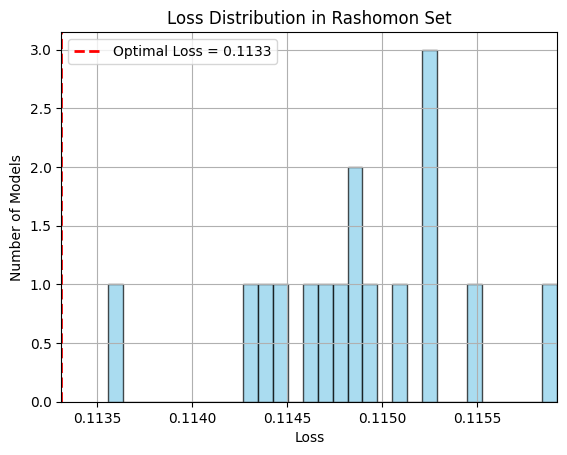

METHOD: uniform_surface_ellipsoid_sampling
optimal model
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32] 0.11335074261465644


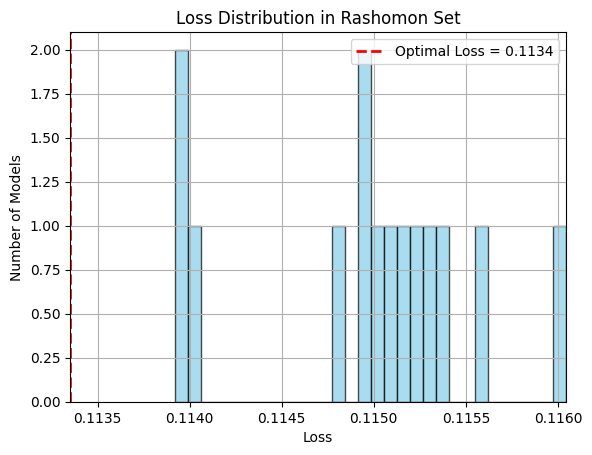

METHOD: poisson__ellipsoid_sampling
optimal model
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32] 0.11330993961155542


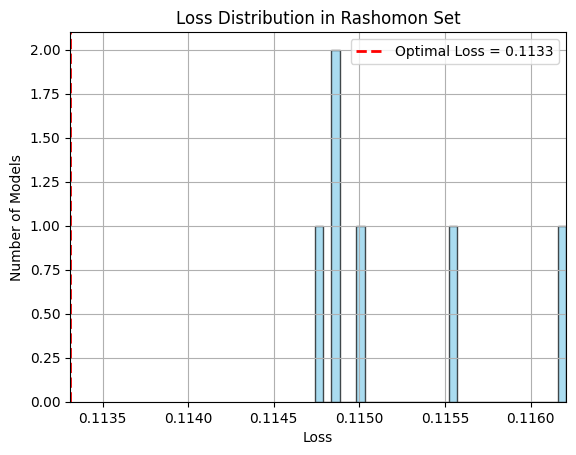

METHOD: poisson_euclidean_ellipsoid_sampling
optimal model
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32] 0.11330993961155542


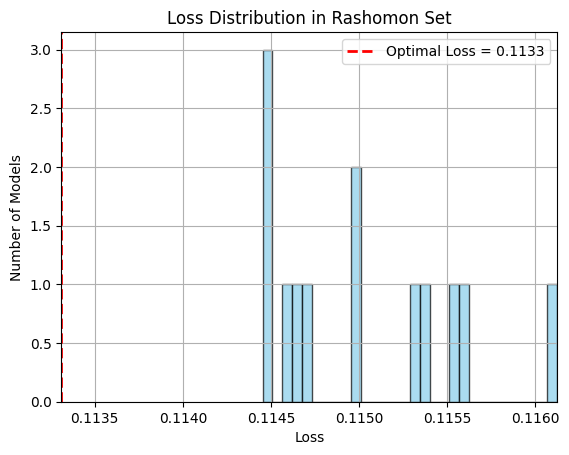

METHOD: permutation__ellipsoid_sampling
optimal model
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32] 0.11330993961155542


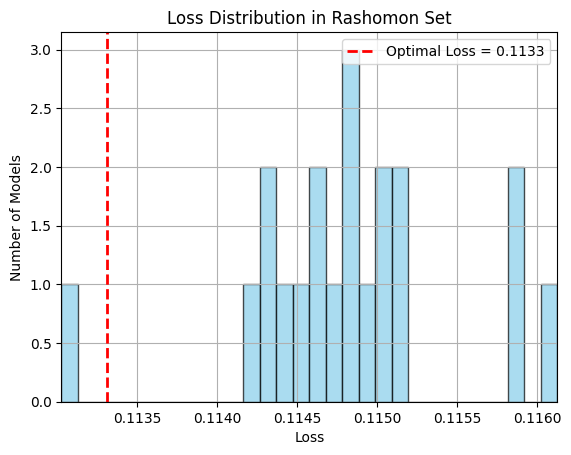

METHOD: permutation_poisson_ellipsoid_sampling
optimal model
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32] 0.11330993961155542


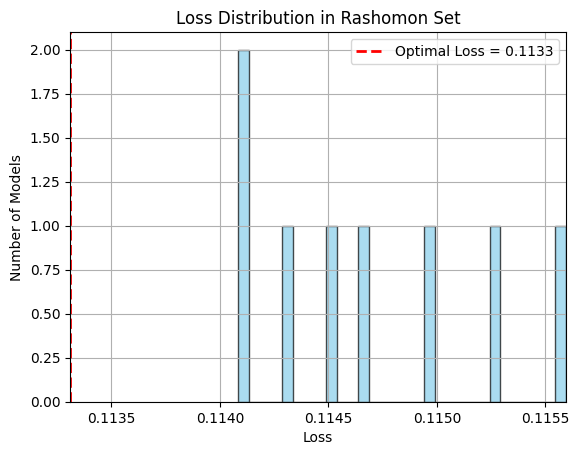

METHOD: blocking
optimal model
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32] 0.11330993961155542


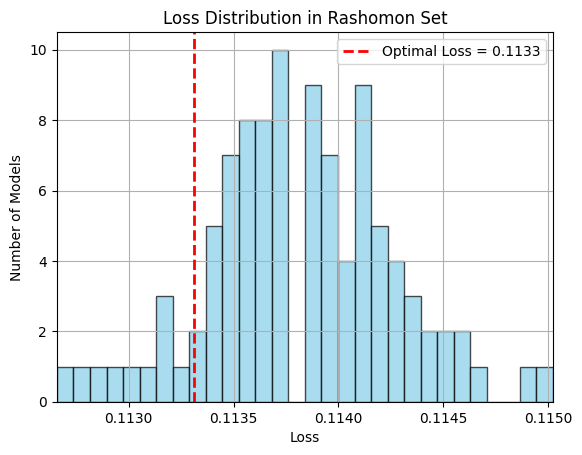

METHOD: quadratic
optimal model
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32] 0.11330993961155542


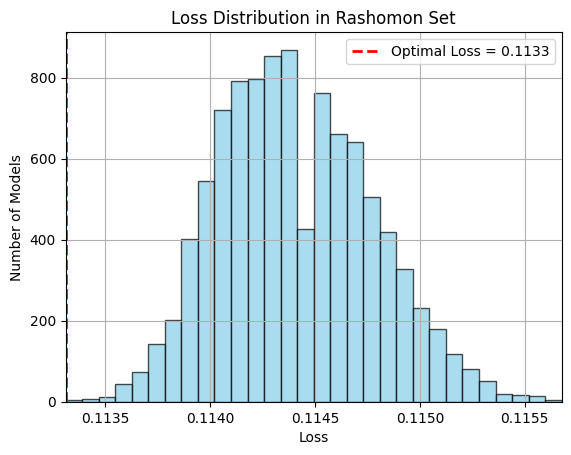

METHOD: swapping_1
optimal model
[ 0  1  3  4  5  6  8  9 10 11 13 14 15 16 17 18 19 20 22 23 24 25 28 29
 30 32] 0.11437081769218214


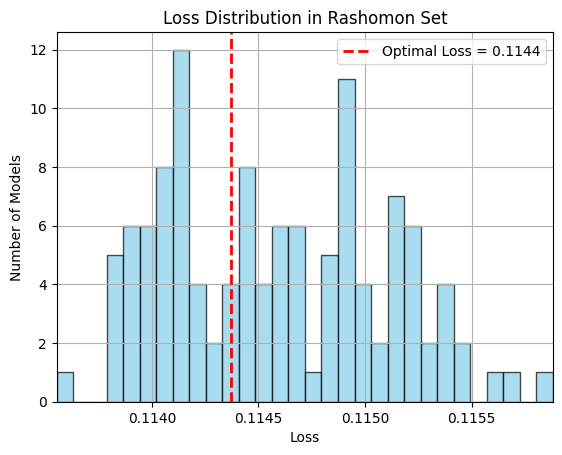

METHOD: swapping_2
optimal model
[ 0  1  3  4  5  6  8  9 10 11 13 14 15 16 17 18 19 20 22 23 24 25 28 29
 30 32] 0.11437081769218214


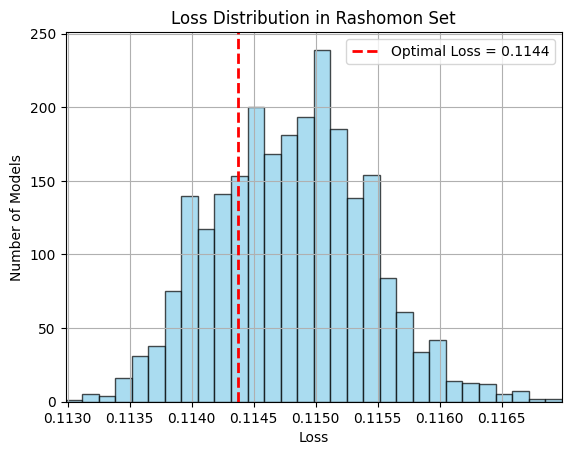

METHOD: swapping_3
optimal model
[ 0  1  3  4  5  6  8  9 10 11 13 14 15 16 17 18 19 20 22 23 24 25 28 29
 30 32] 0.11437081769218214


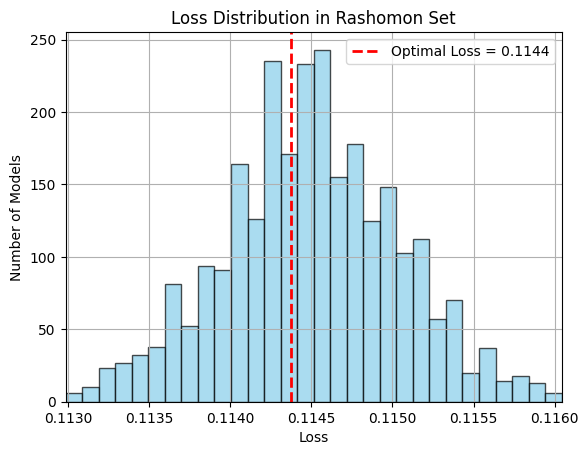

METHOD: swapping_4
optimal model
[ 0  1  3  4  5  6  8  9 10 11 13 14 15 16 17 18 19 20 22 23 24 25 28 29
 30 32] 0.11437081769218214


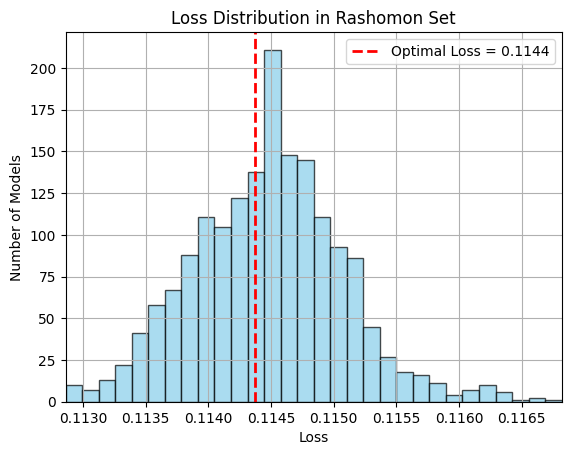

METHOD: swapping_5
optimal model
[ 0  1  3  4  5  6  8  9 10 11 13 14 15 16 17 18 19 20 22 23 24 25 28 29
 30 32] 0.11437081769218214


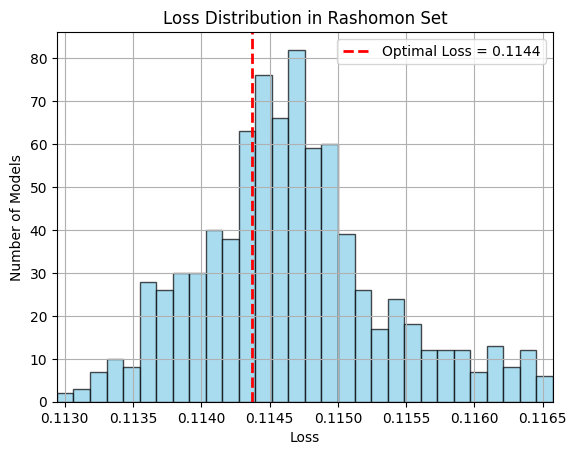

METHOD: hybrid
optimal model
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32] 0.11330993961155542


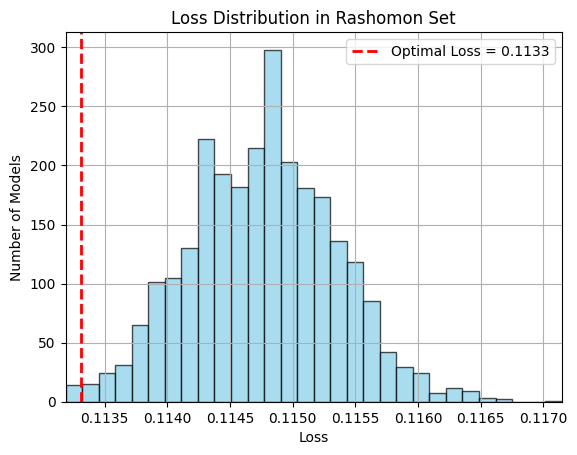

In [ ]:
show_loss_distributions(all_datasets_results, "mimic2", "accuracy")

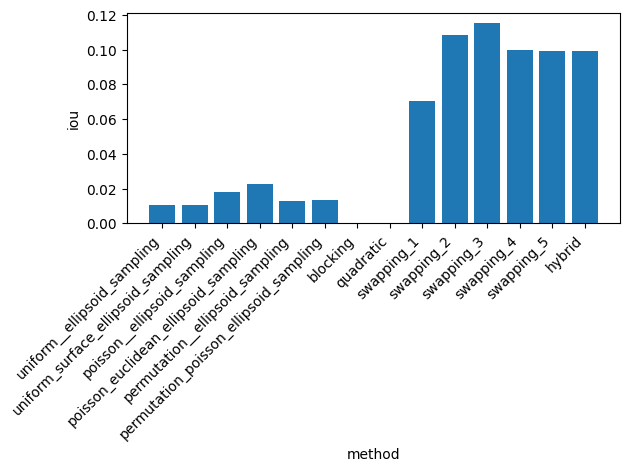

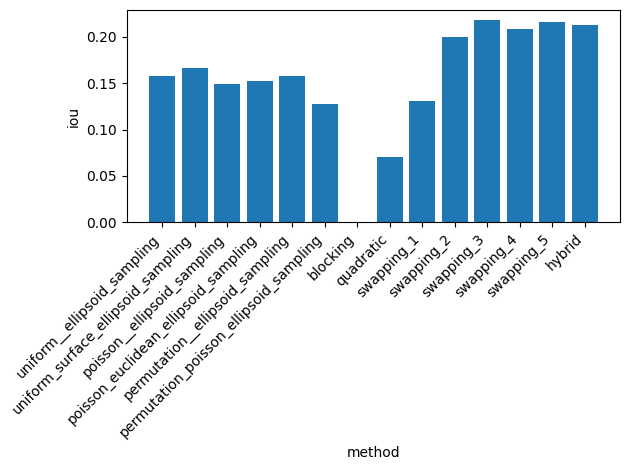

In [47]:
metrics = ['accuracy', 'logistic', 'hamming', 'iou', 'euclidean', 'cosine']
for dname in dataset_names:
    show_bar_plot(all_datasets_results, dname, metrics[3])

method: uniform__ellipsoid_sampling


100%|██████████| 16/16 [00:00<00:00, 6892.86it/s]


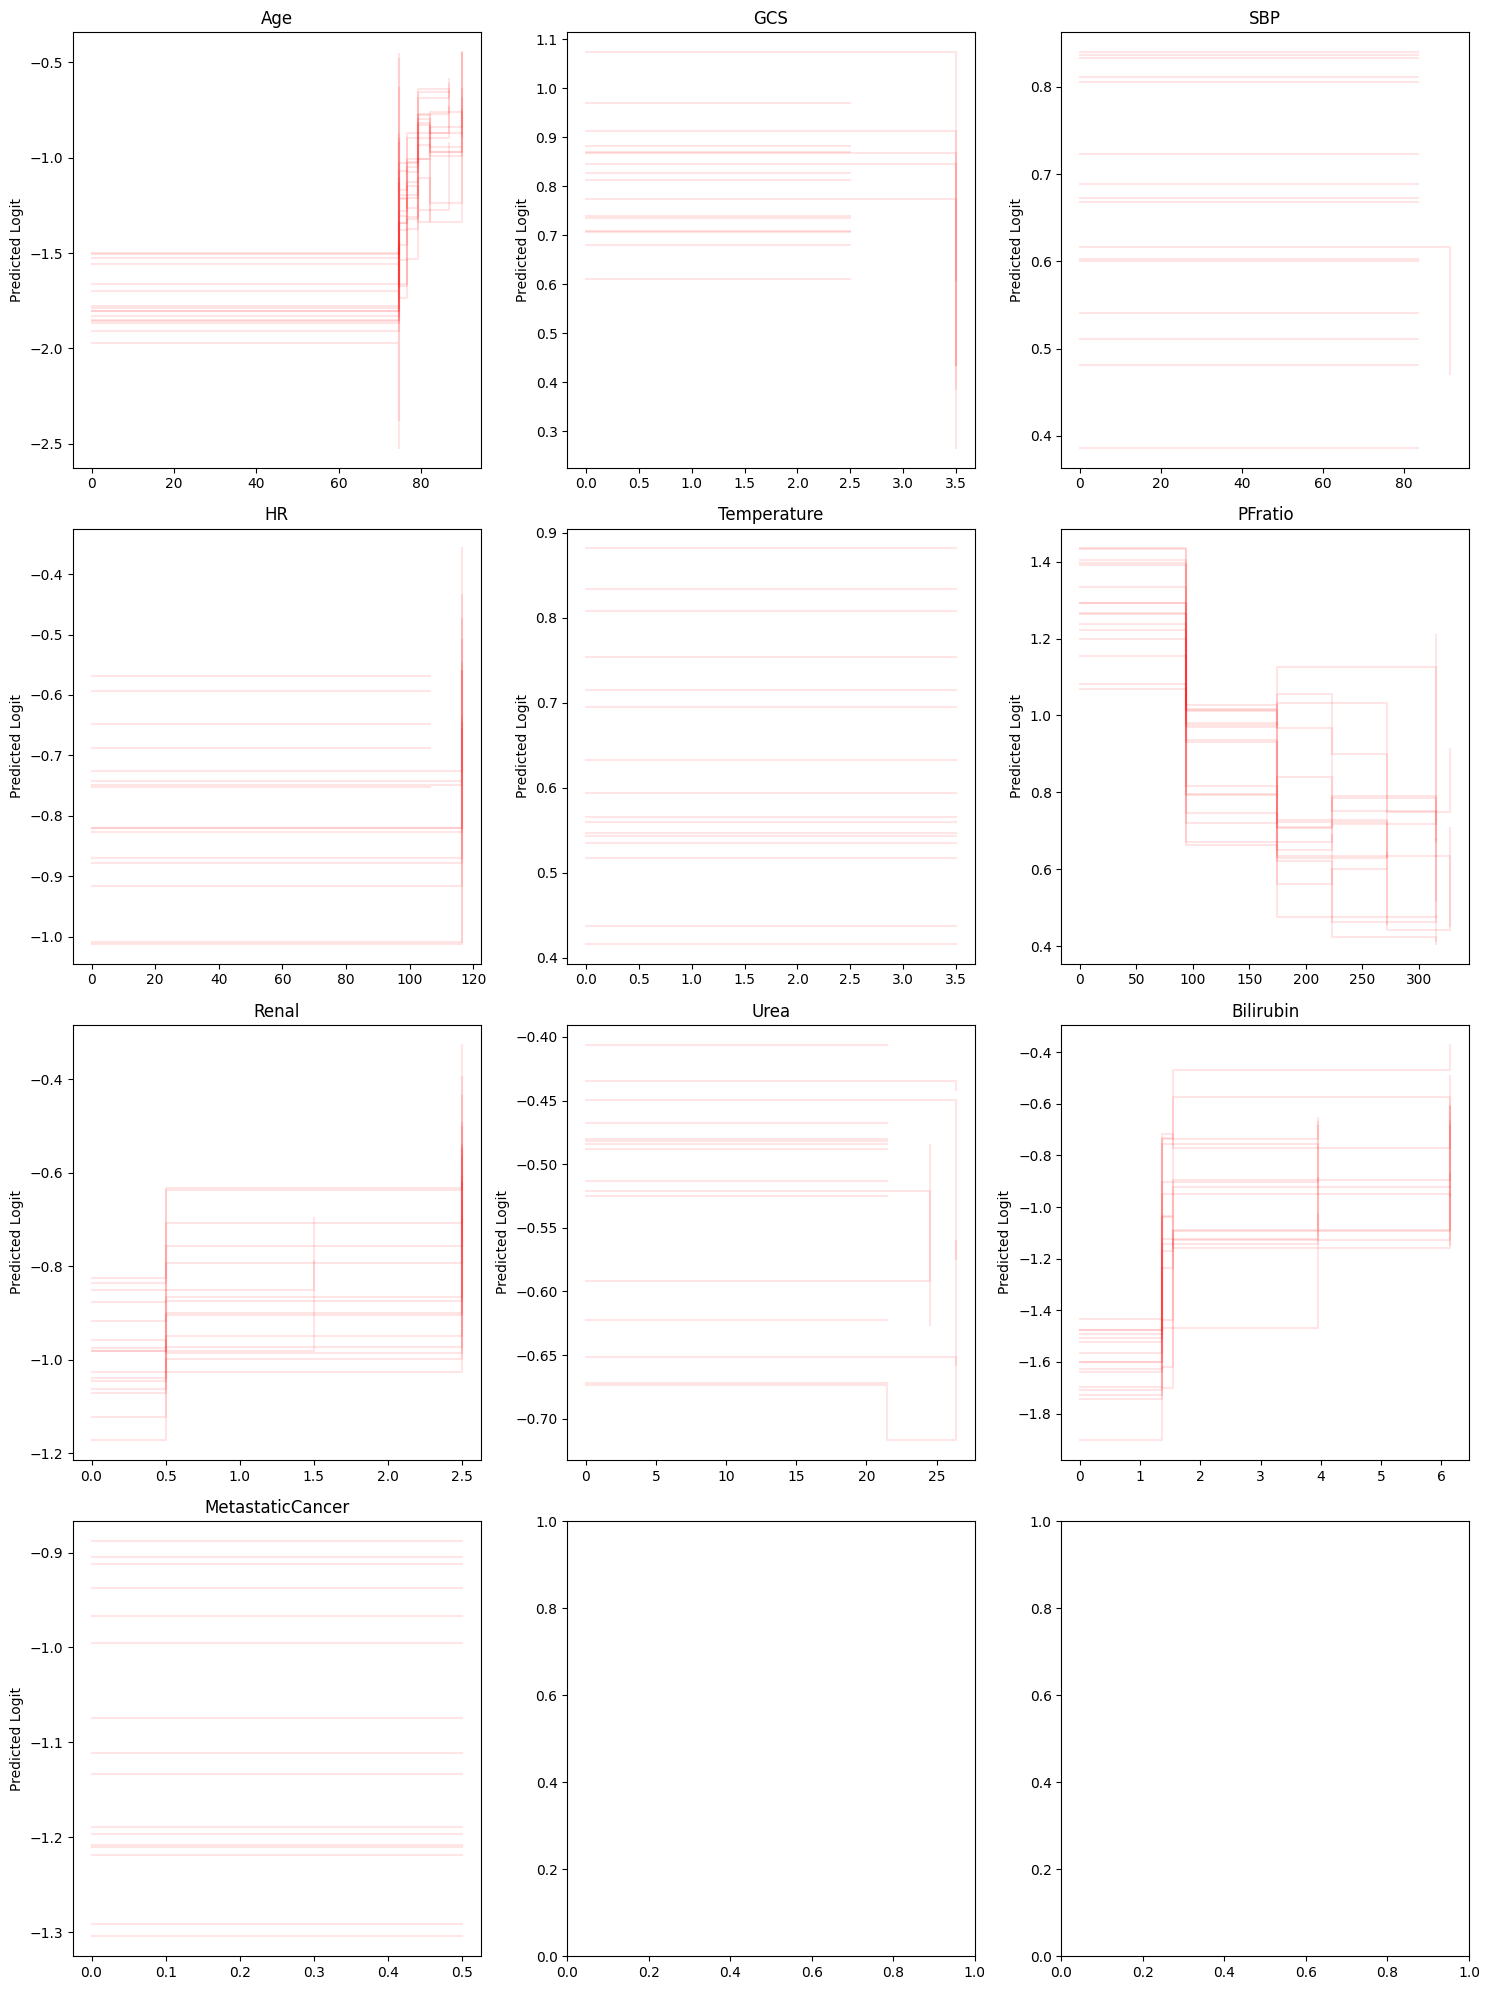

method: uniform_surface_ellipsoid_sampling


100%|██████████| 14/14 [00:00<00:00, 9763.93it/s]


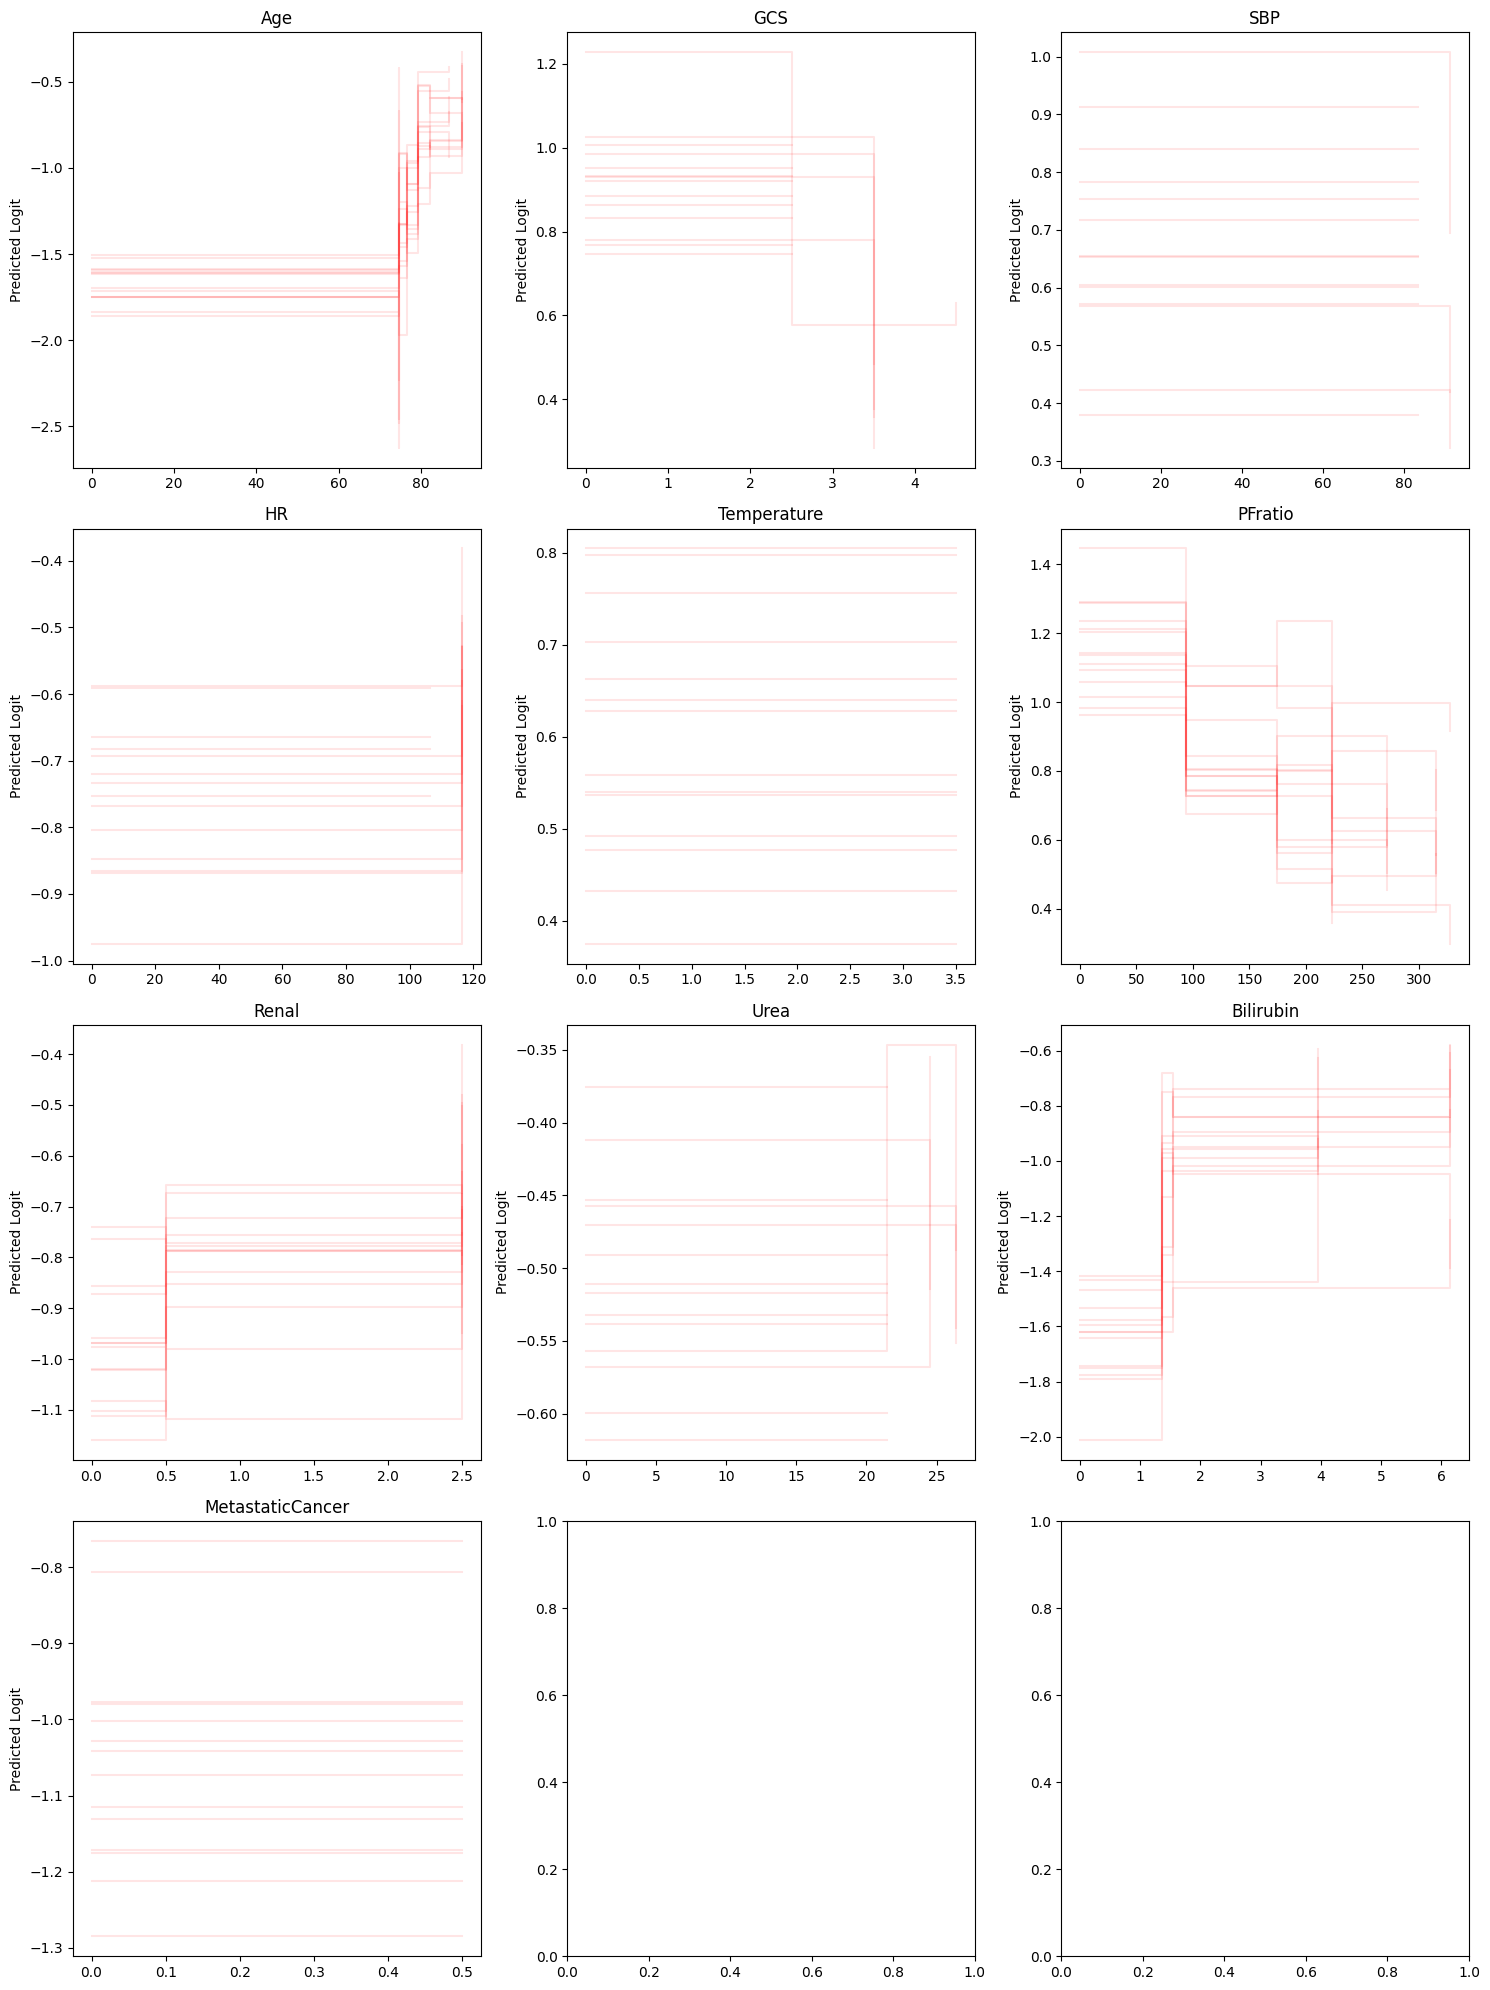

method: poisson__ellipsoid_sampling


100%|██████████| 6/6 [00:00<00:00, 7098.96it/s]


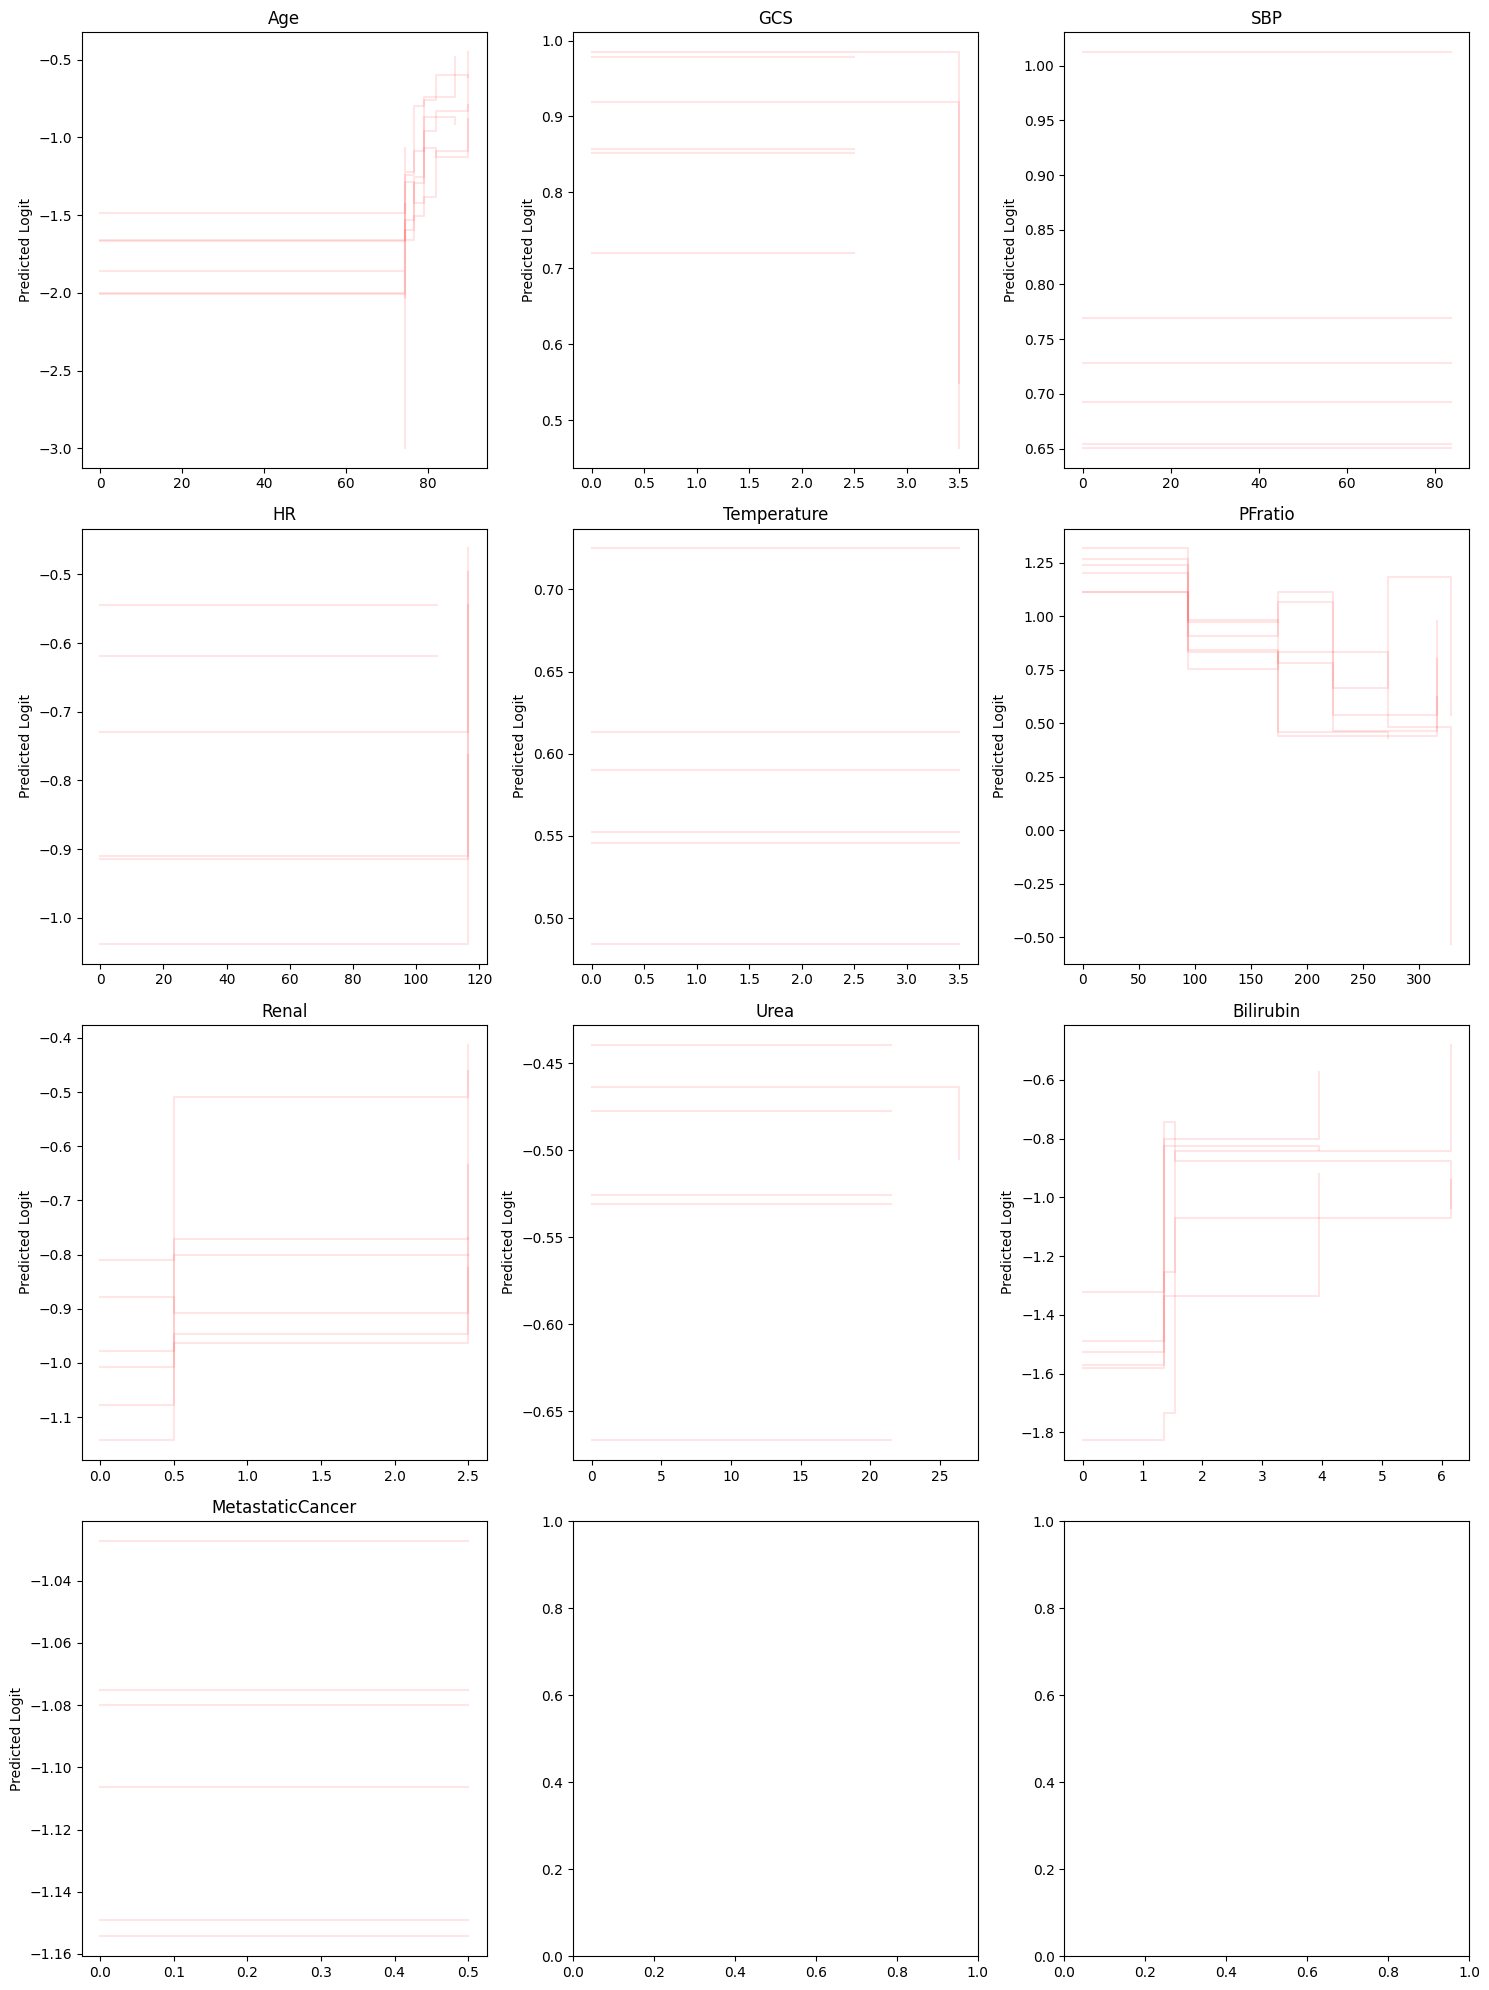

method: poisson_euclidean_ellipsoid_sampling


100%|██████████| 13/13 [00:00<00:00, 6231.54it/s]


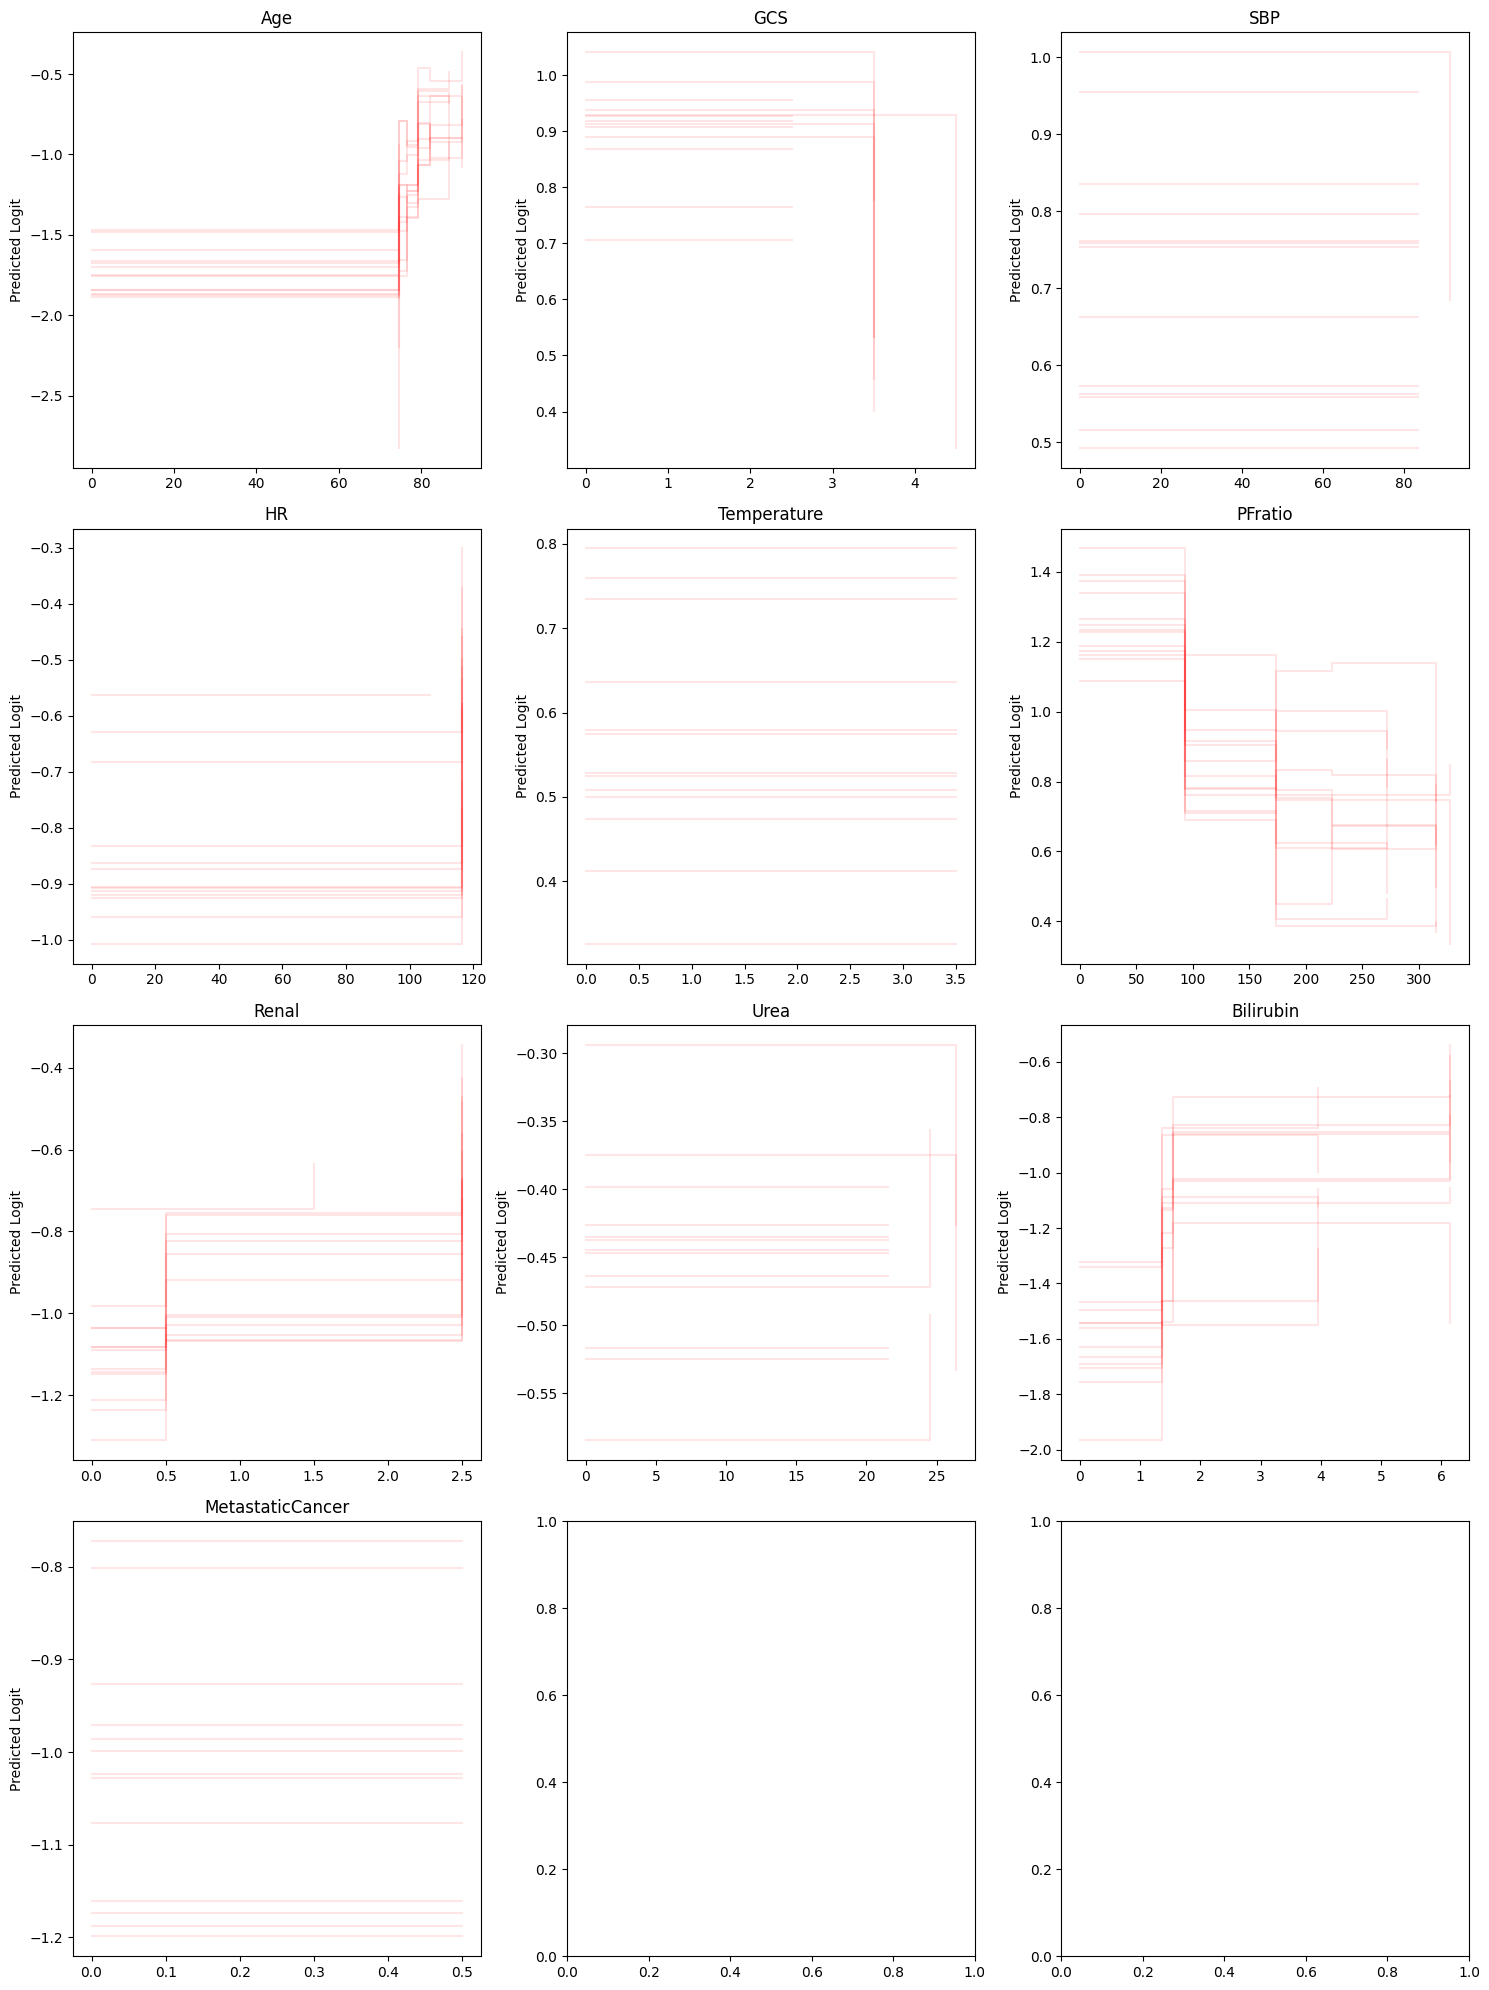

method: permutation__ellipsoid_sampling


100%|██████████| 20/20 [00:00<00:00, 6675.11it/s]


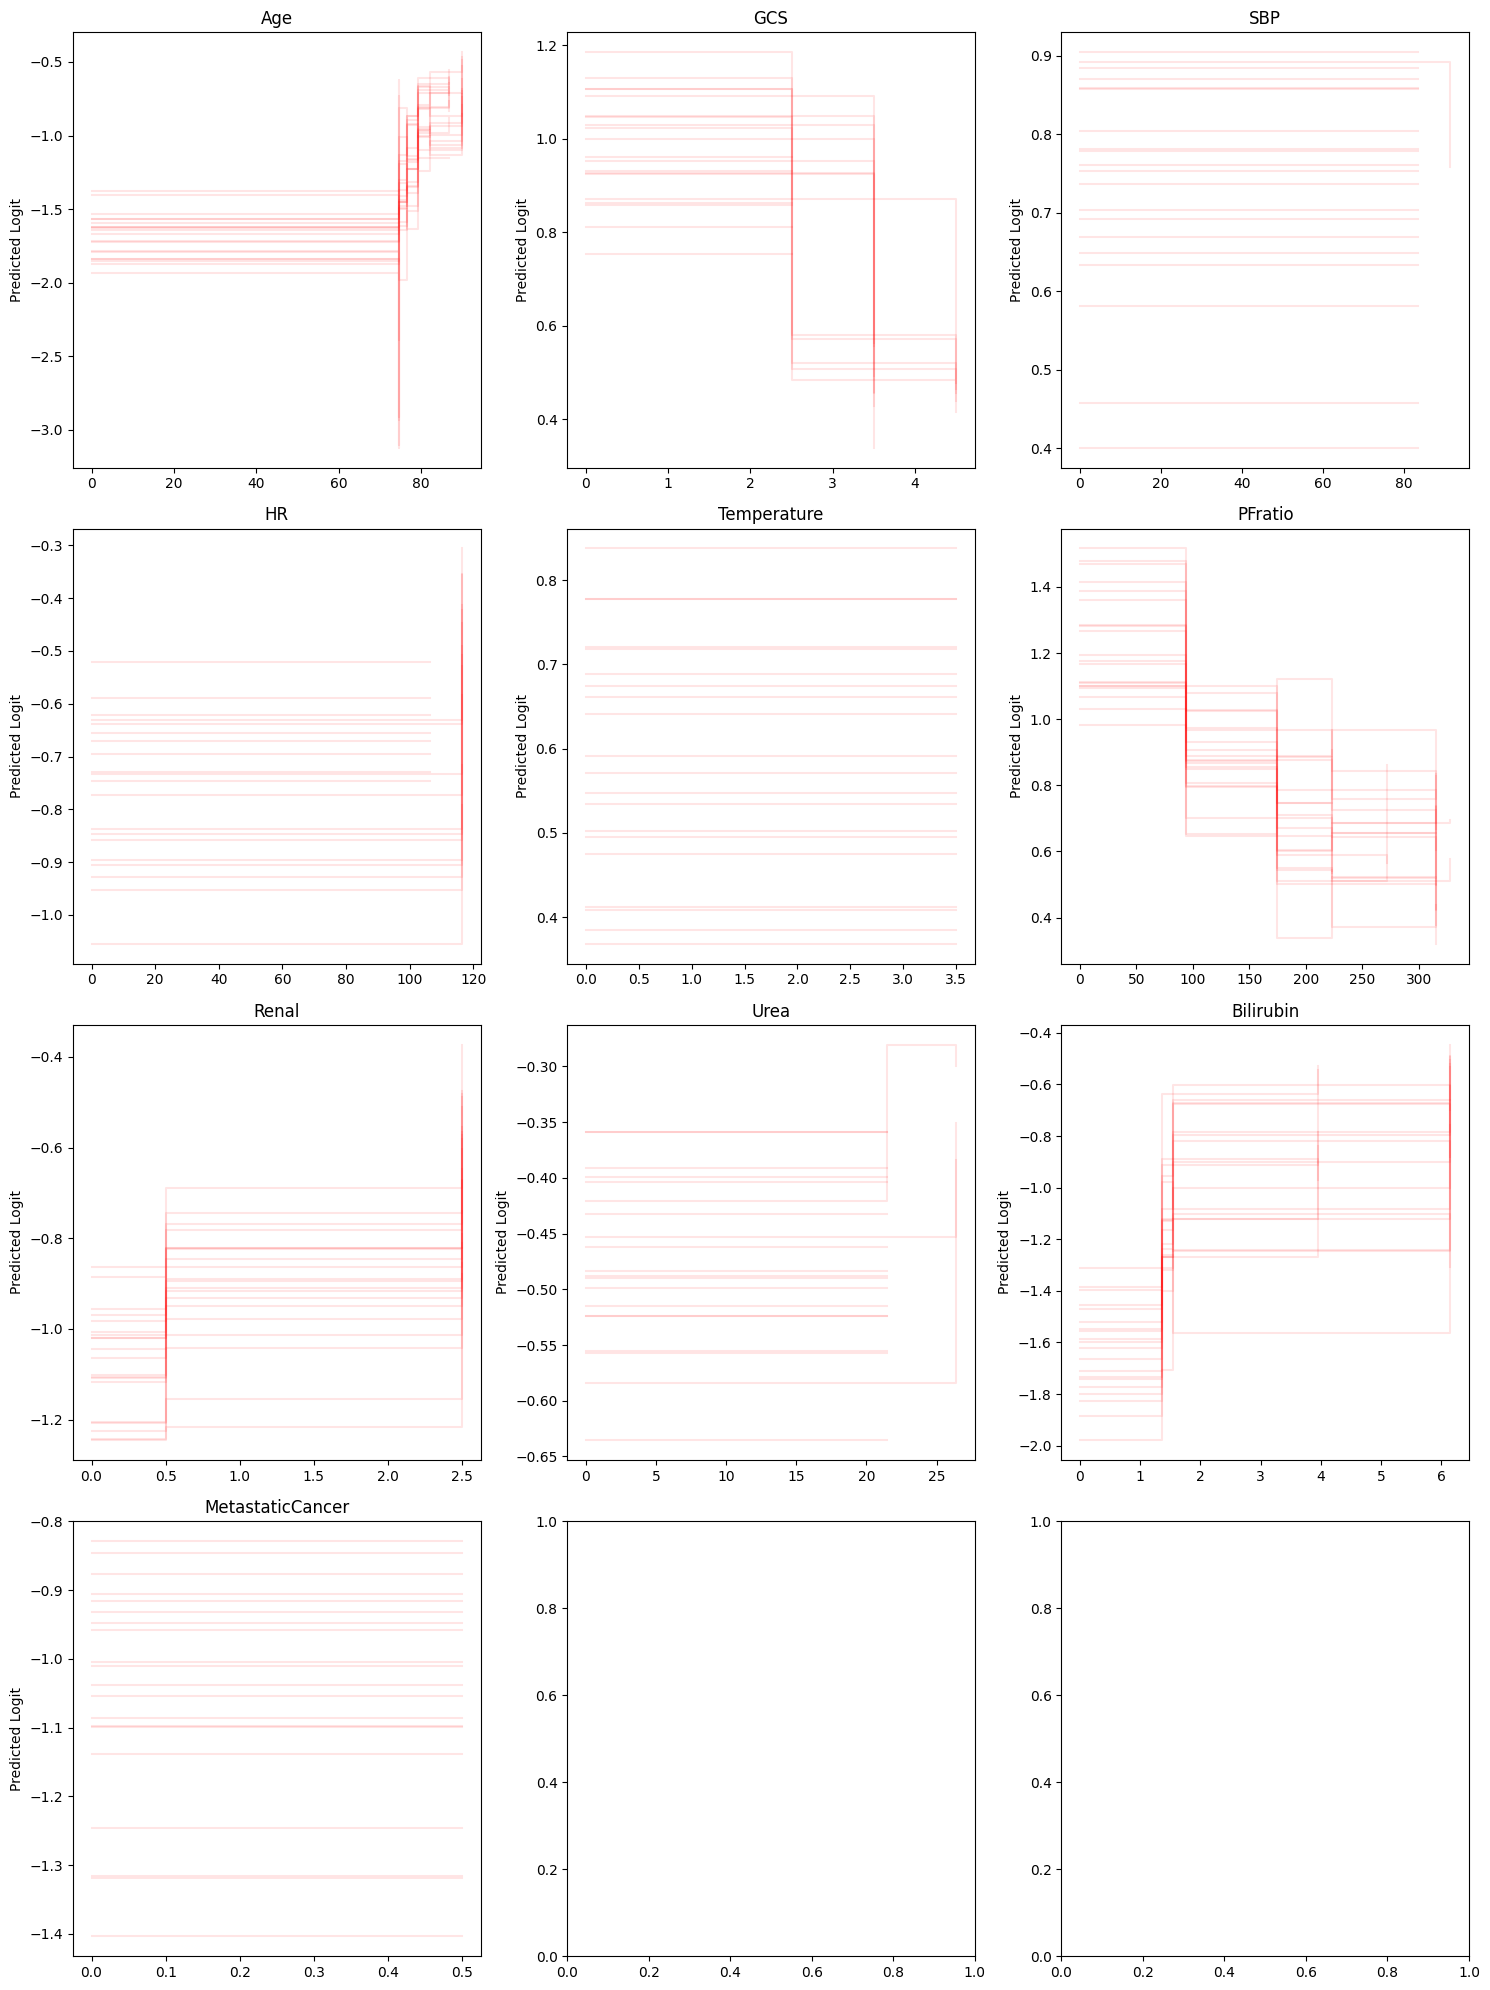

method: permutation_poisson_ellipsoid_sampling


100%|██████████| 8/8 [00:00<00:00, 5758.44it/s]


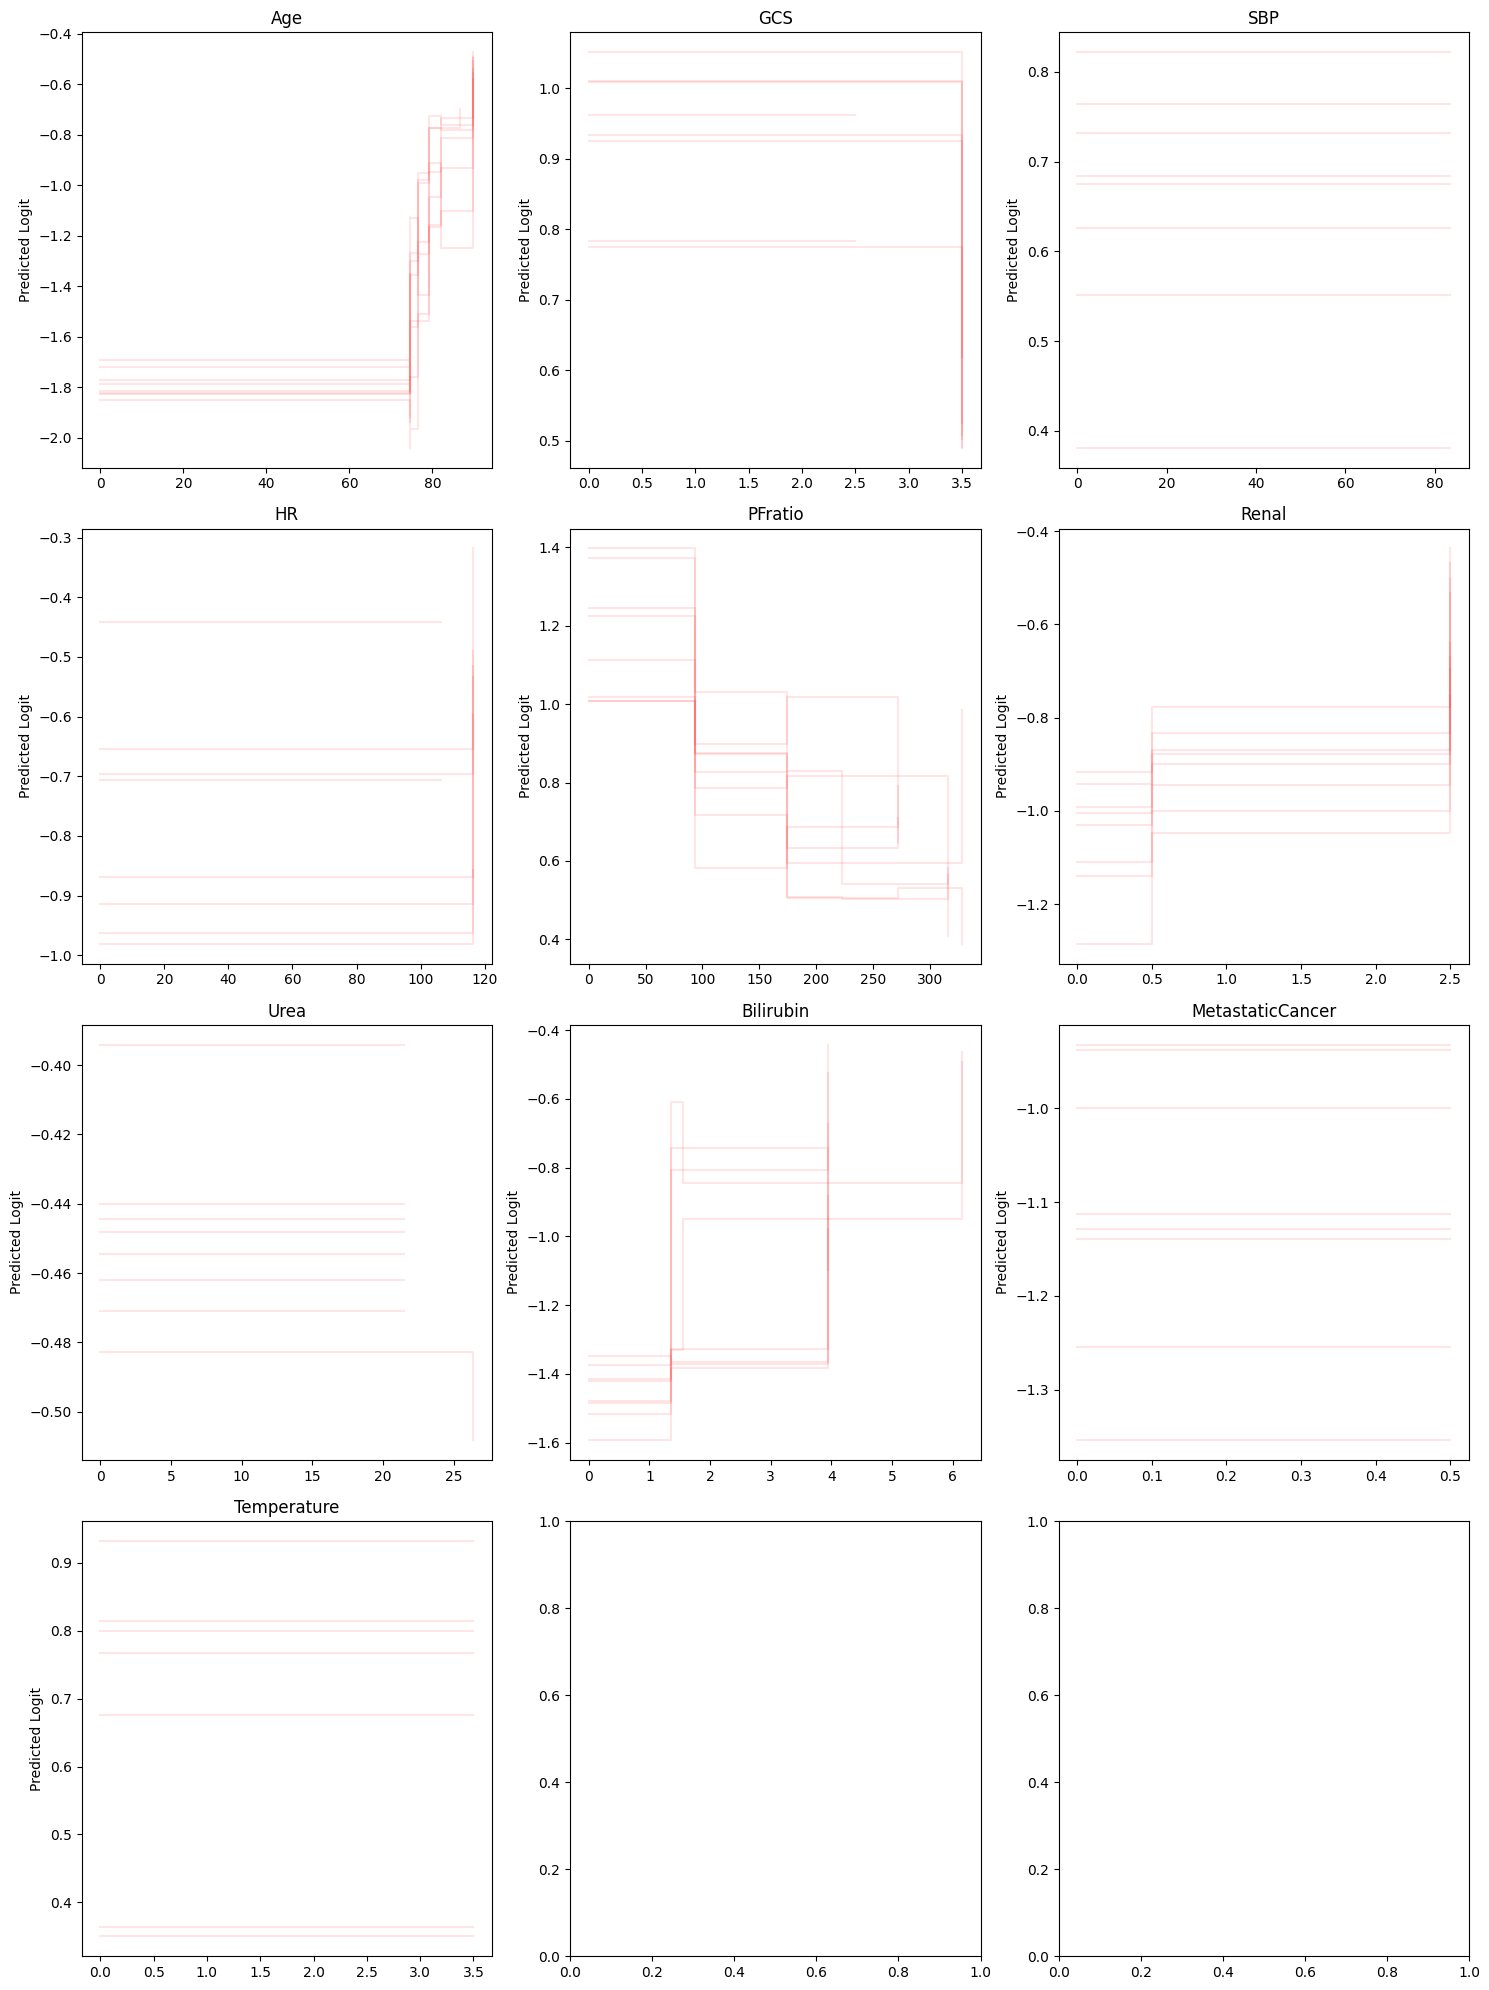

method: blocking


100%|██████████| 100/100 [00:00<00:00, 2858.21it/s]


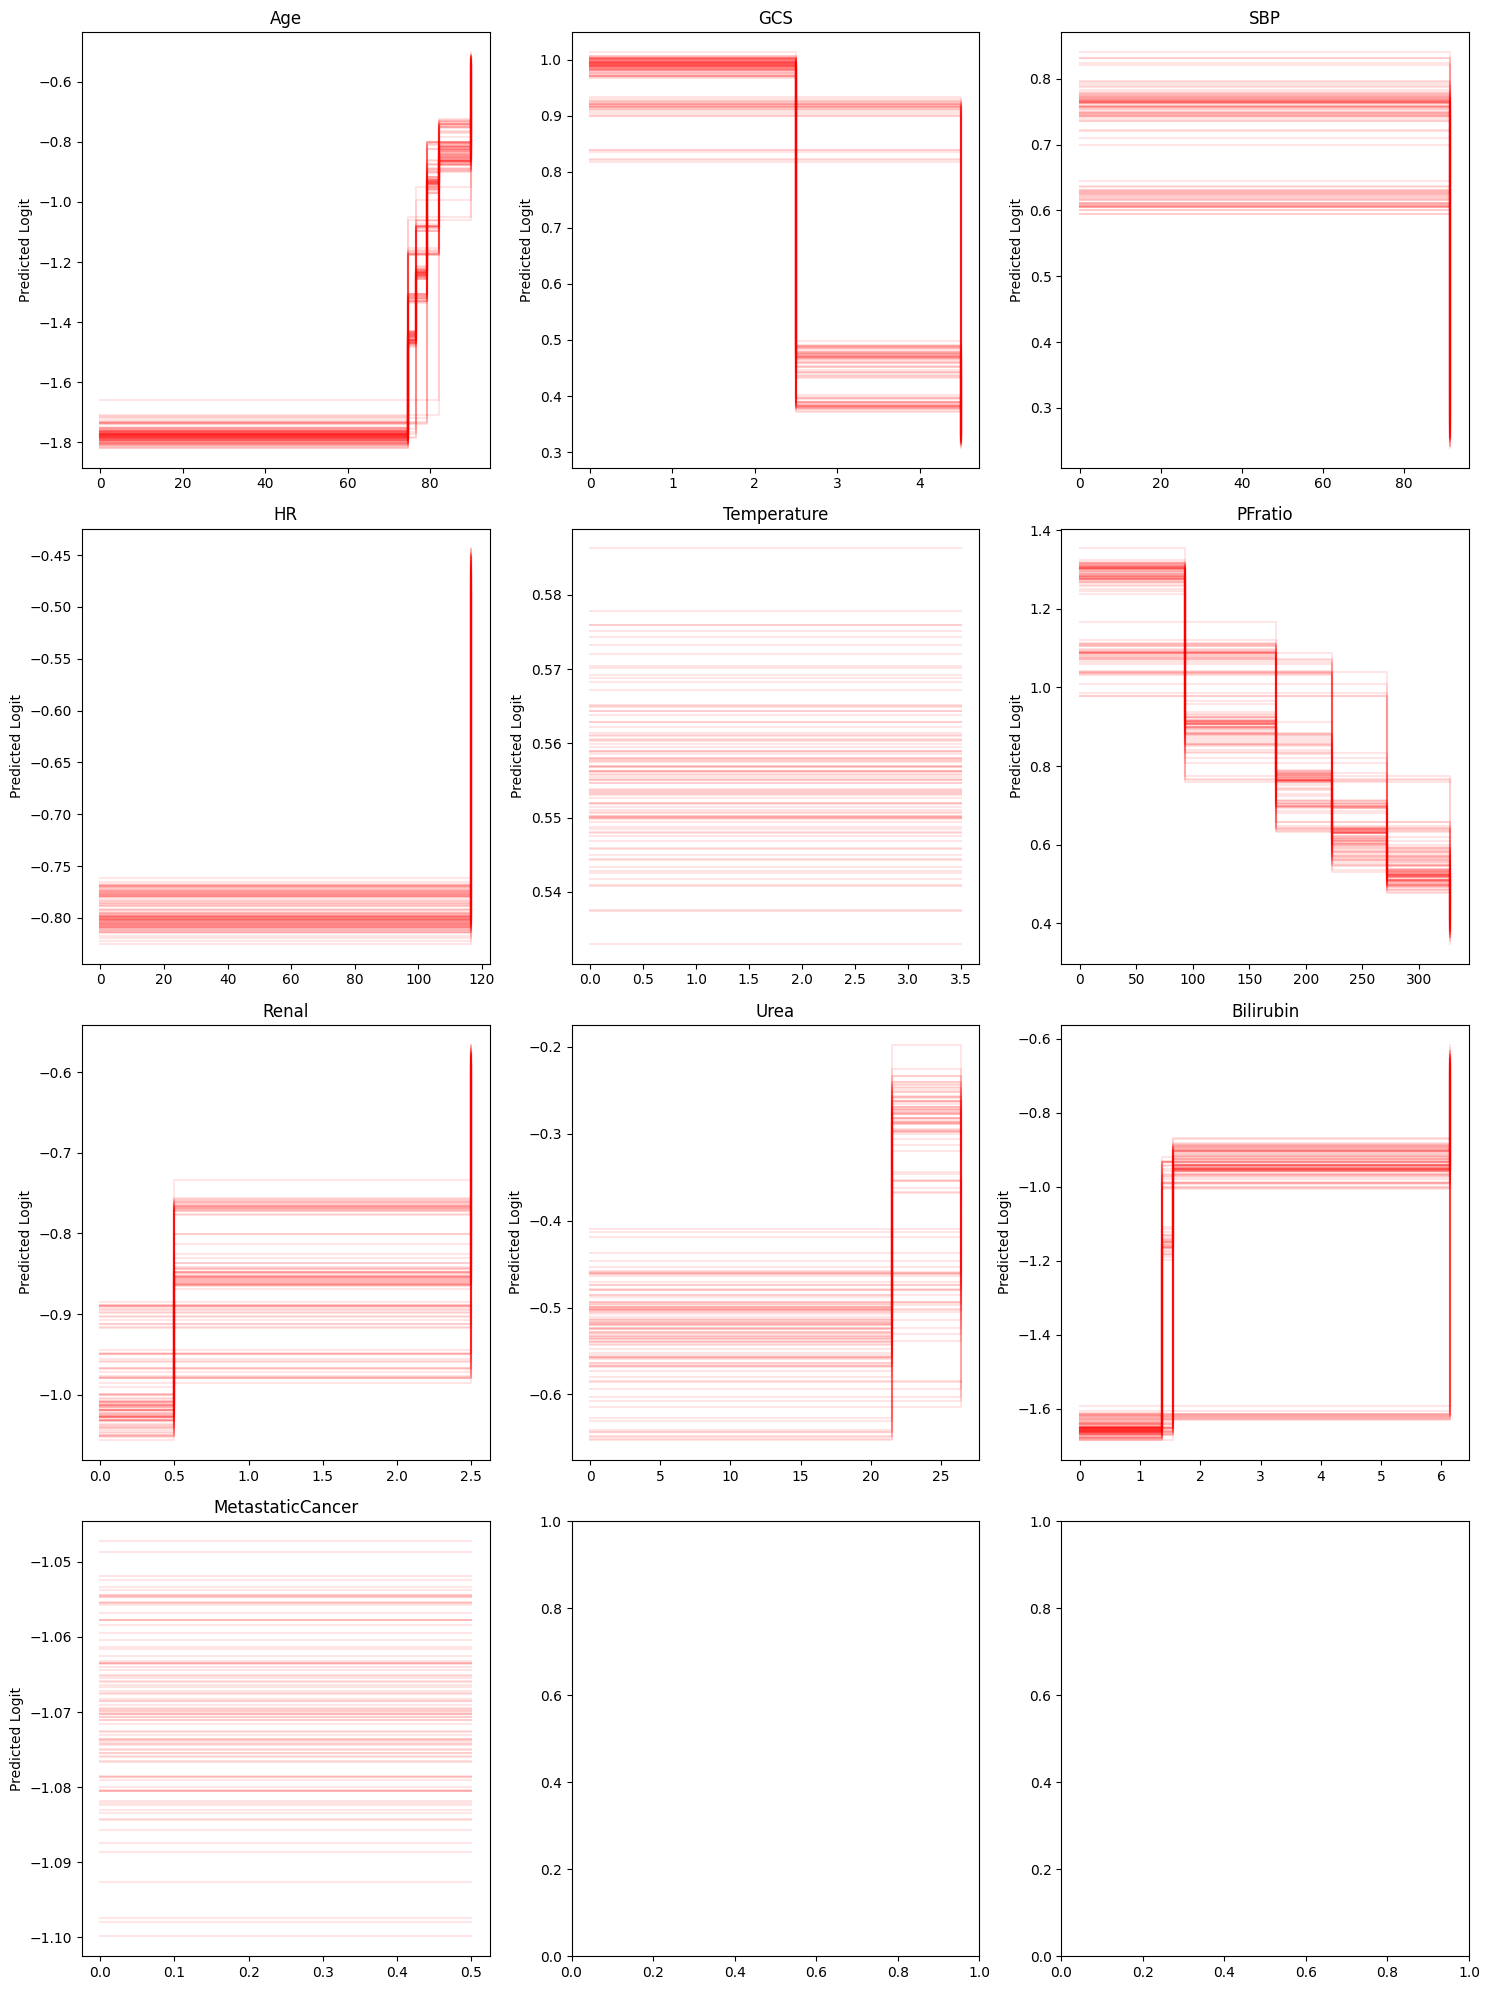

method: quadratic


100%|██████████| 100/100 [00:00<00:00, 8843.33it/s]


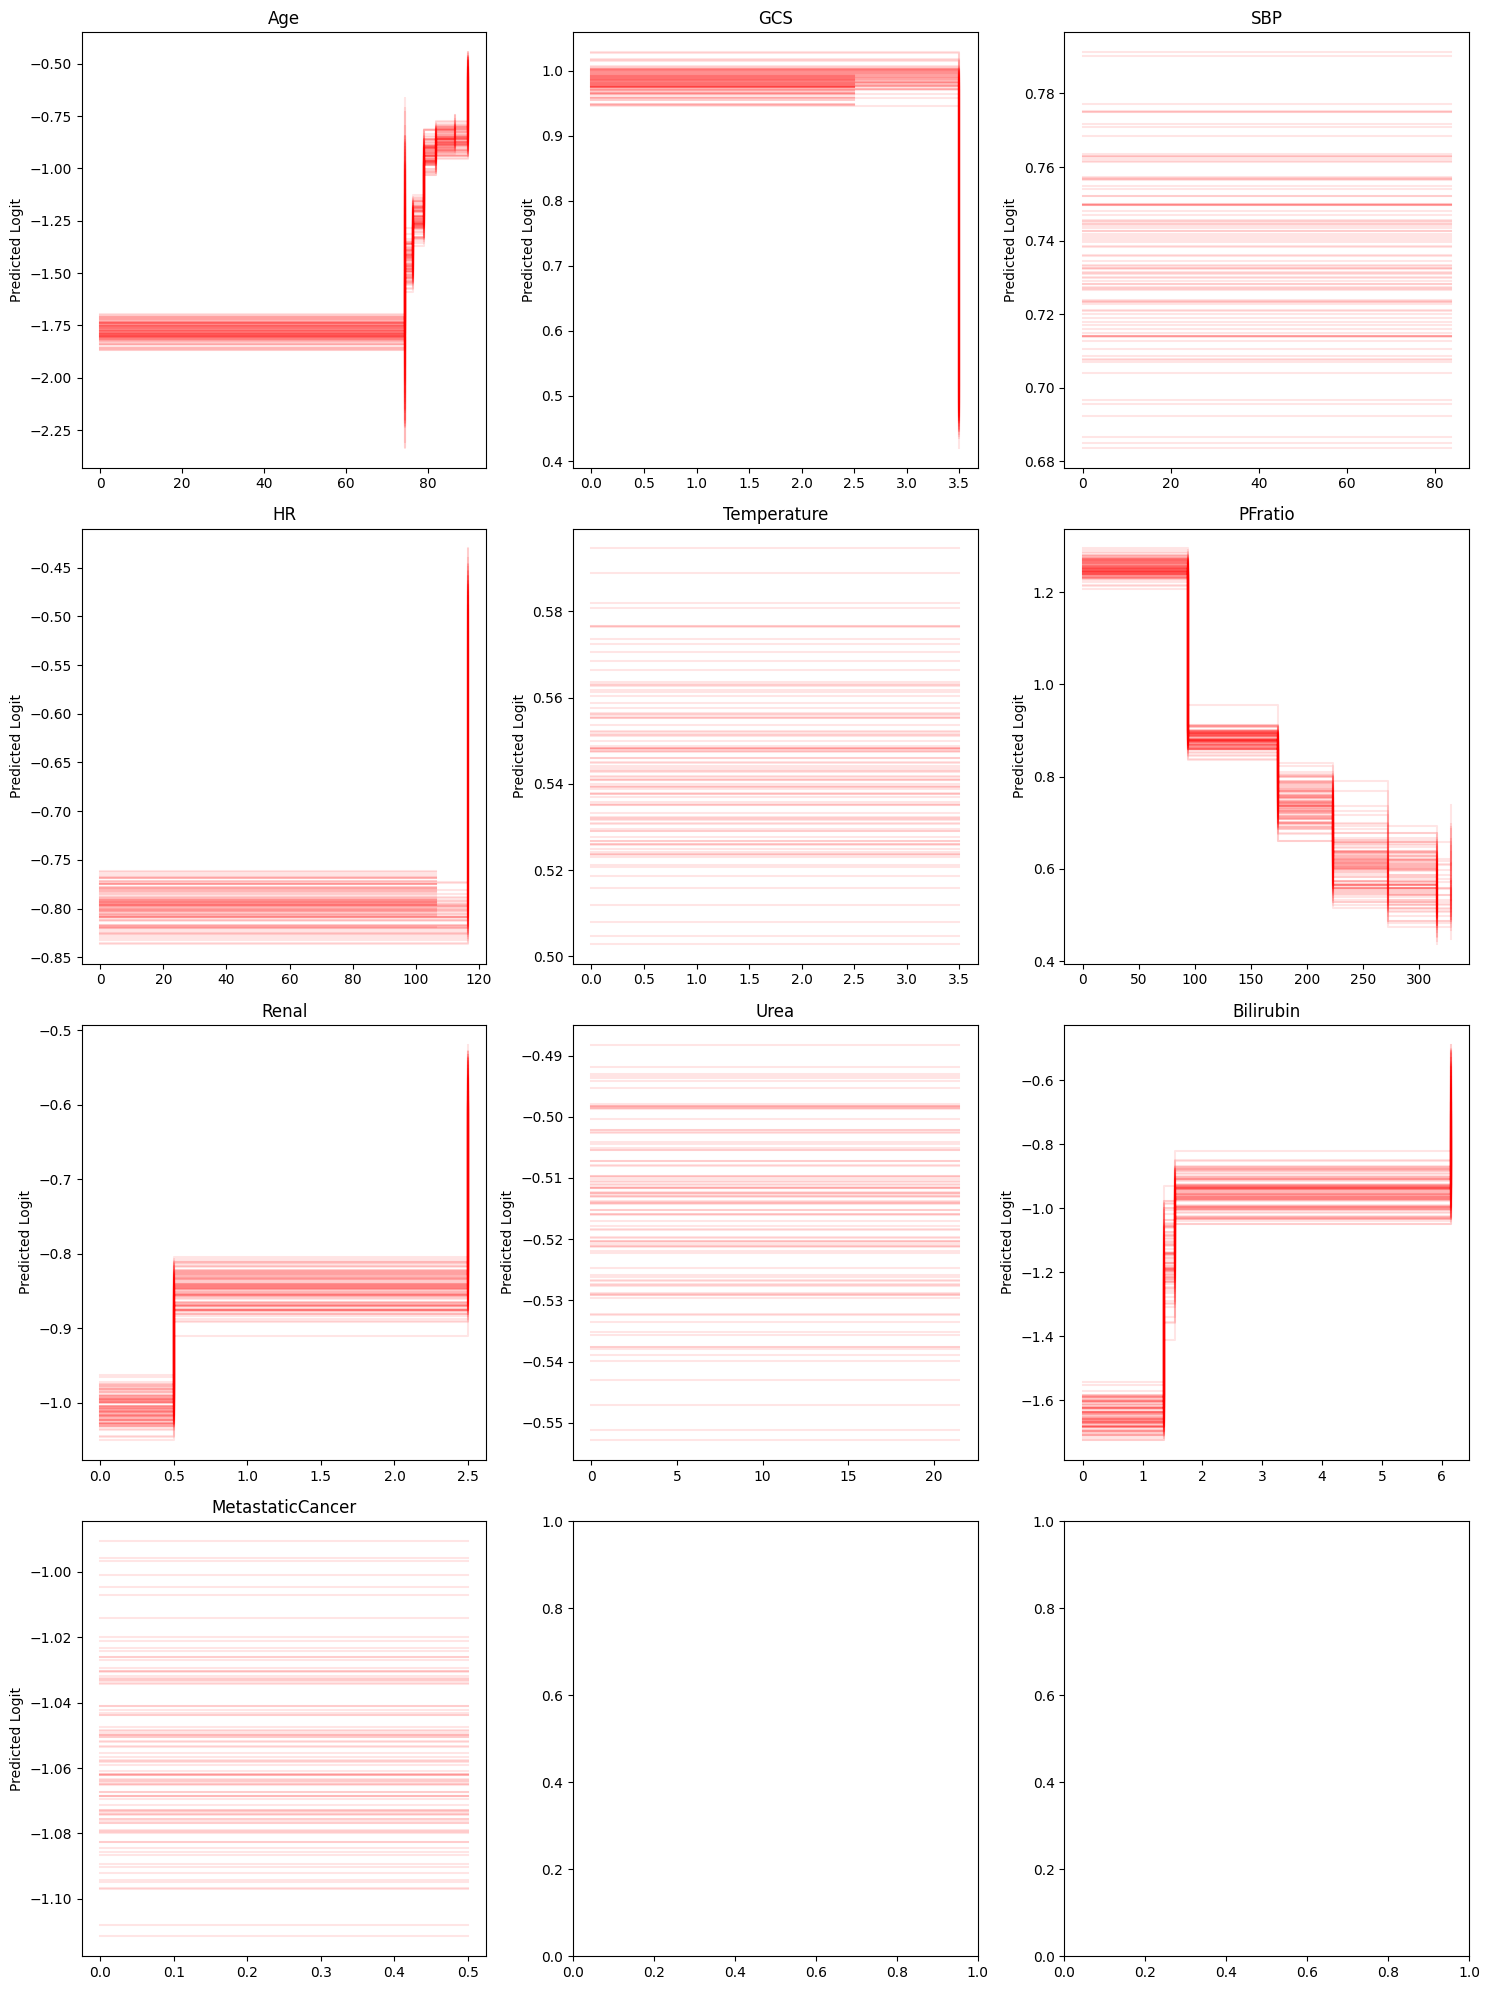

method: swapping_1


100%|██████████| 100/100 [00:00<00:00, 8900.76it/s]


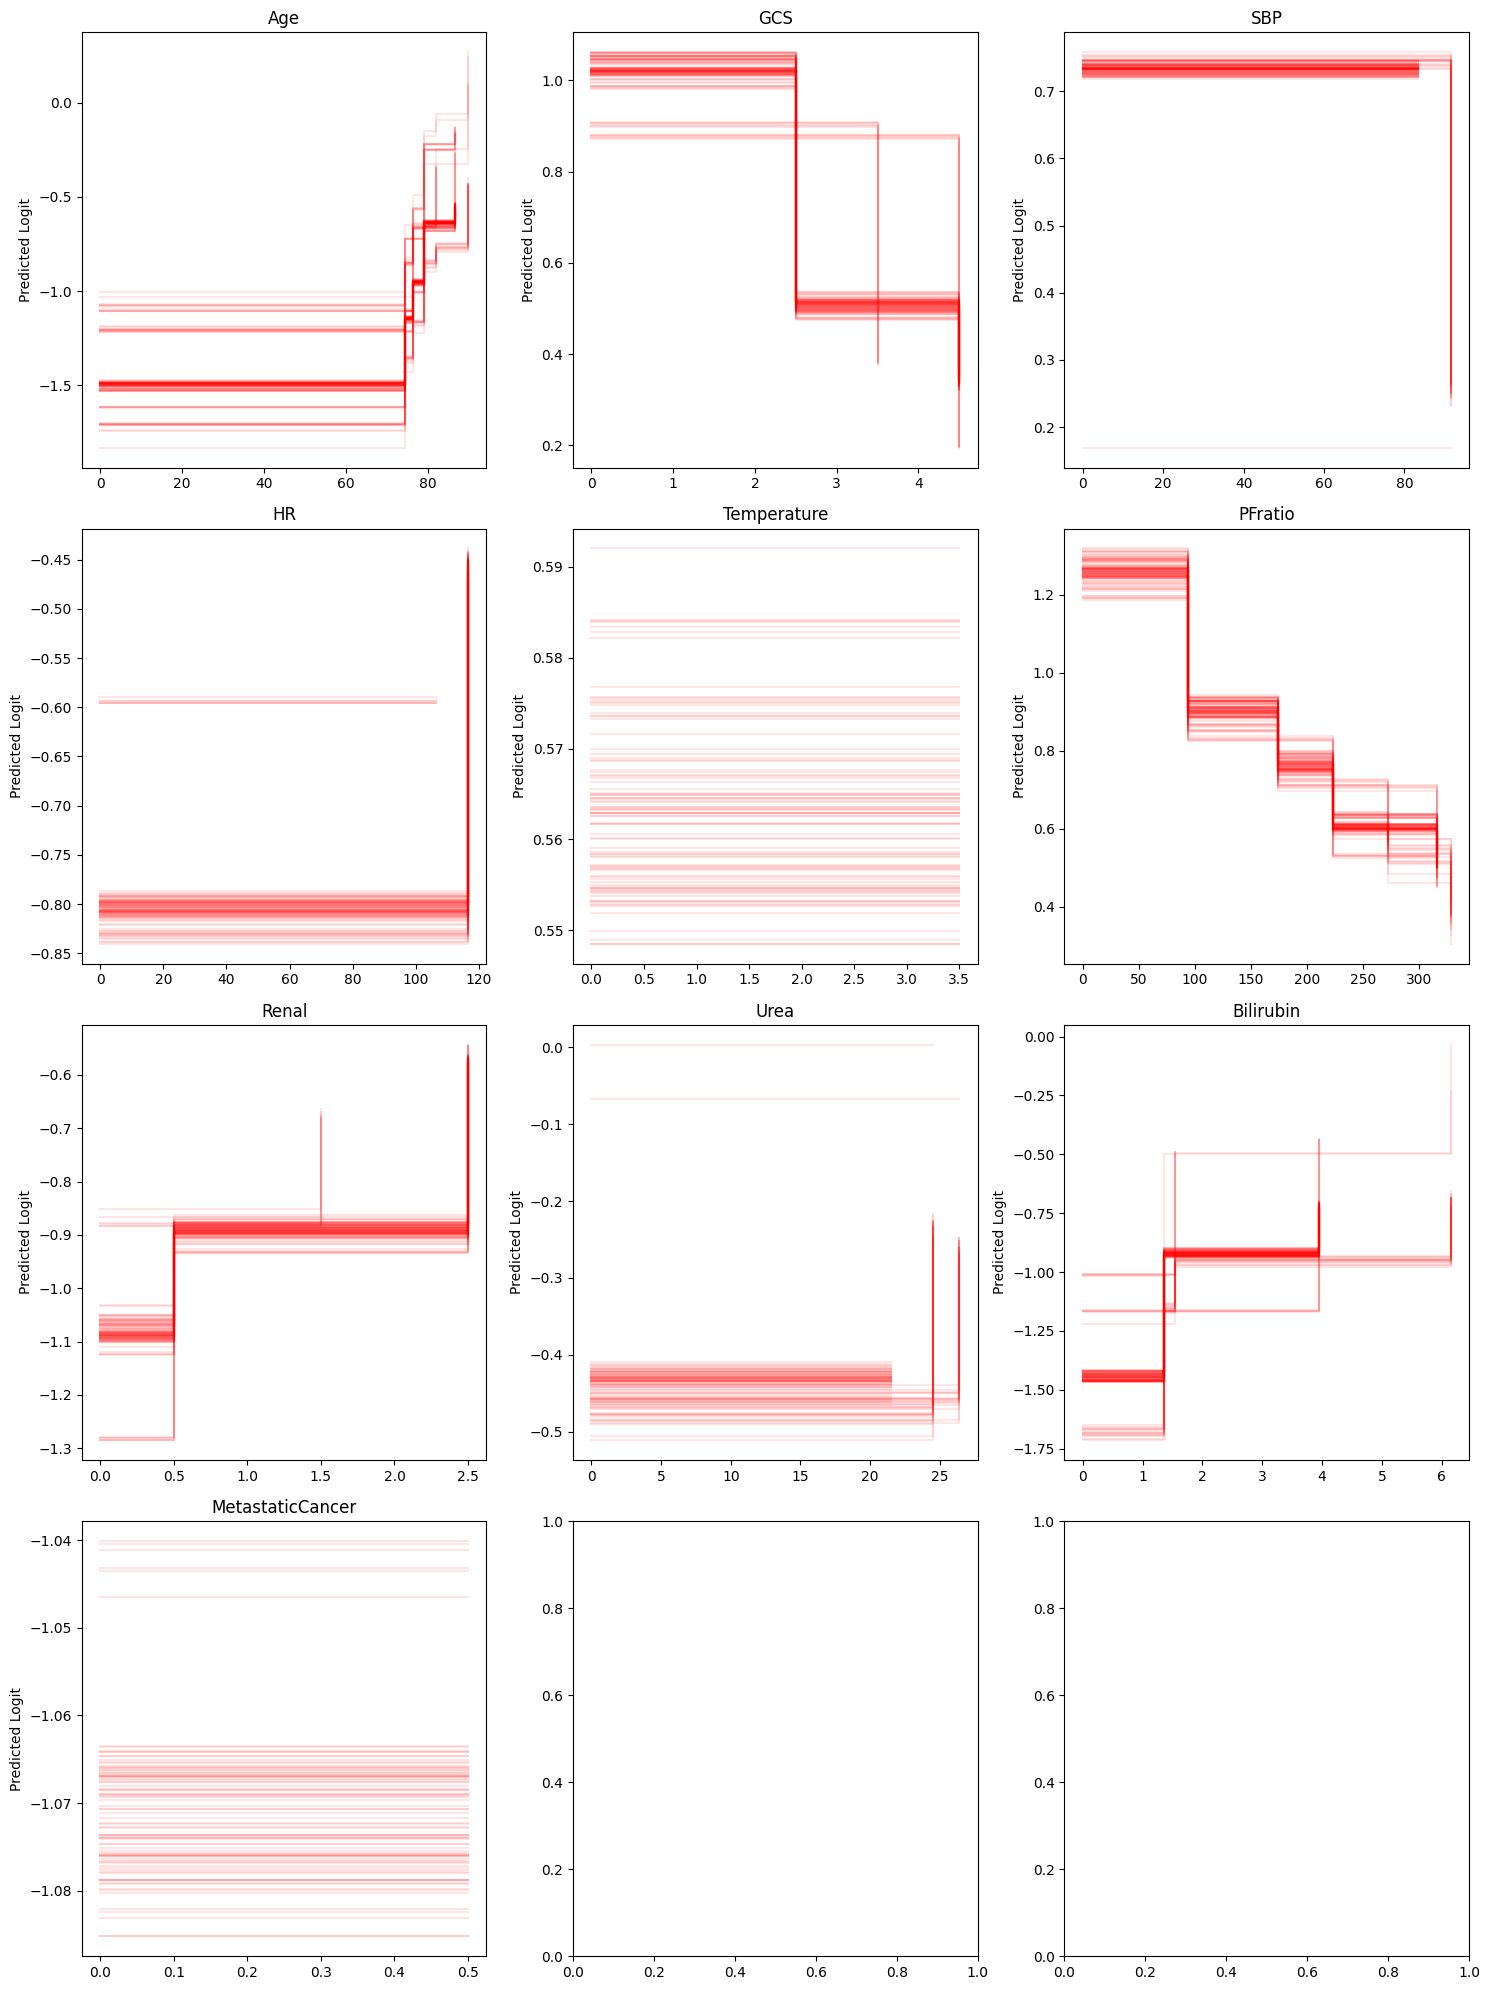

method: swapping_2


100%|██████████| 100/100 [00:00<00:00, 4044.65it/s]


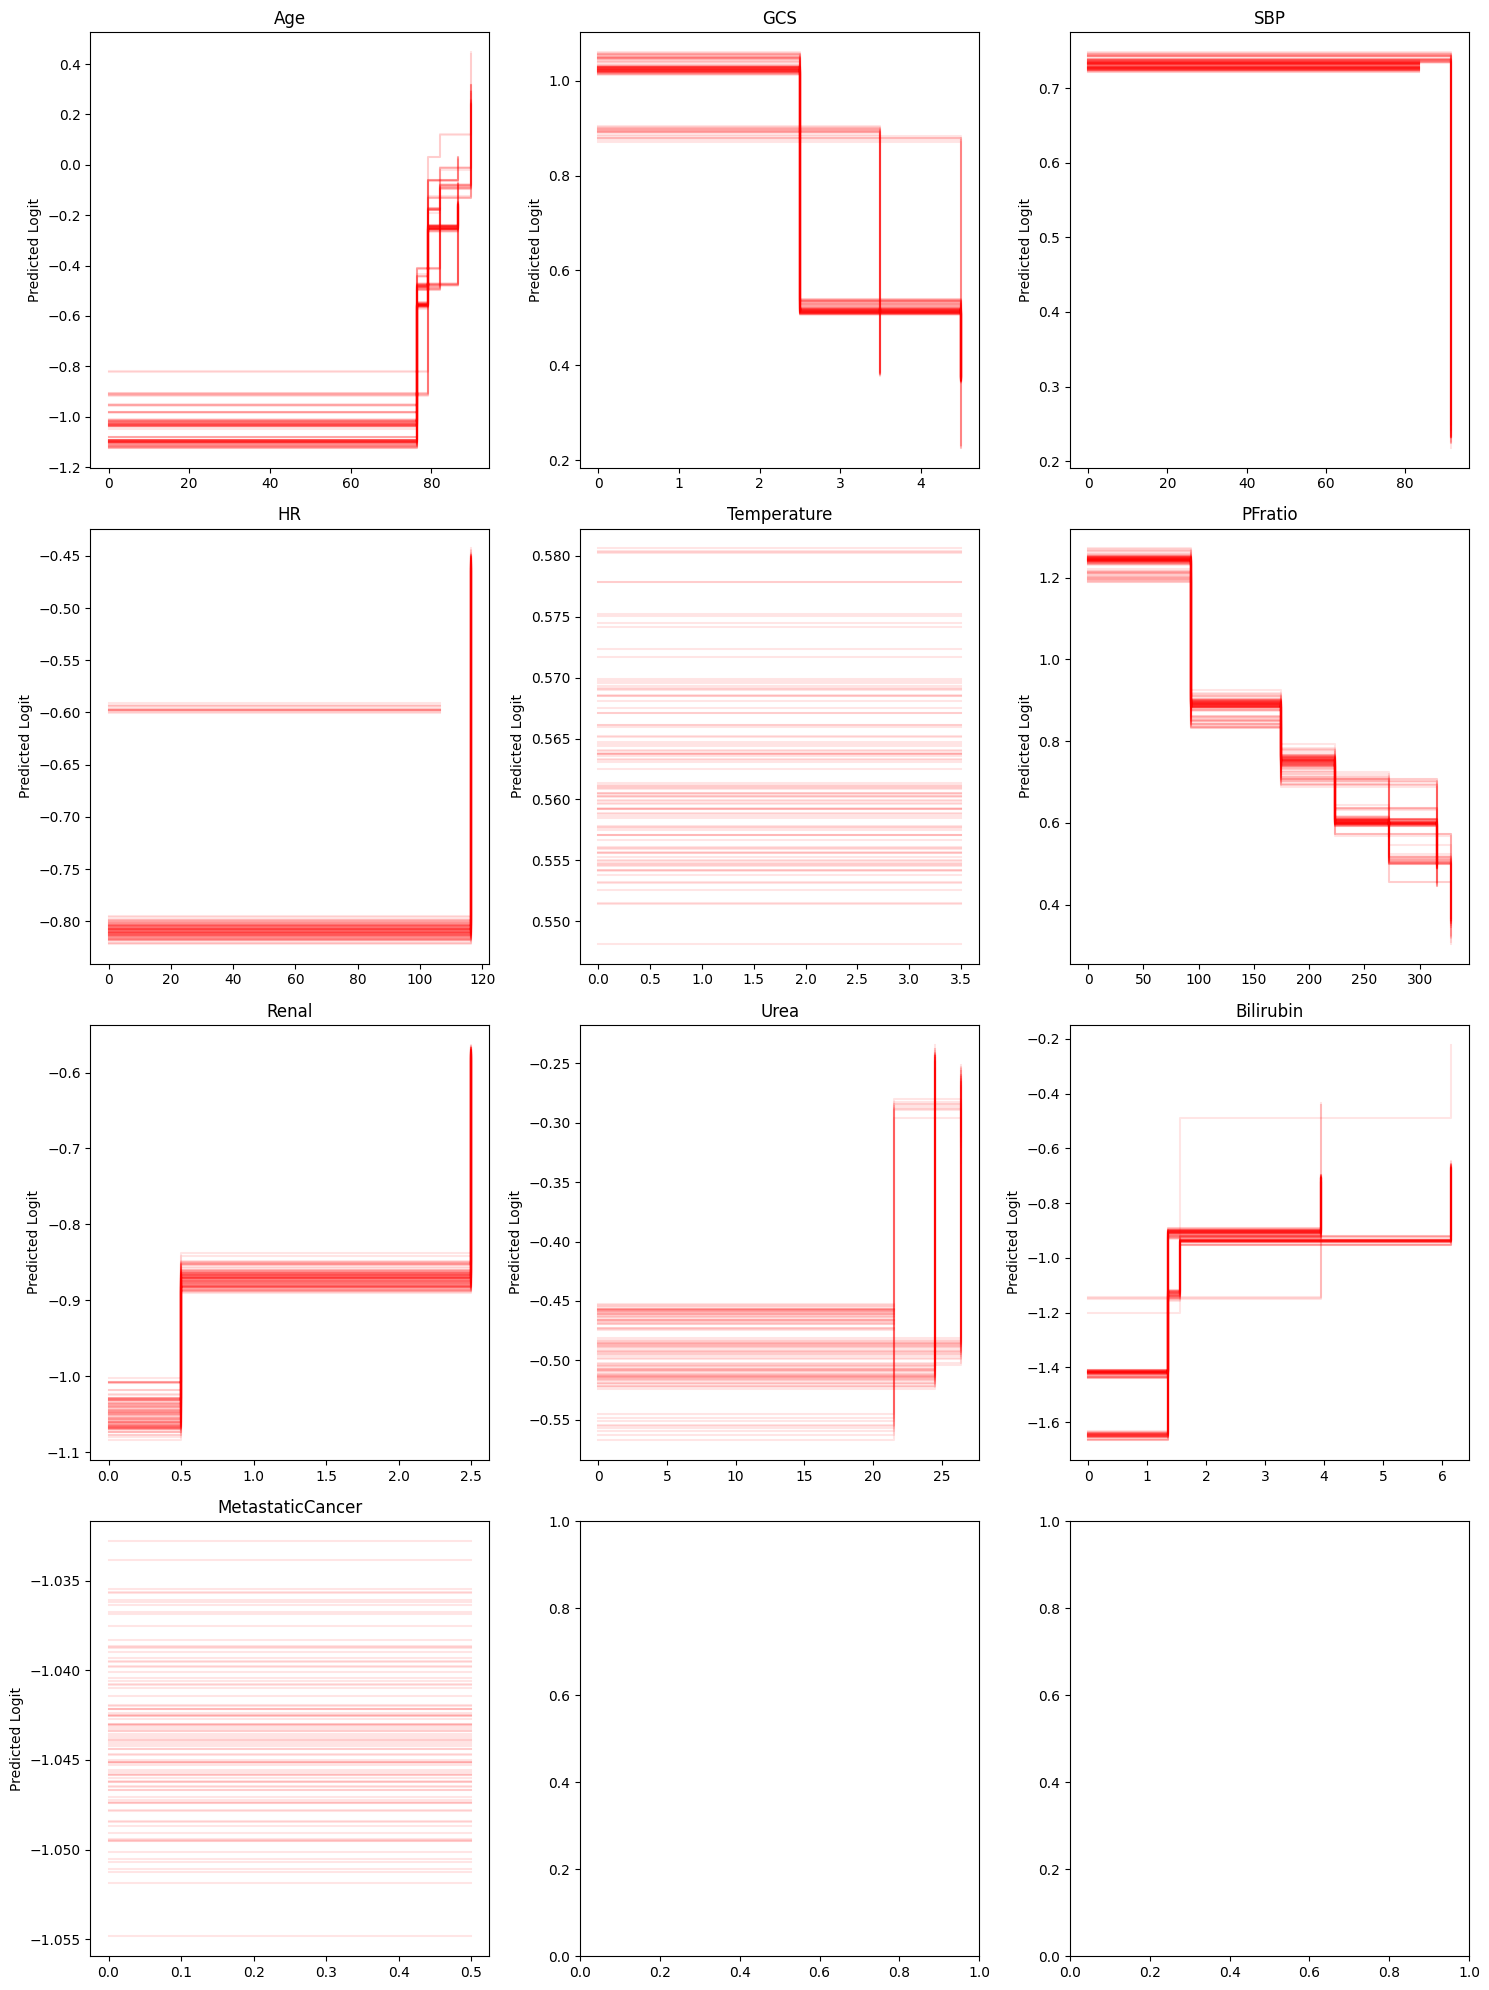

method: swapping_3


100%|██████████| 100/100 [00:00<00:00, 9844.40it/s]


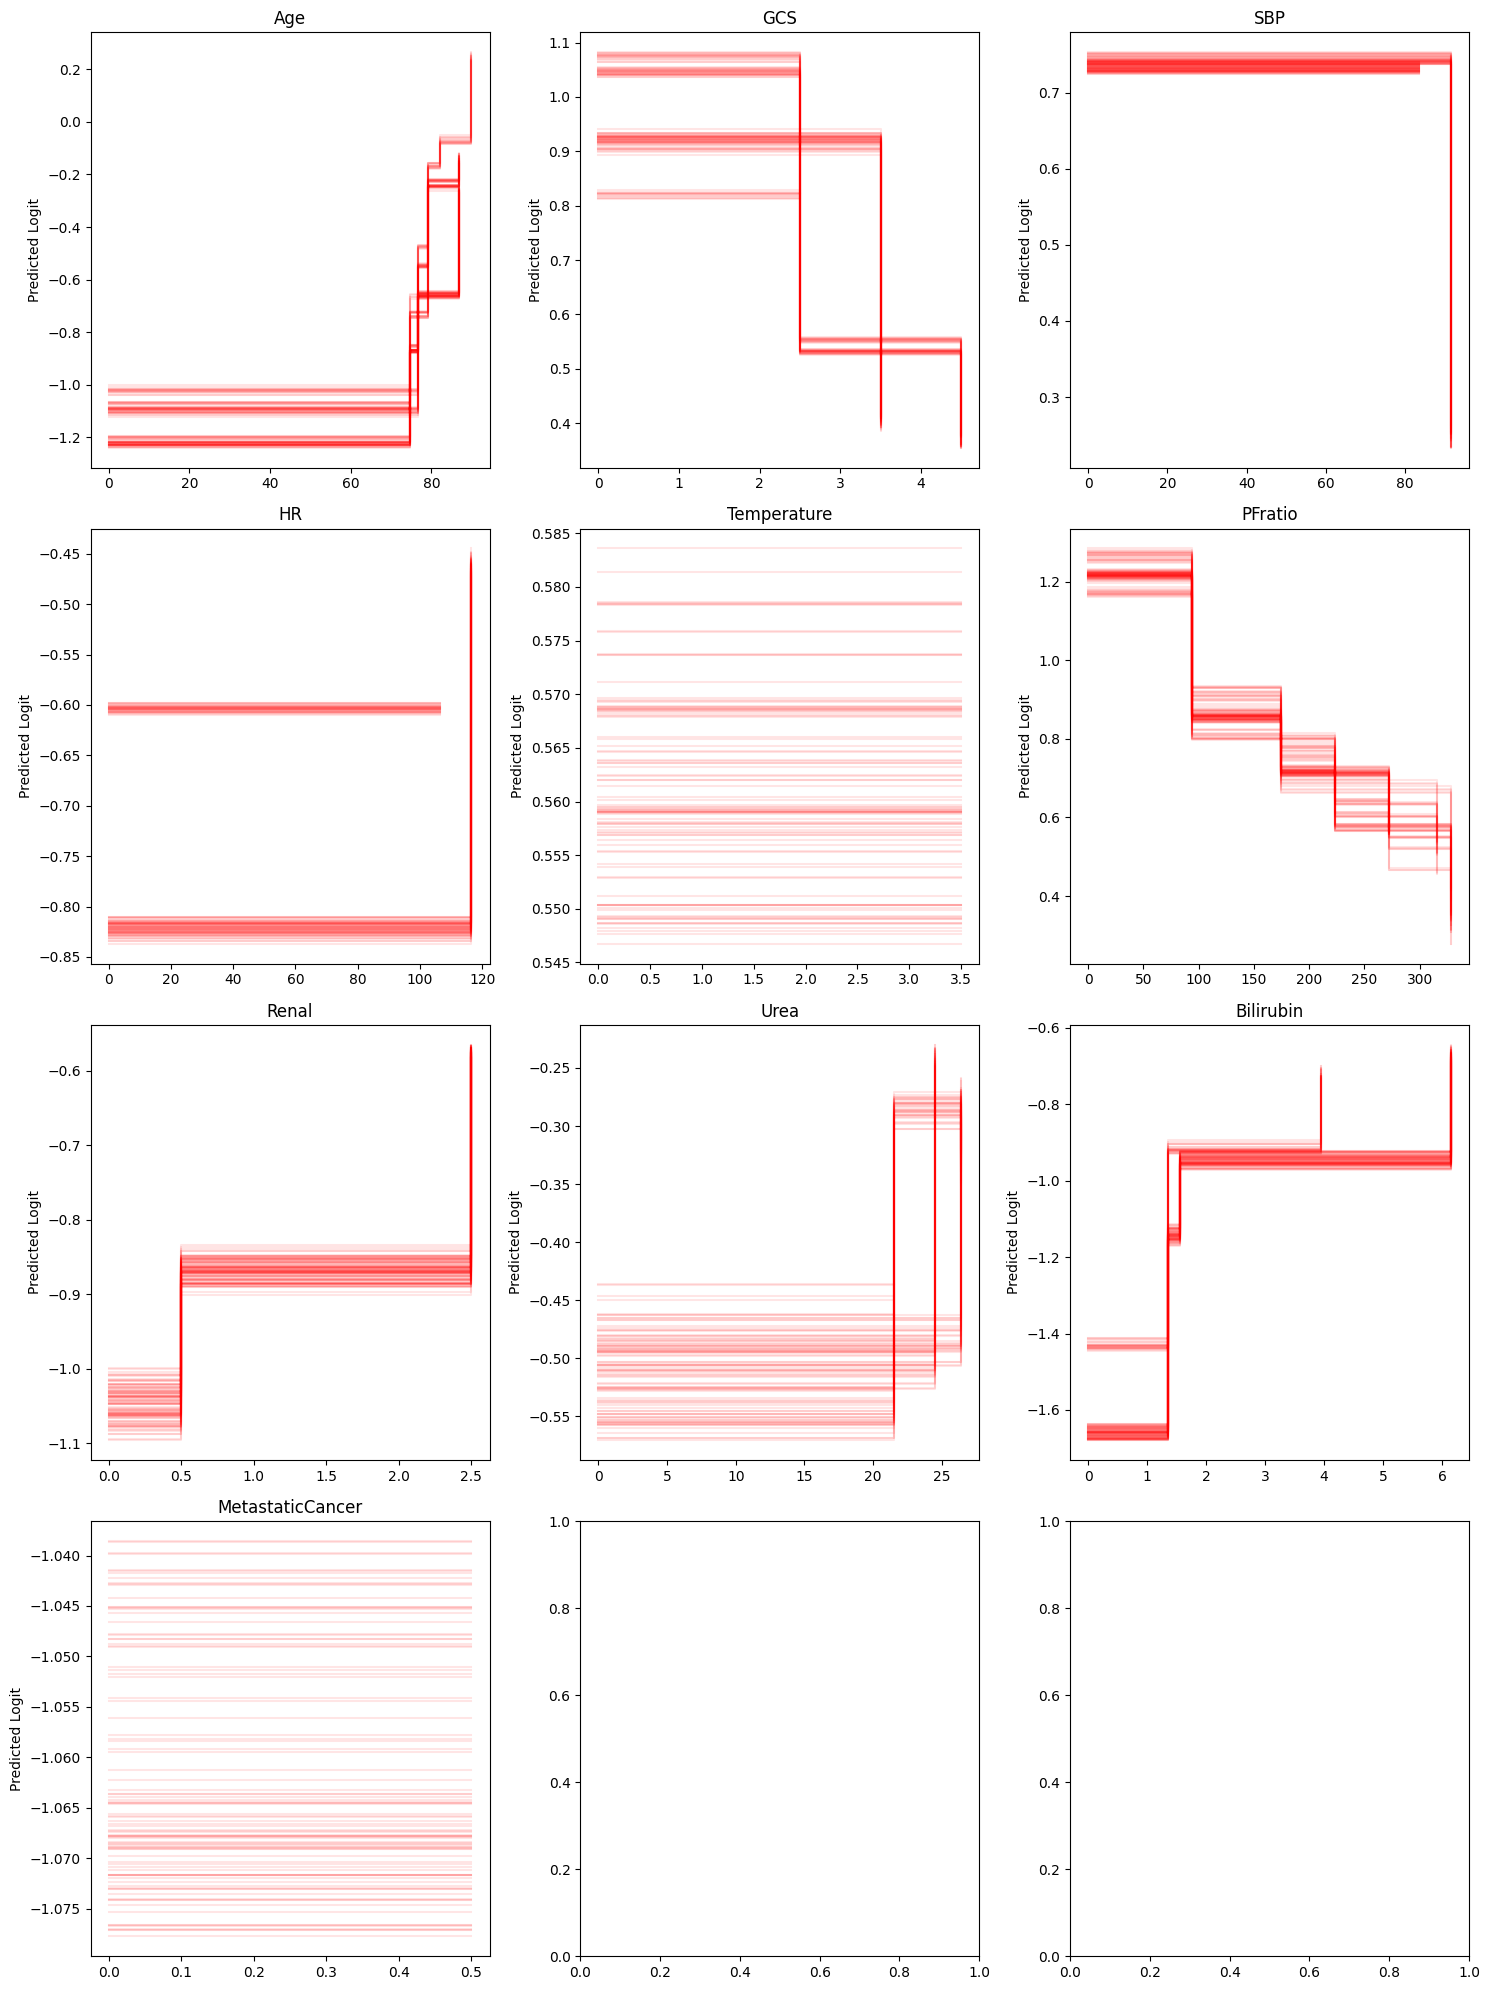

method: swapping_4


100%|██████████| 100/100 [00:00<00:00, 9260.38it/s]


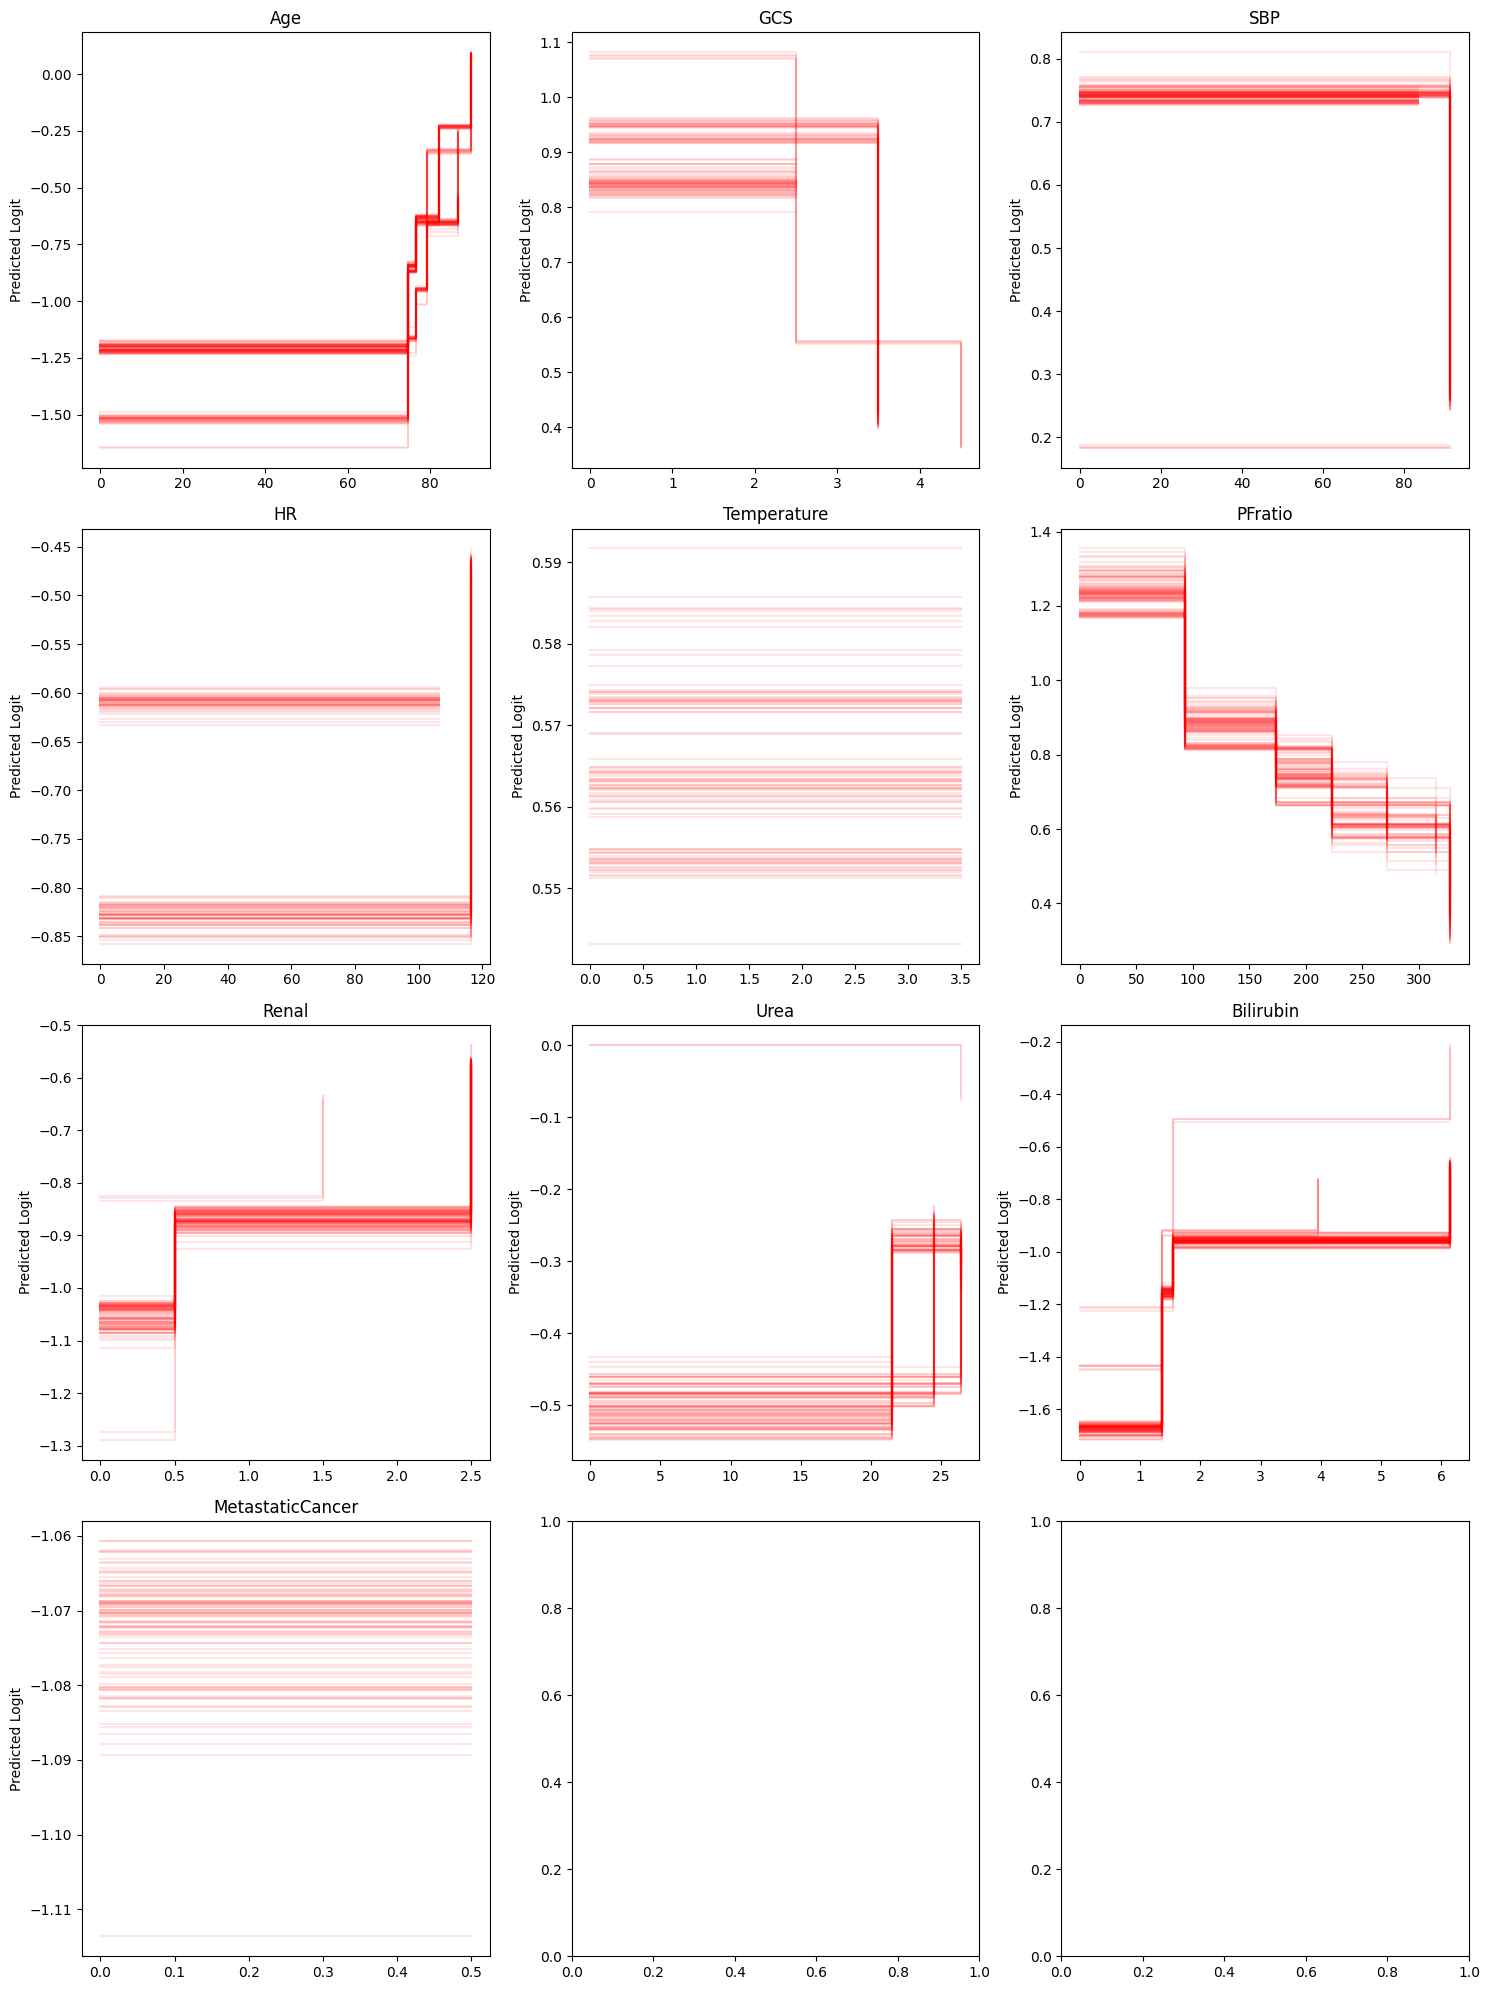

method: swapping_5


100%|██████████| 100/100 [00:00<00:00, 9584.13it/s]


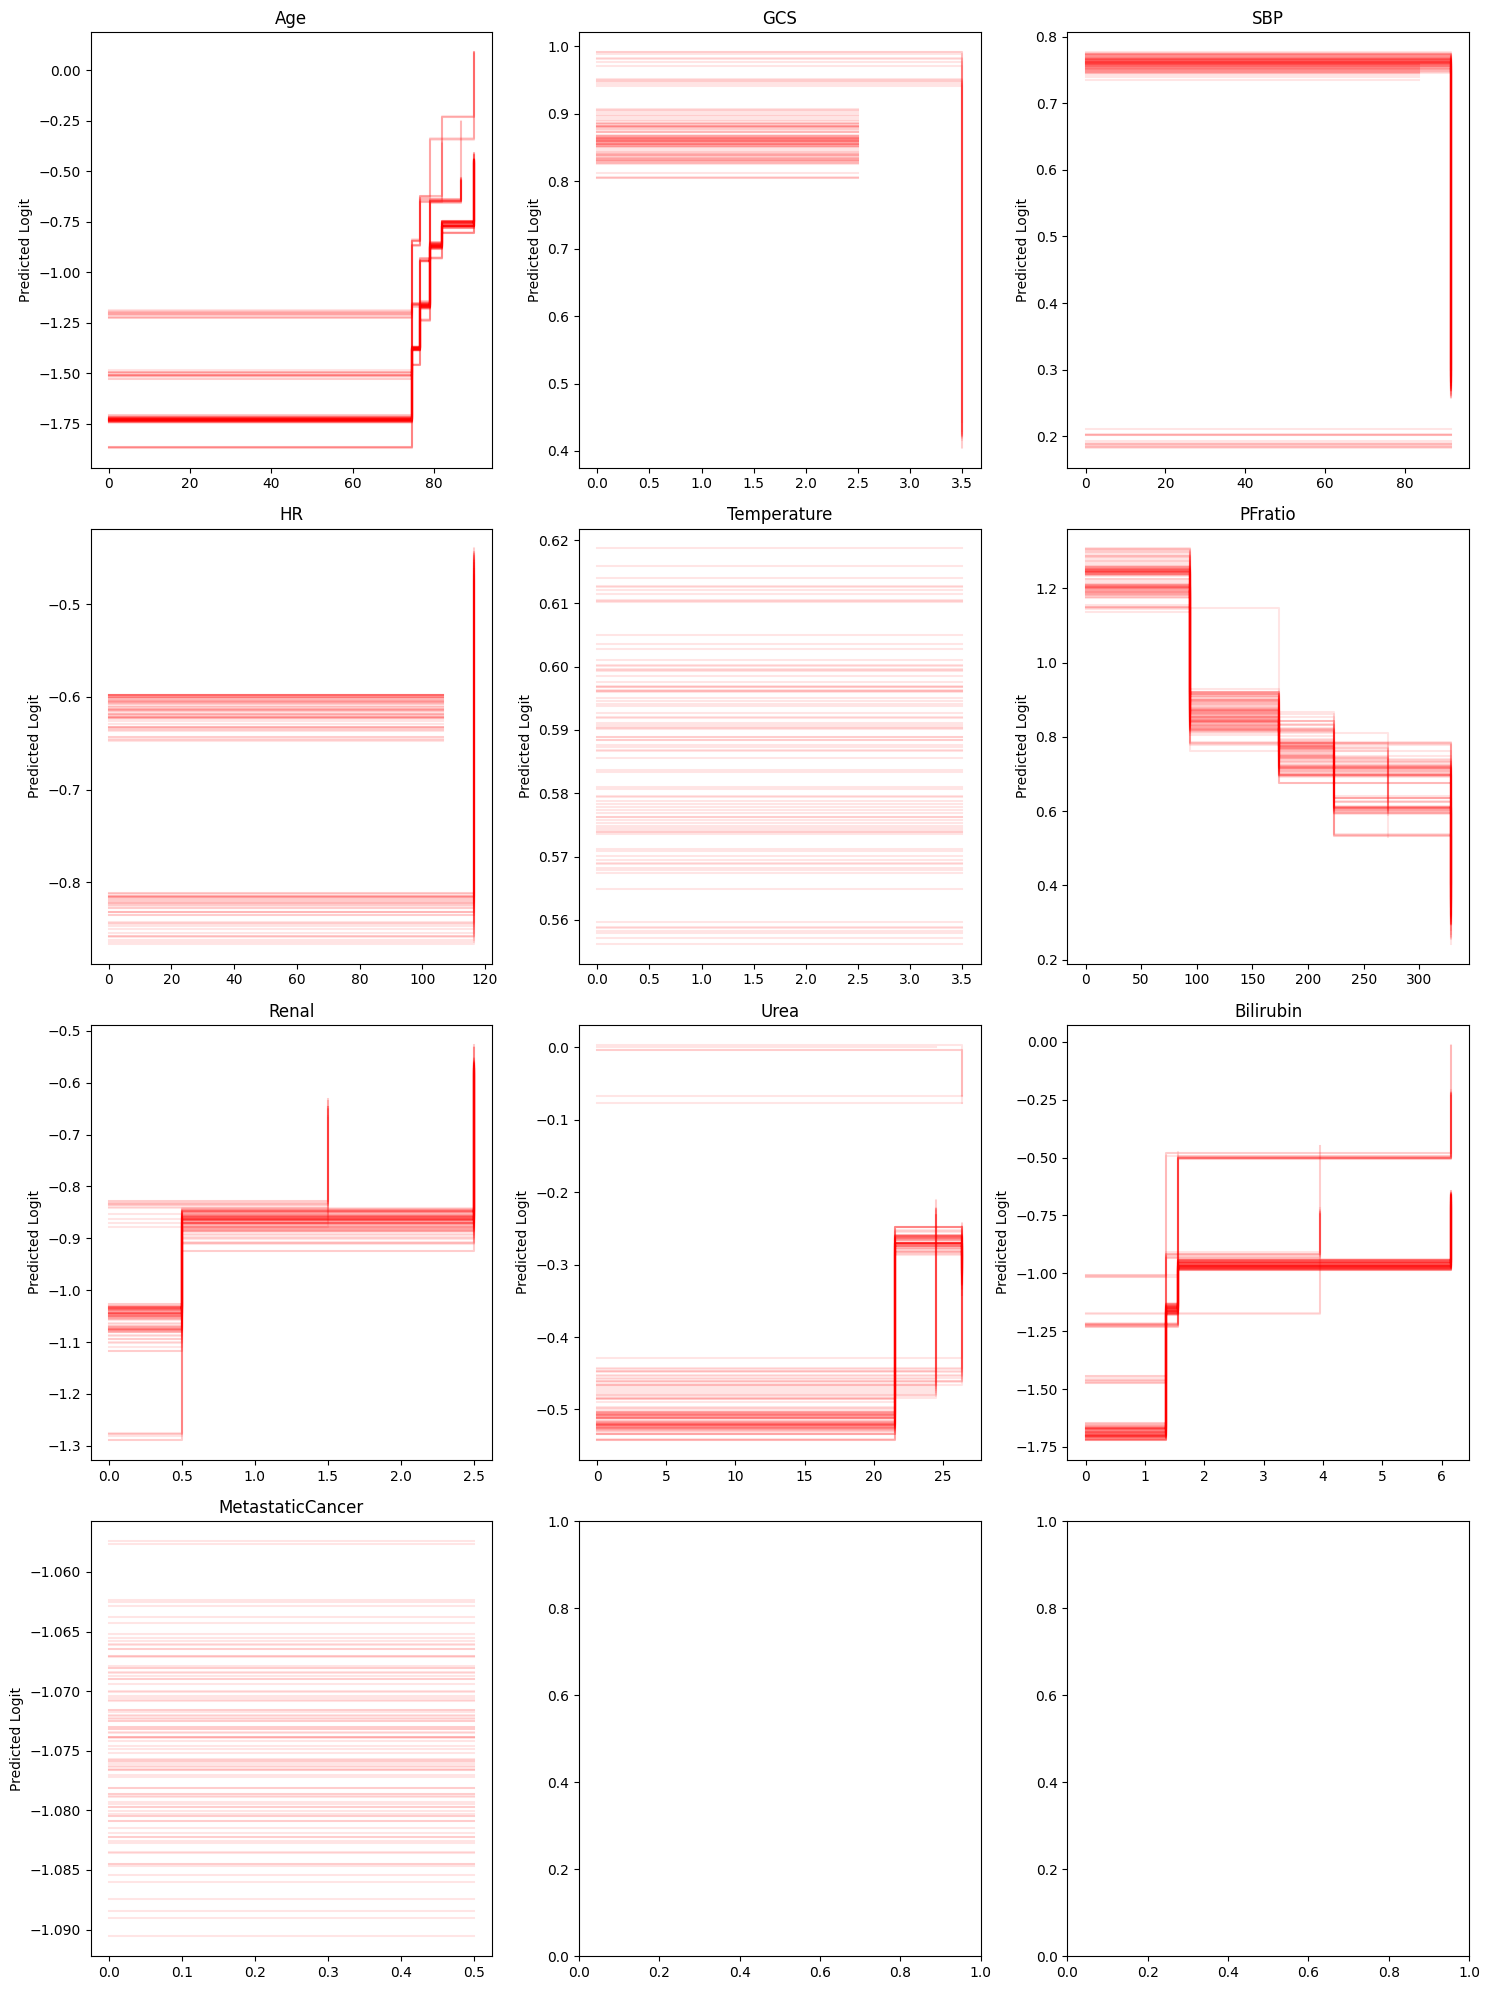

method: hybrid


100%|██████████| 100/100 [00:00<00:00, 10787.54it/s]


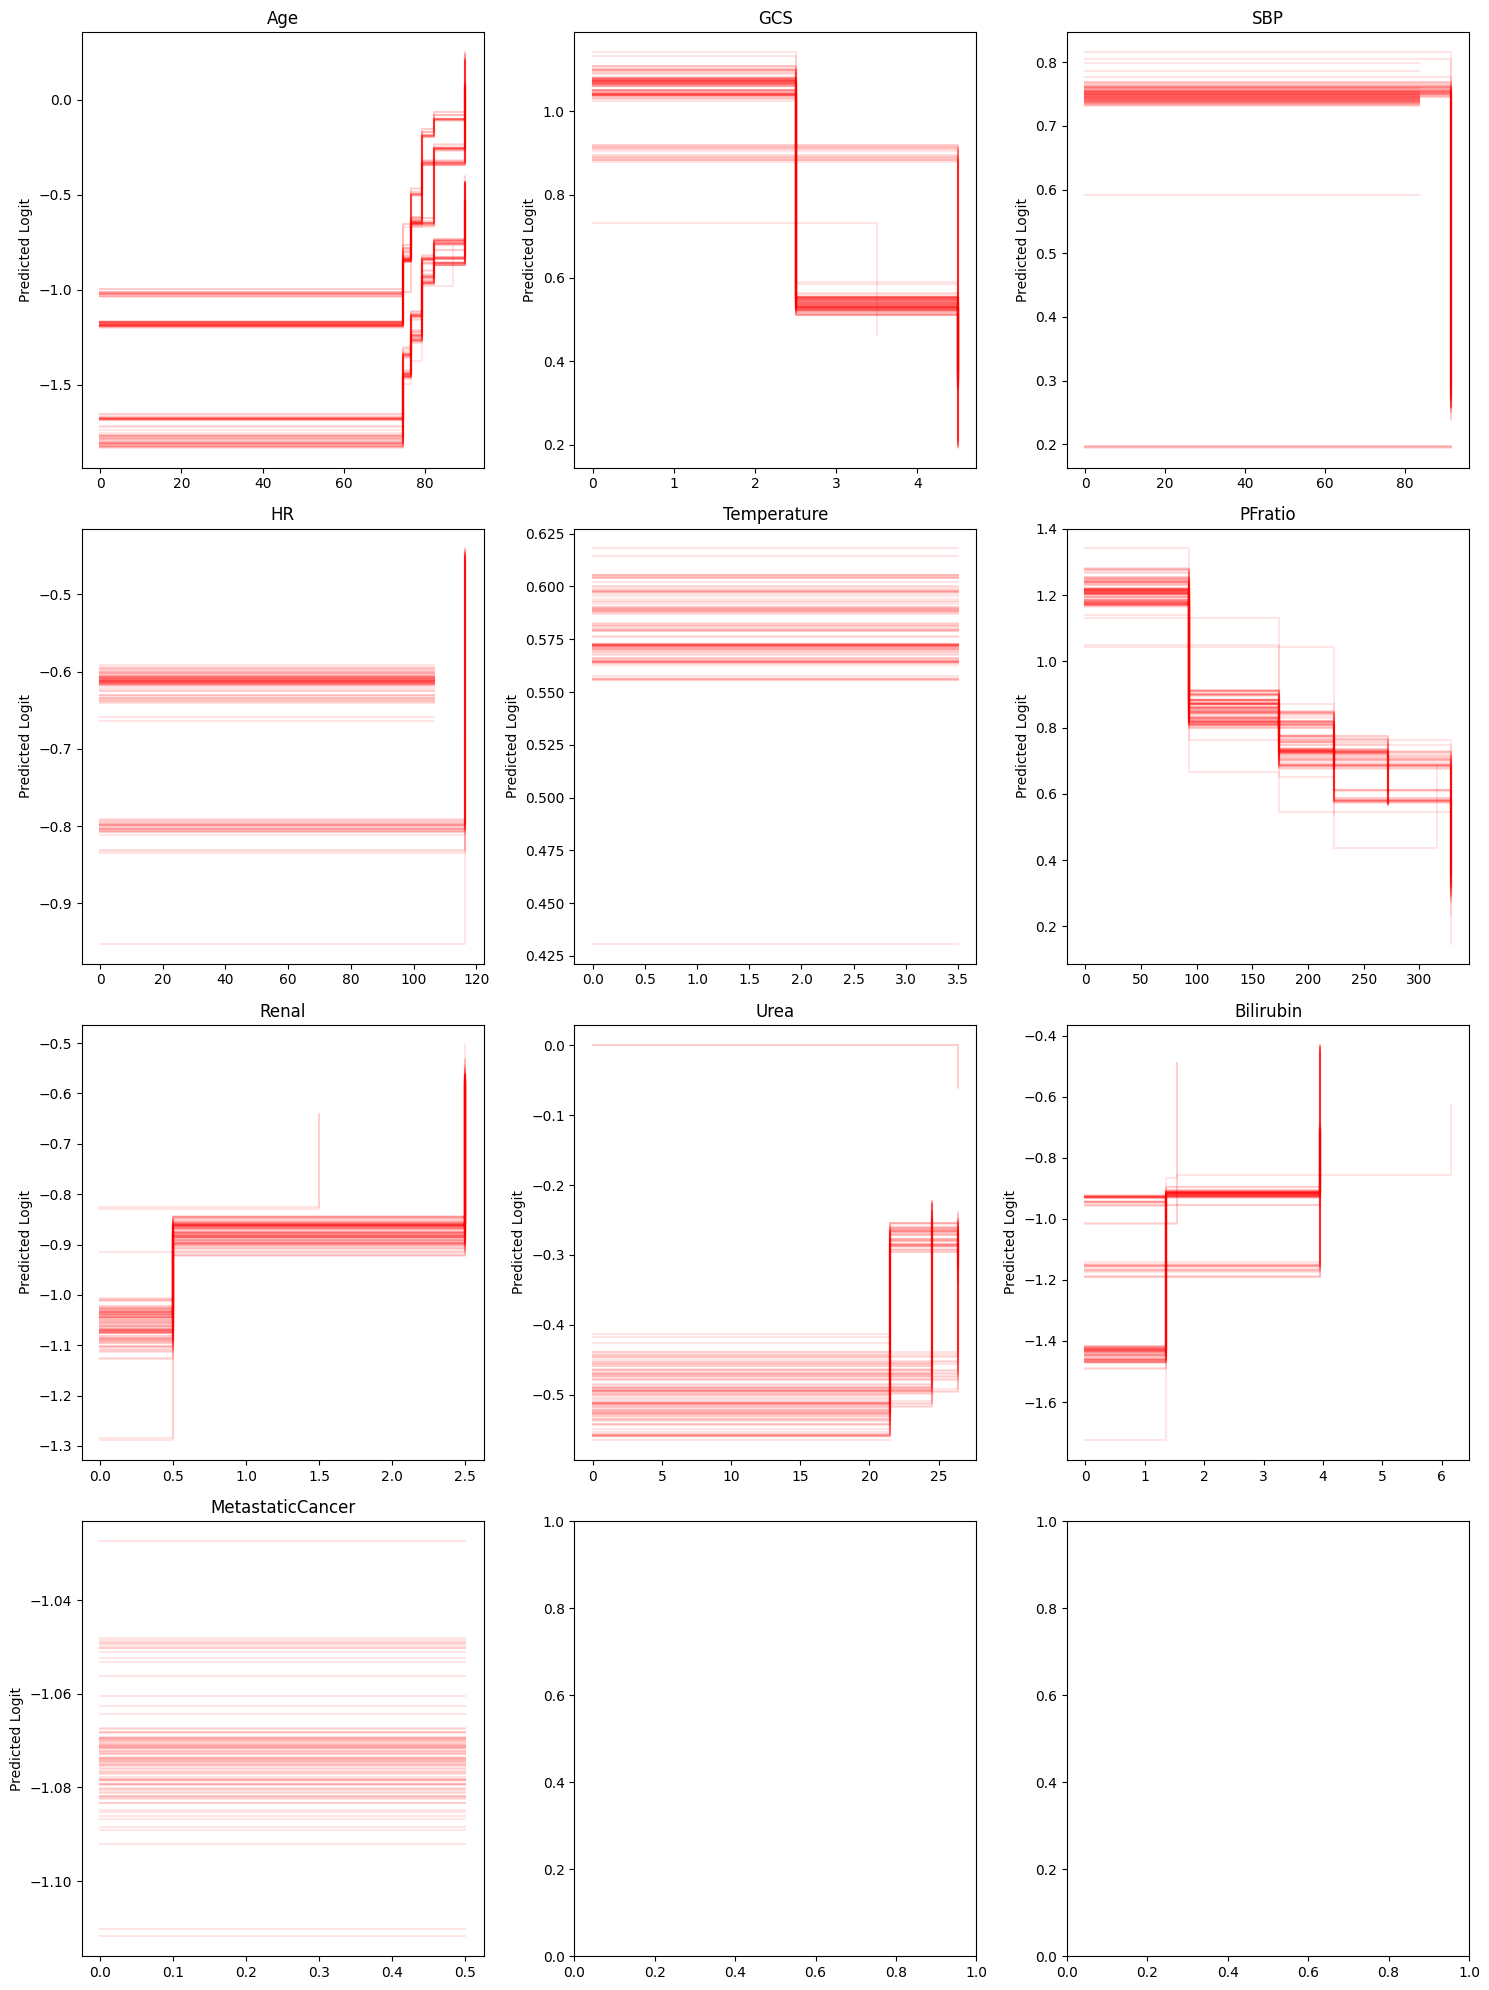

In [50]:
show_gam(all_datasets_results, 'mimic2')

method: uniform__ellipsoid_sampling, model_count: 16


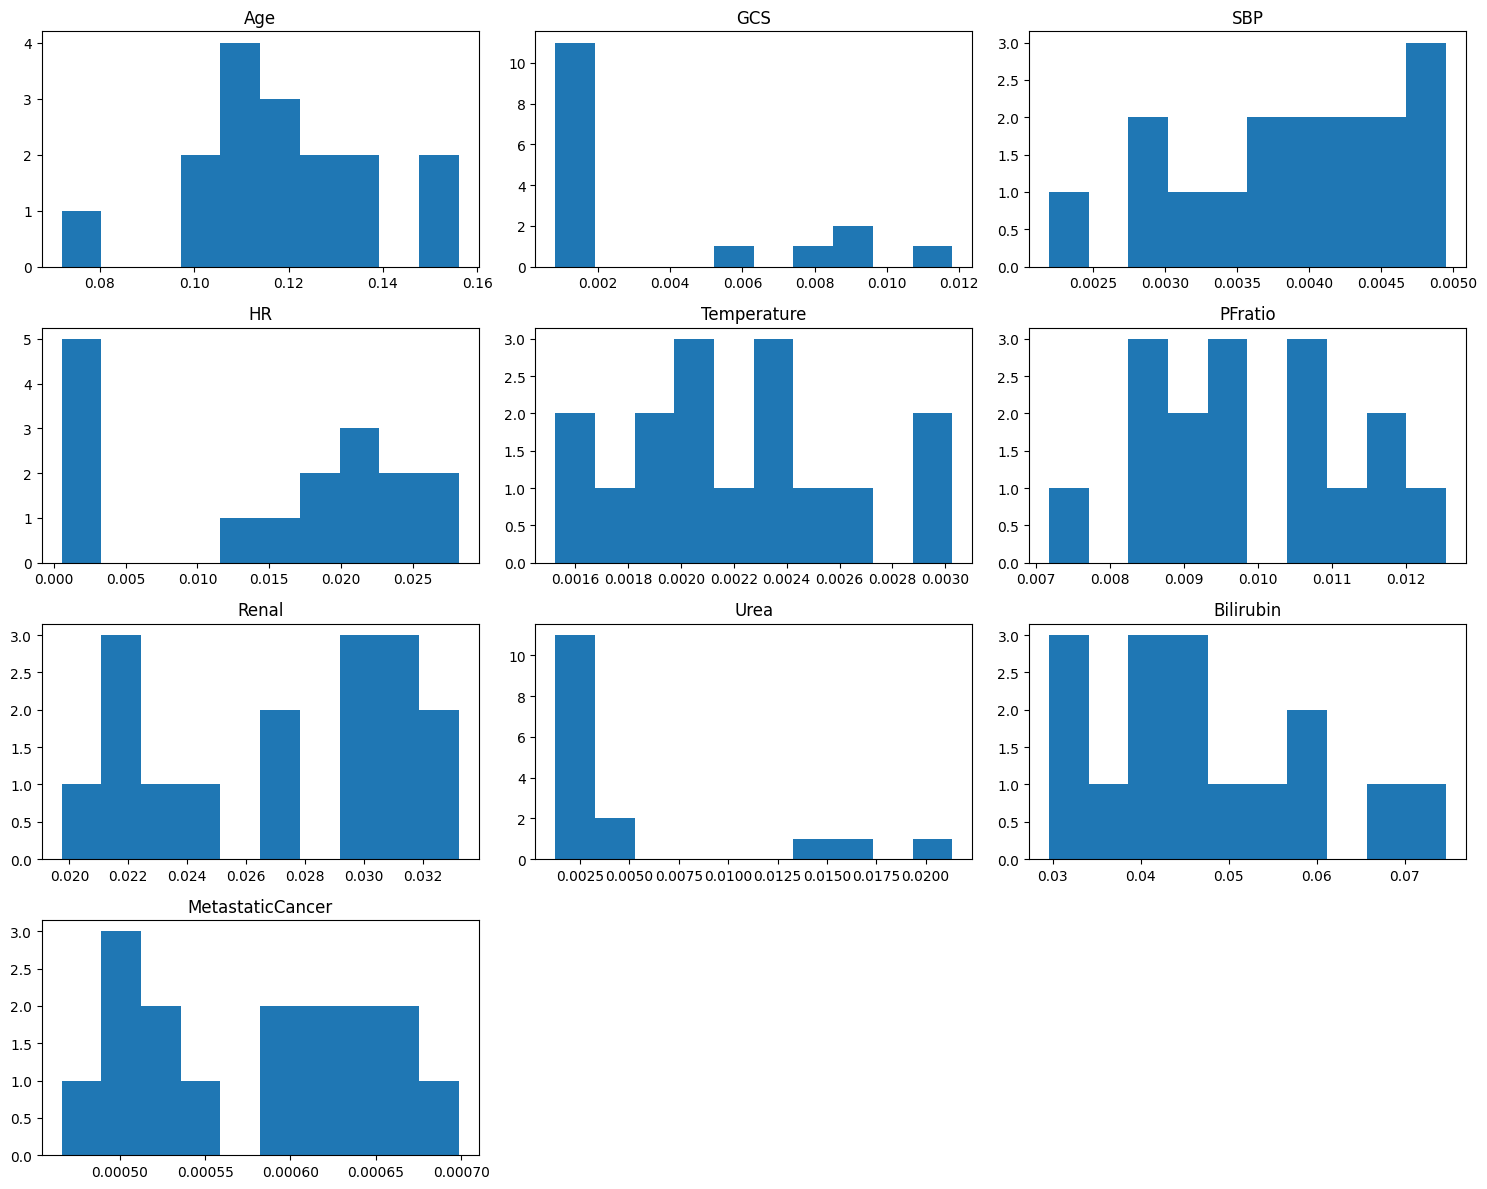

method: uniform_surface_ellipsoid_sampling, model_count: 14


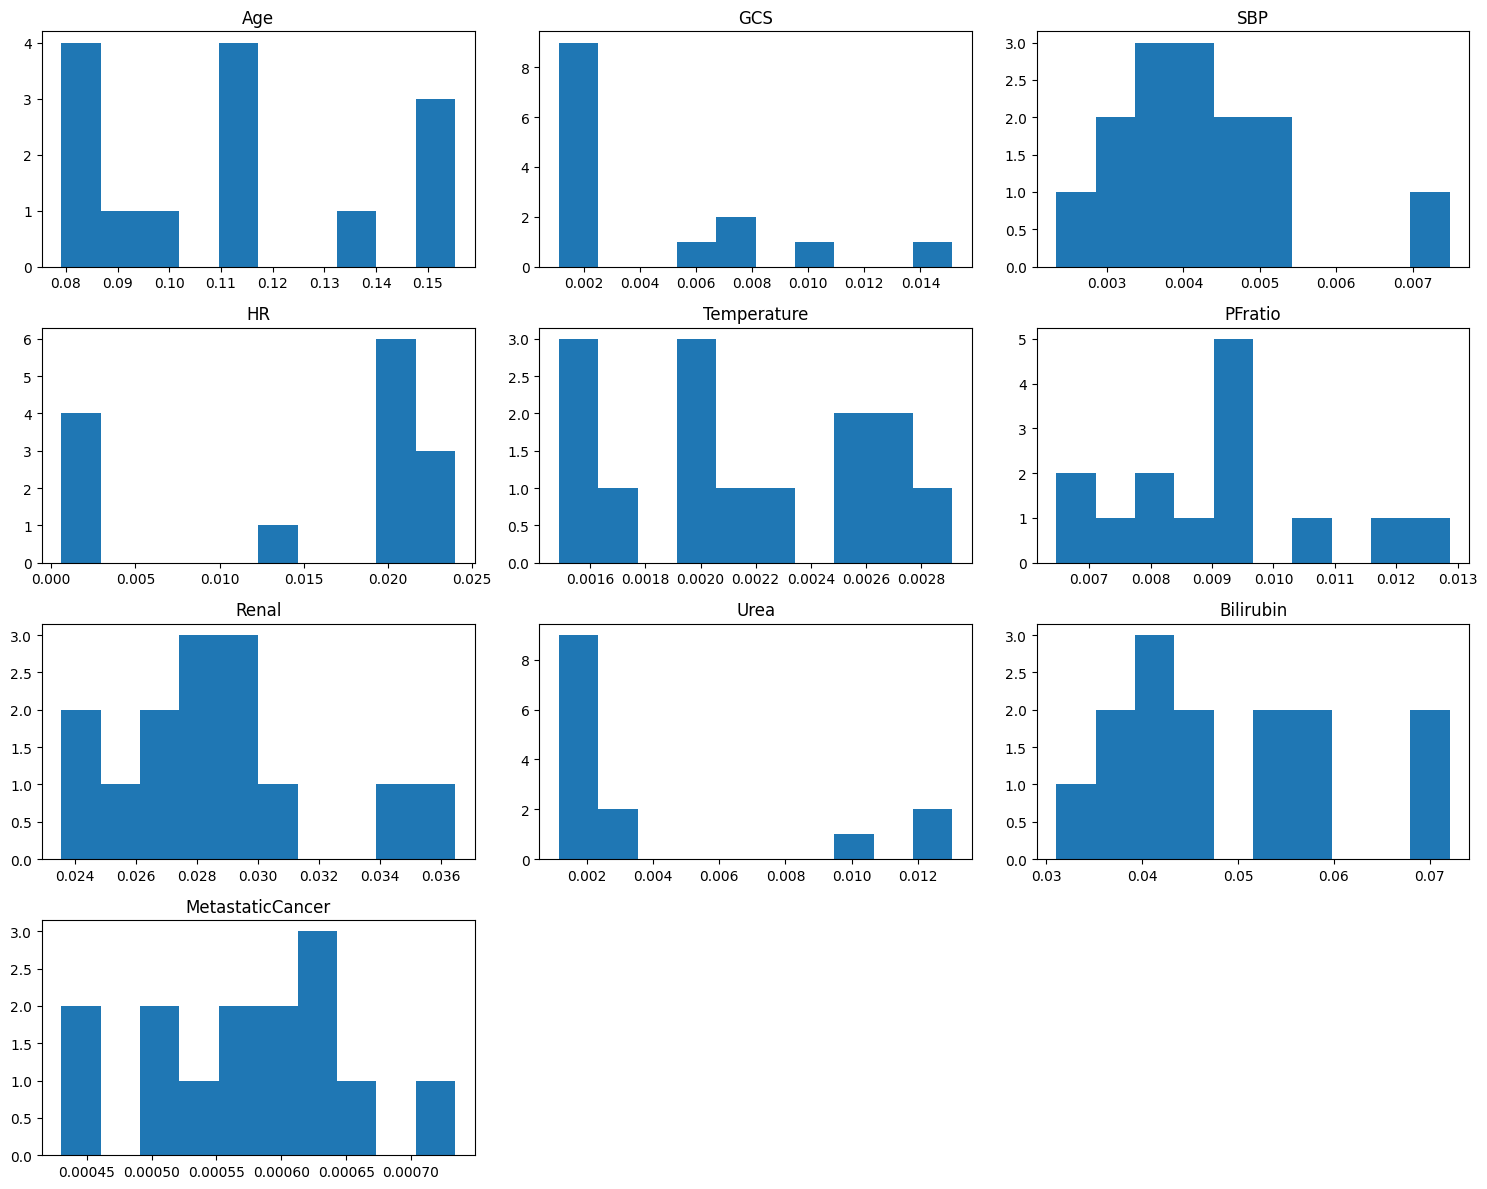

method: poisson__ellipsoid_sampling, model_count: 6


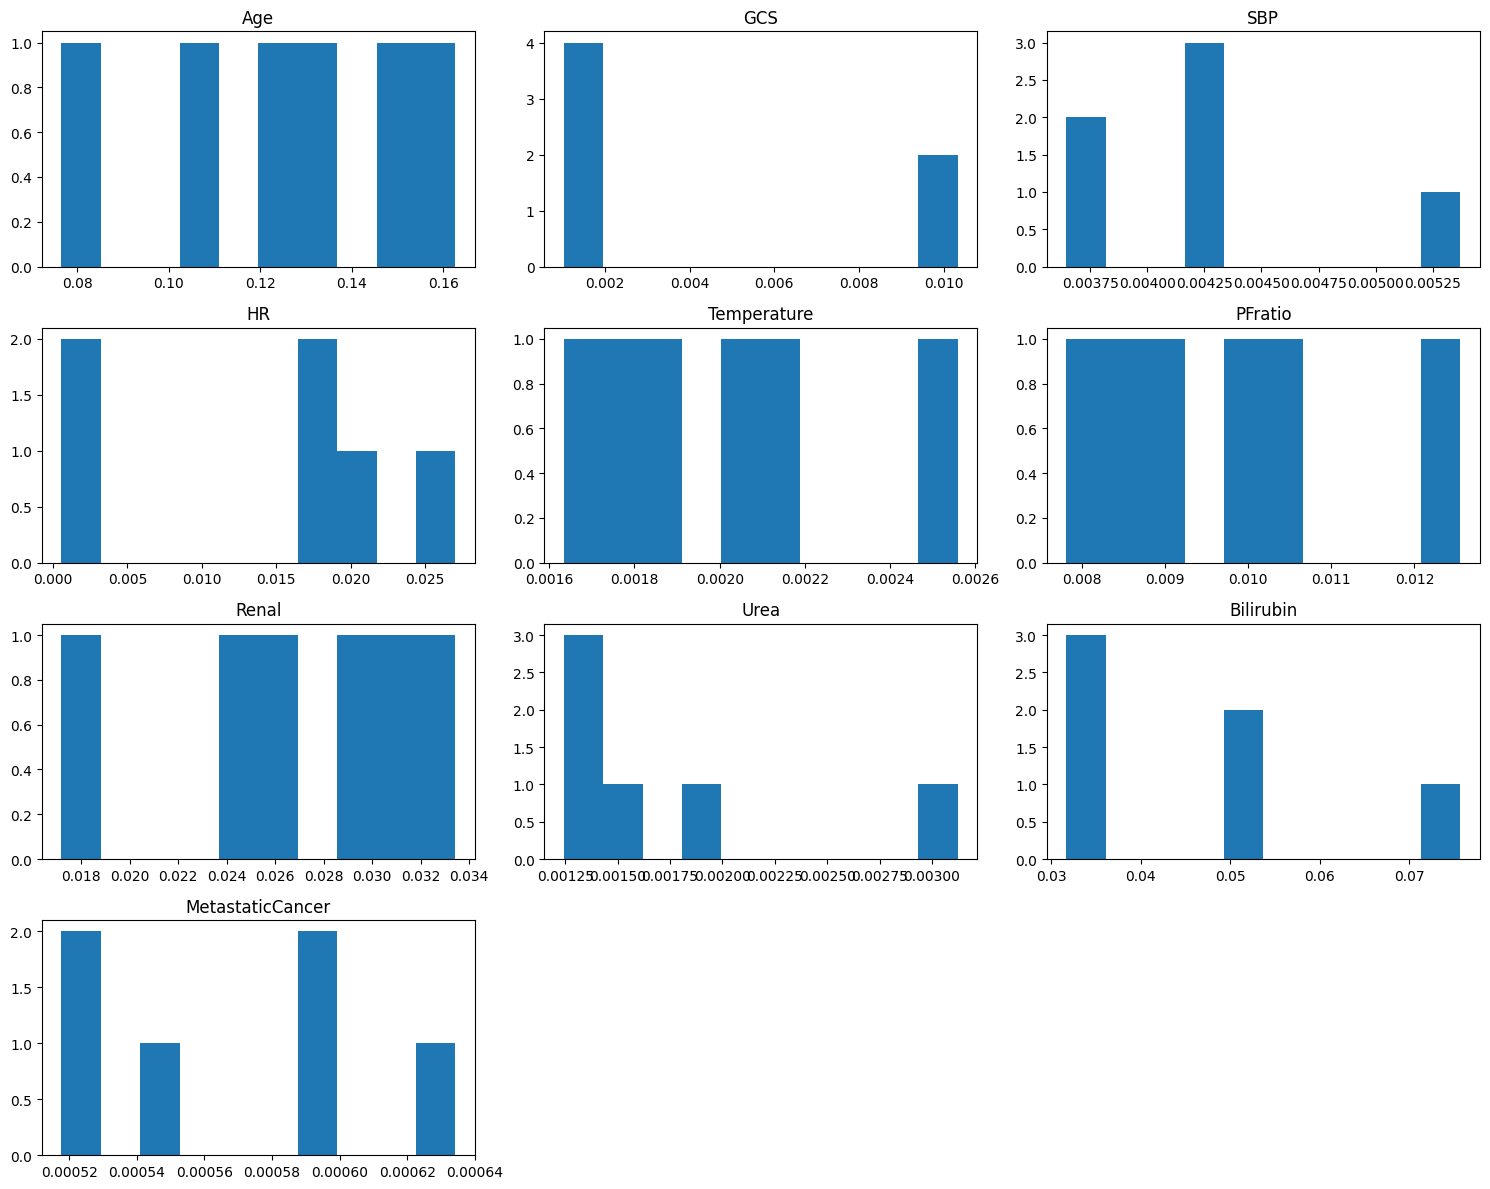

method: poisson_euclidean_ellipsoid_sampling, model_count: 13


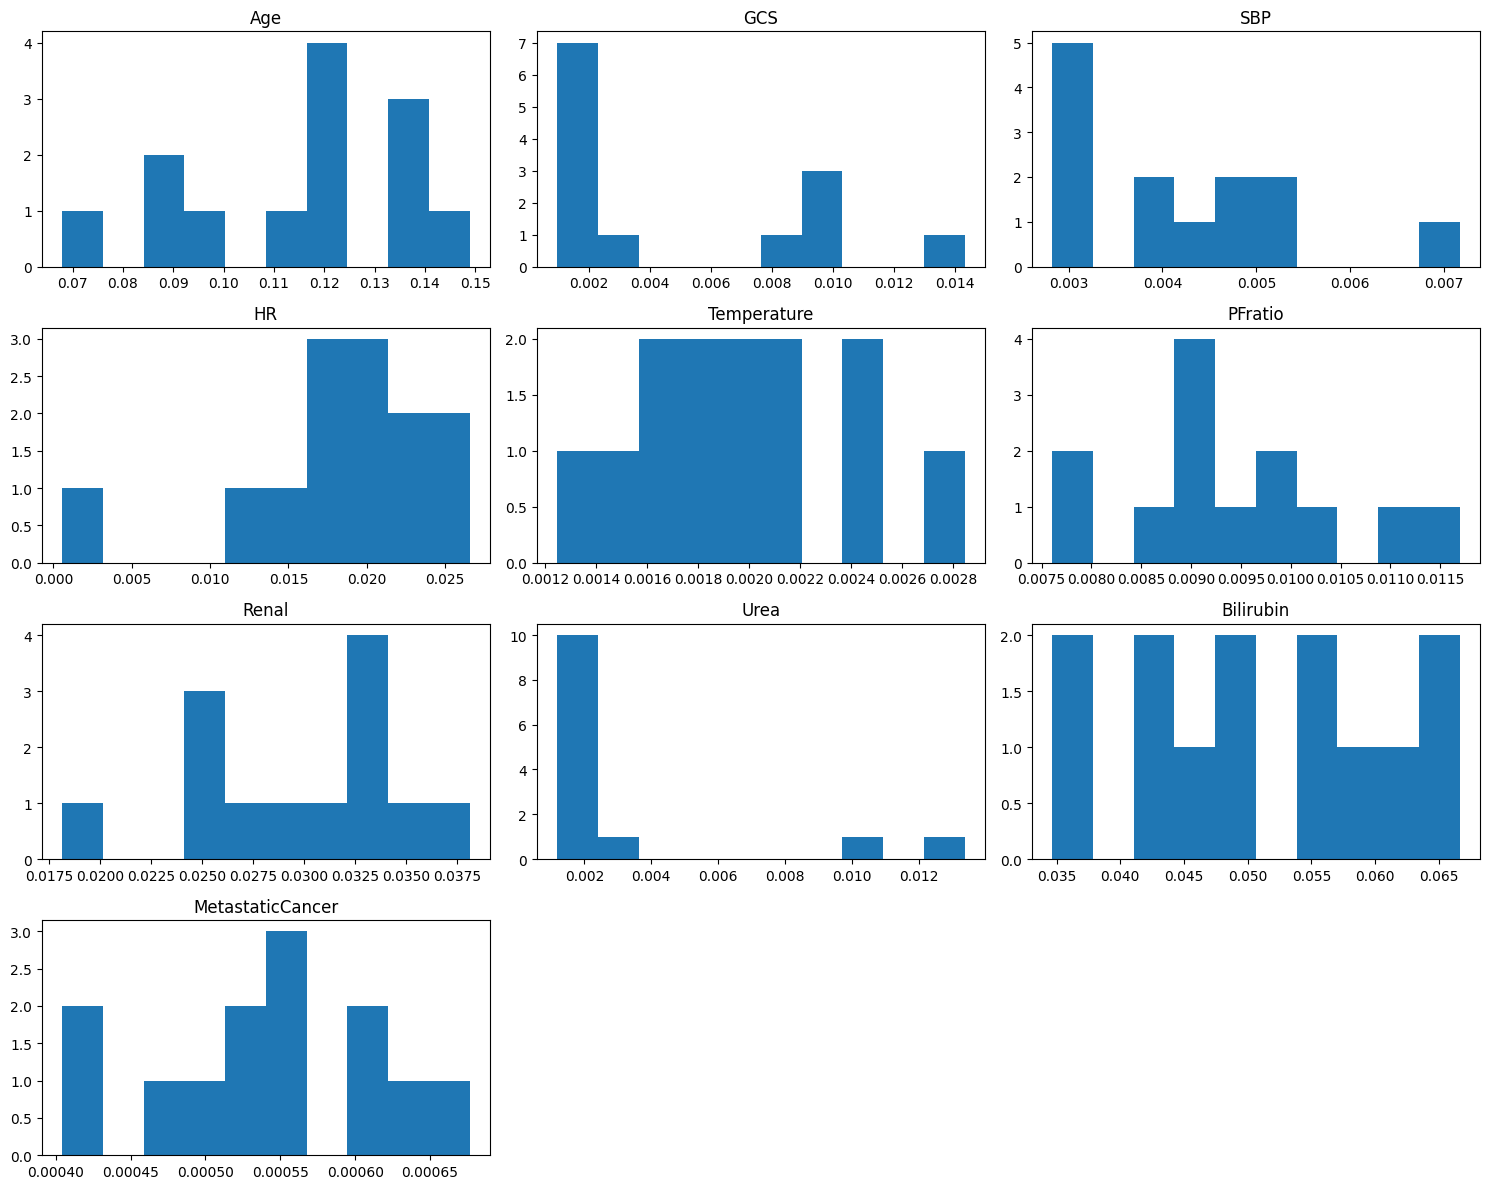

method: permutation__ellipsoid_sampling, model_count: 20


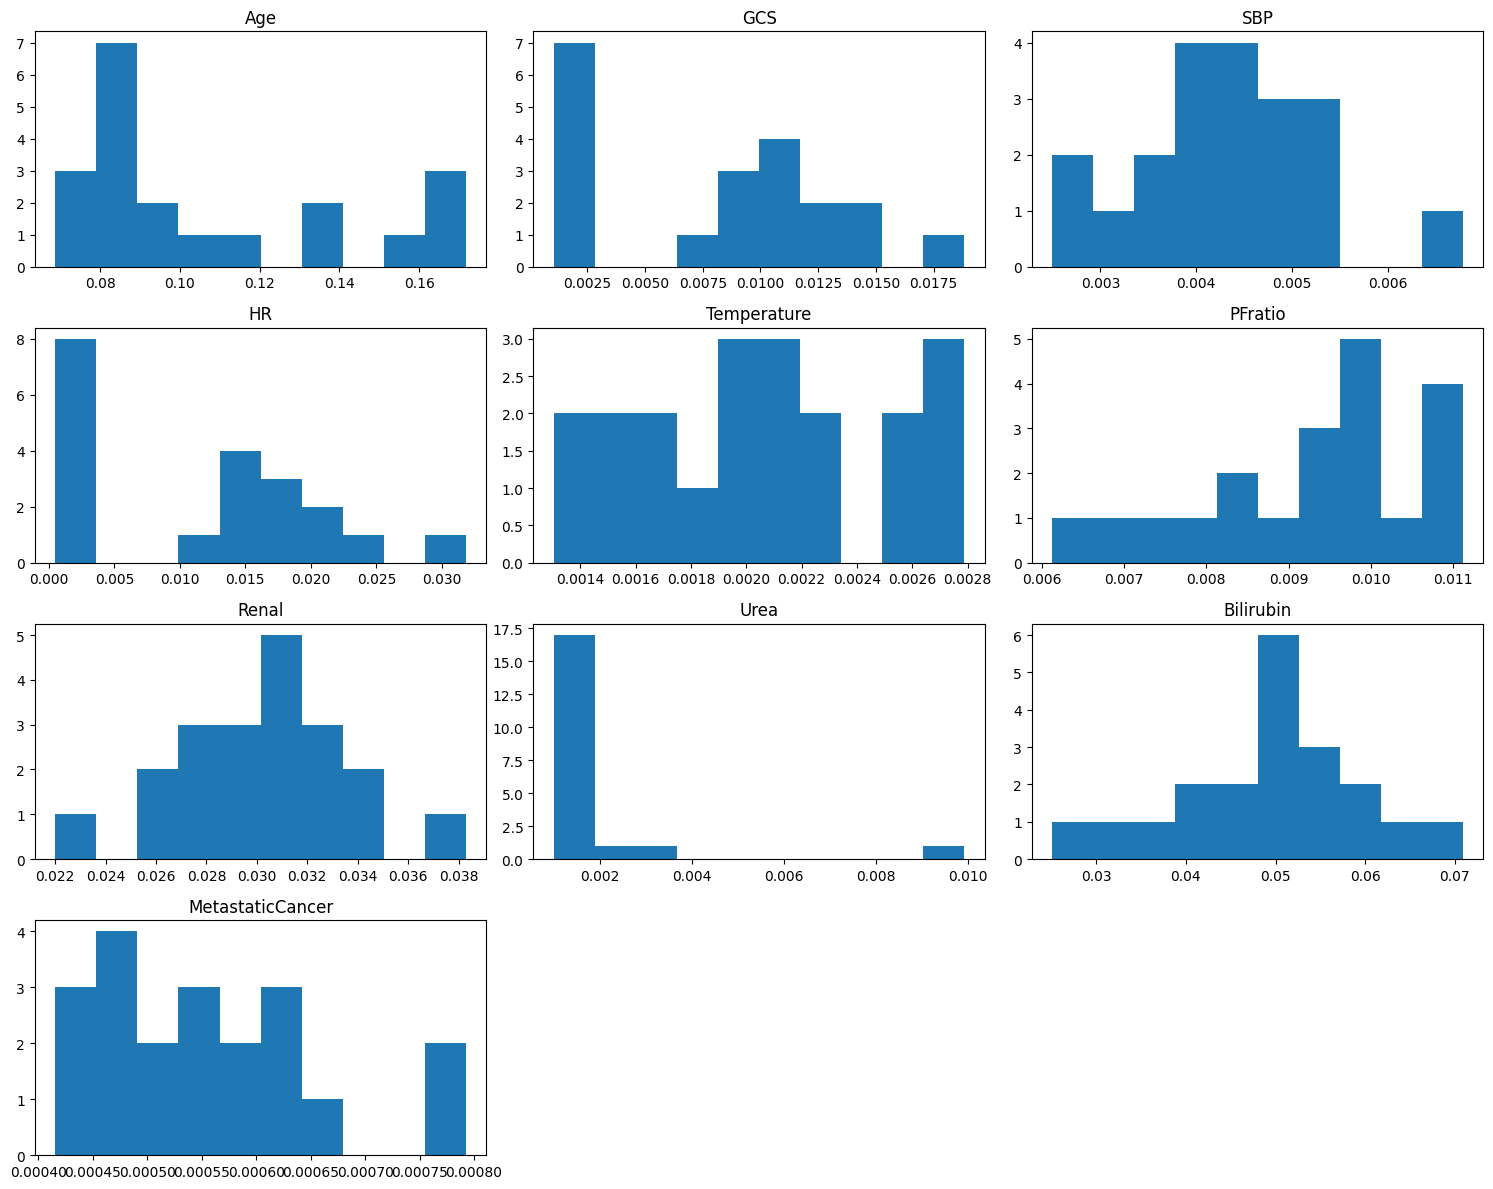

method: permutation_poisson_ellipsoid_sampling, model_count: 8


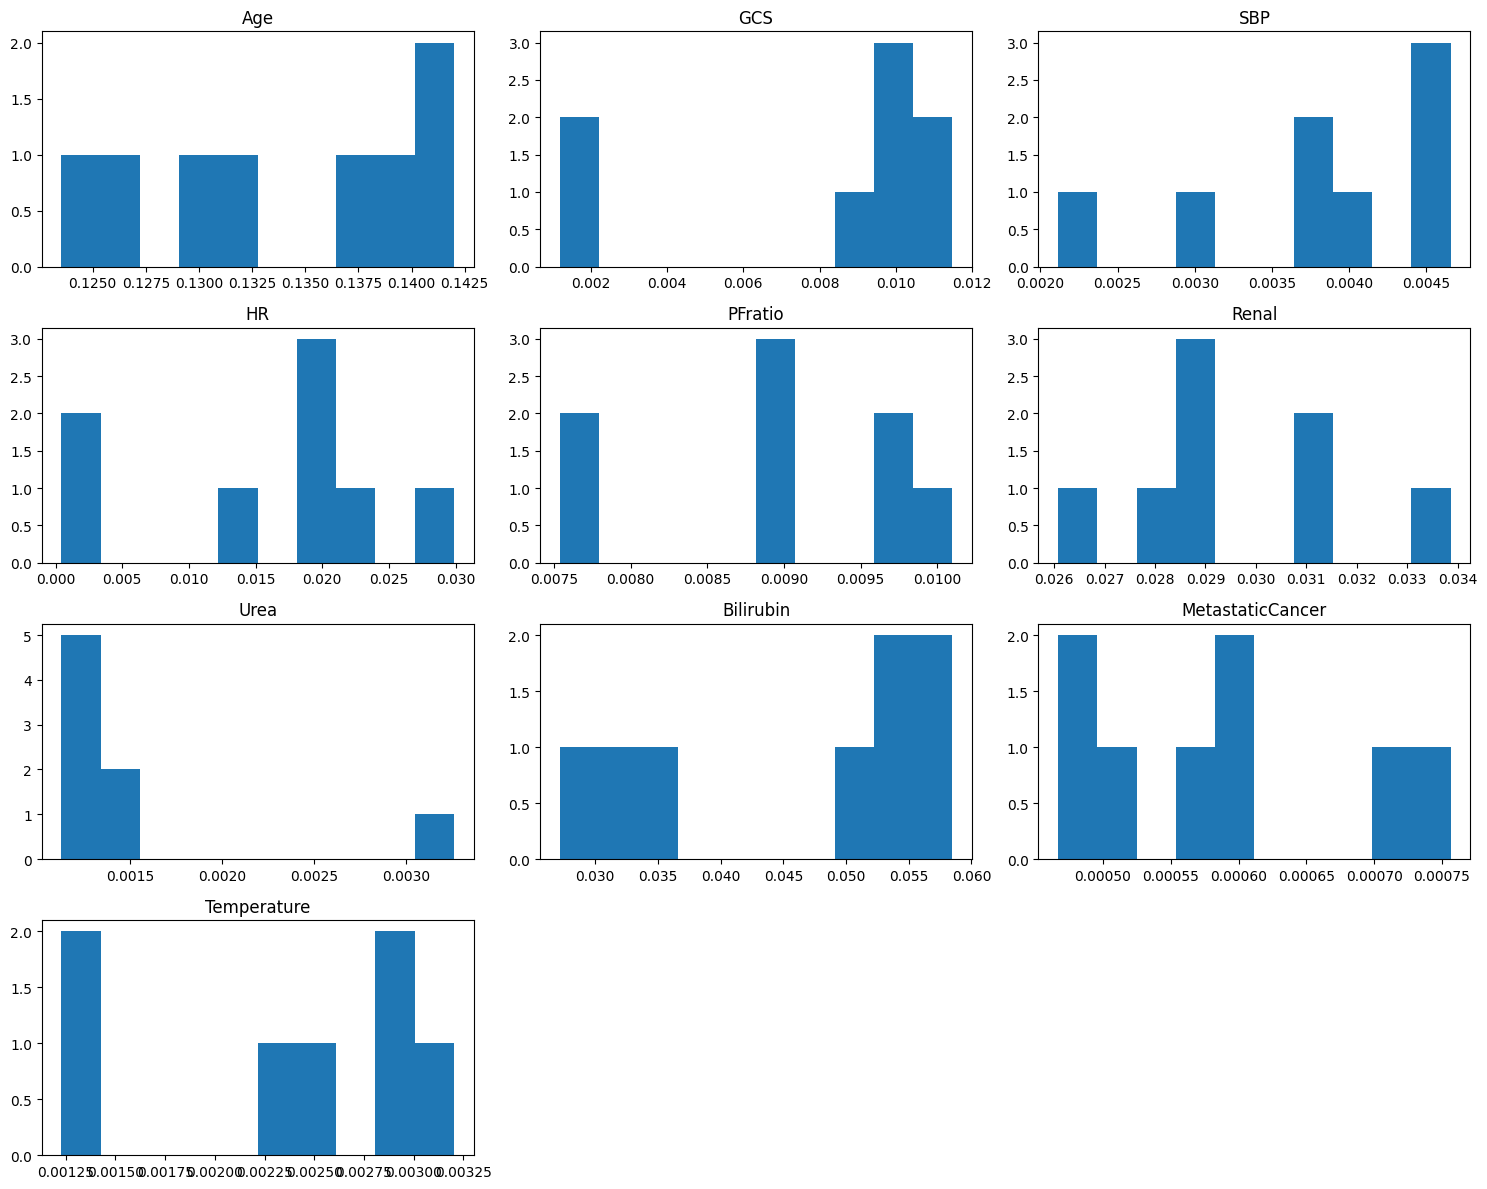

method: blocking, model_count: 100


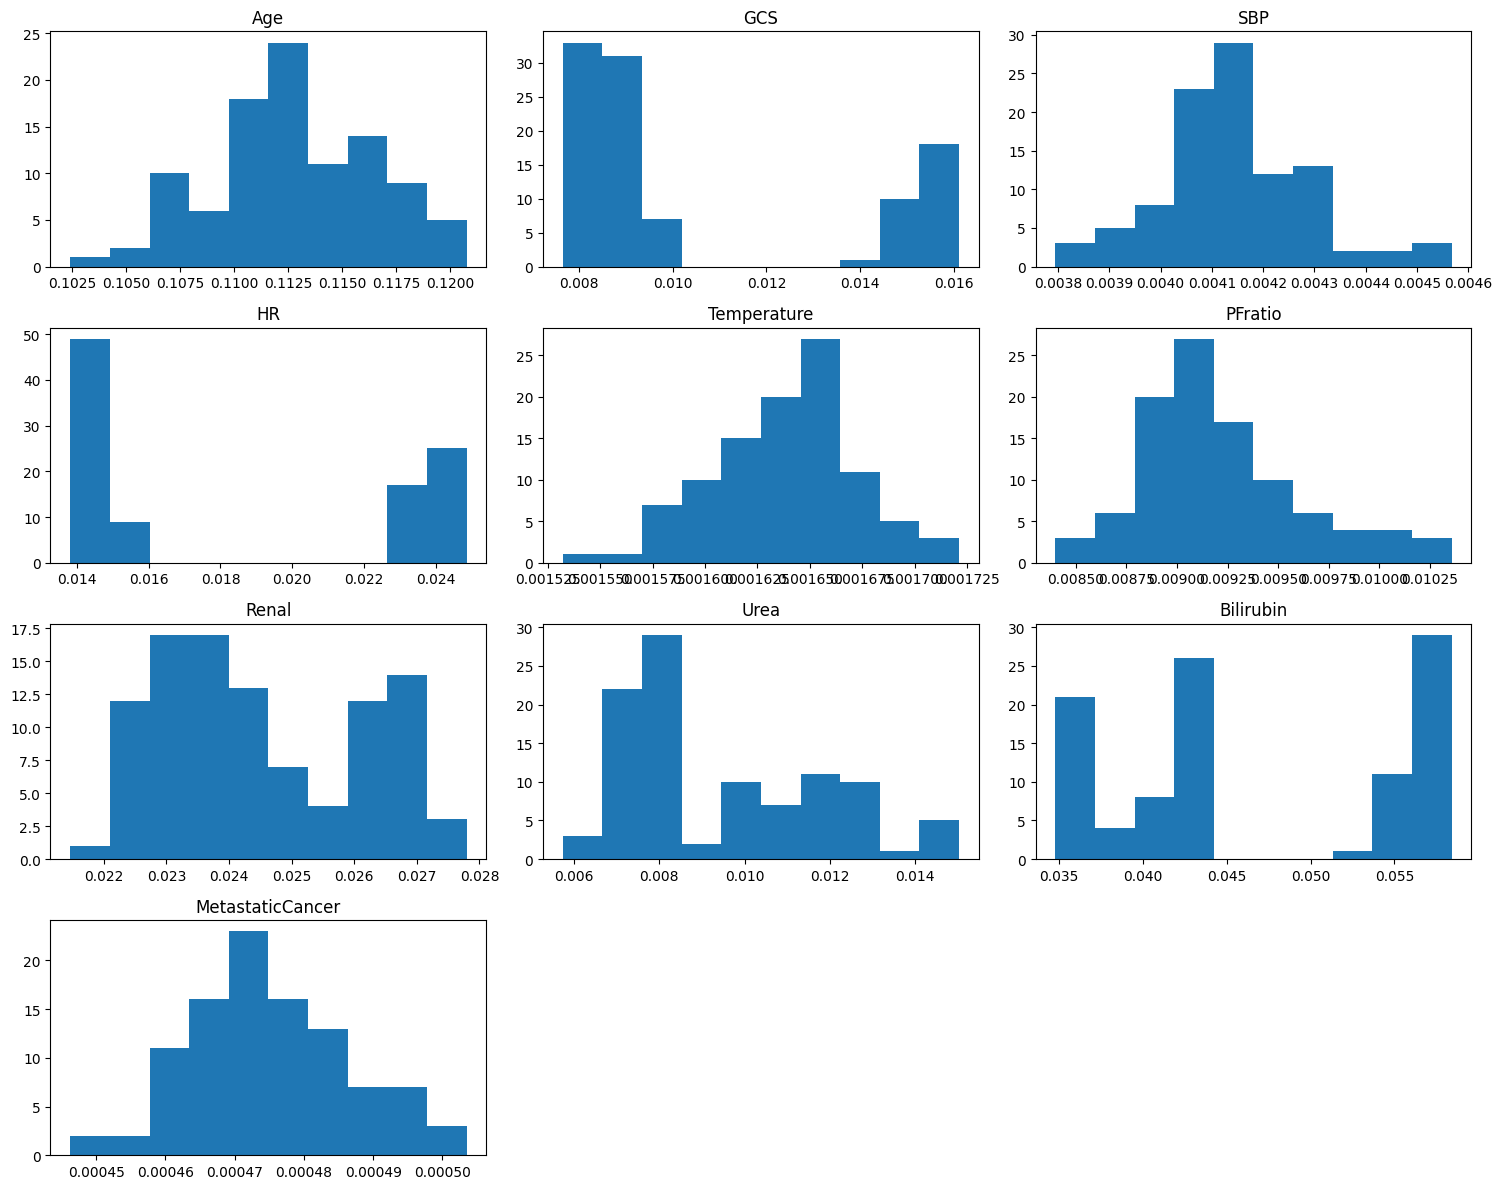

method: quadratic, model_count: 9917


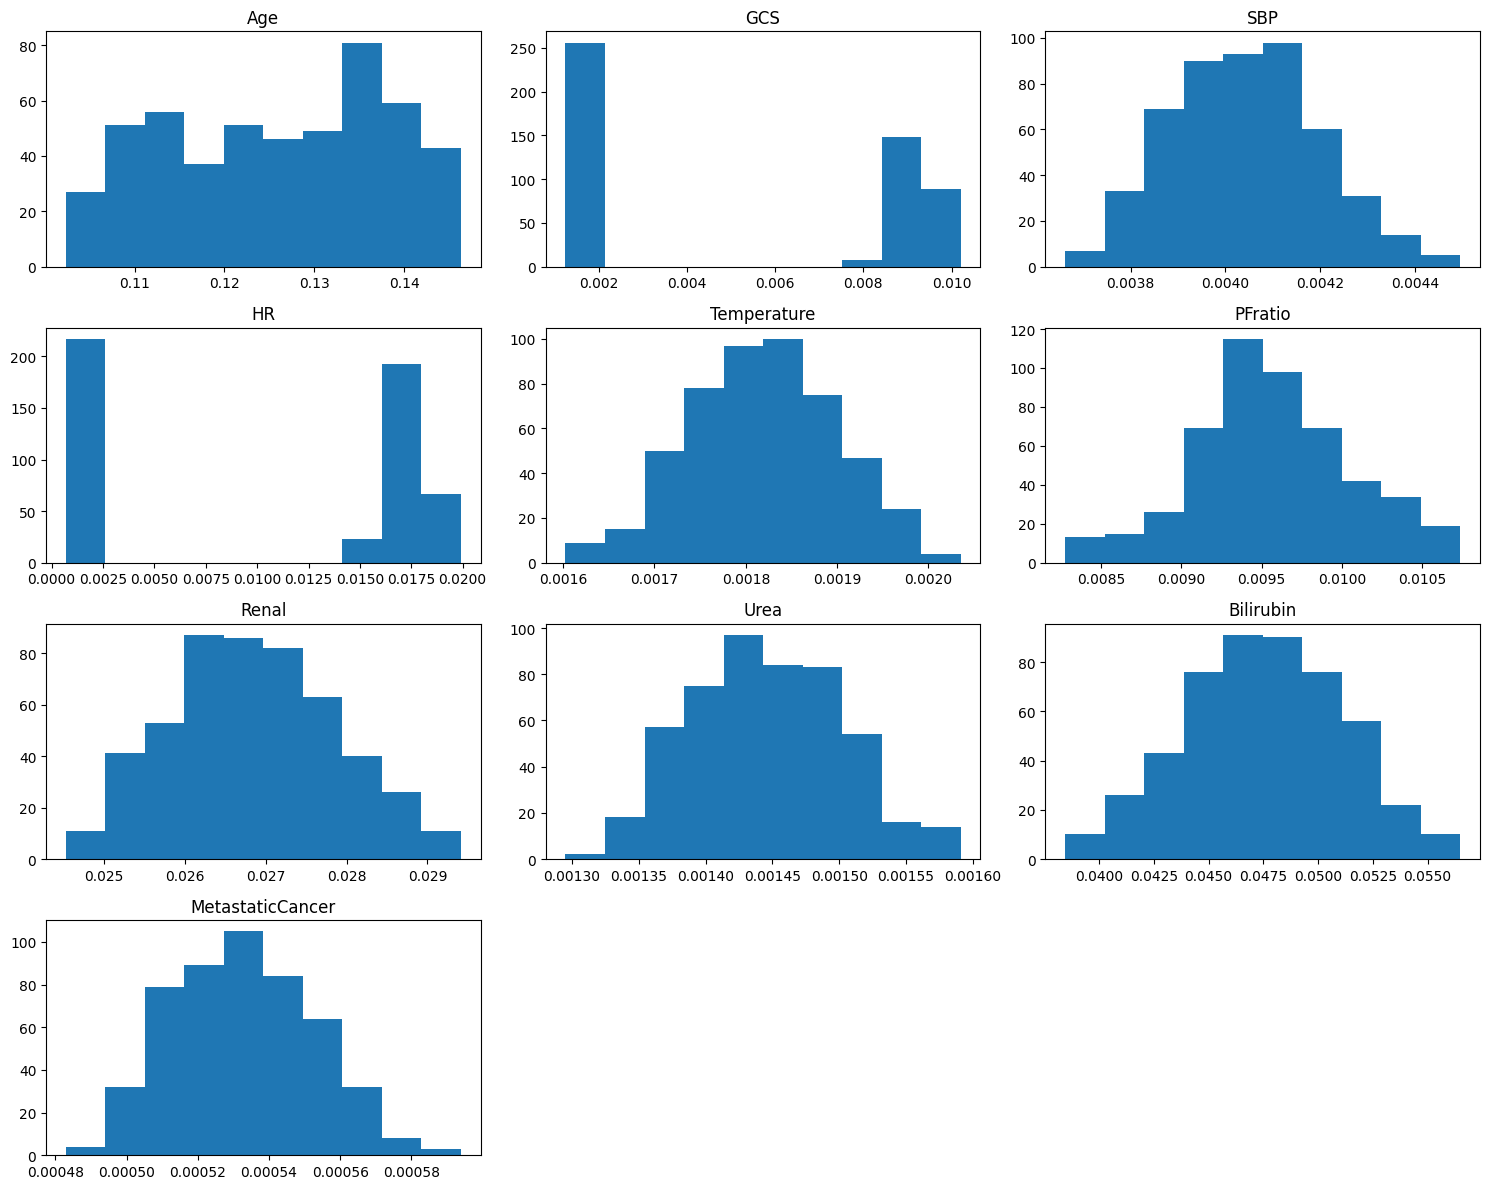

method: swapping_1, model_count: 119


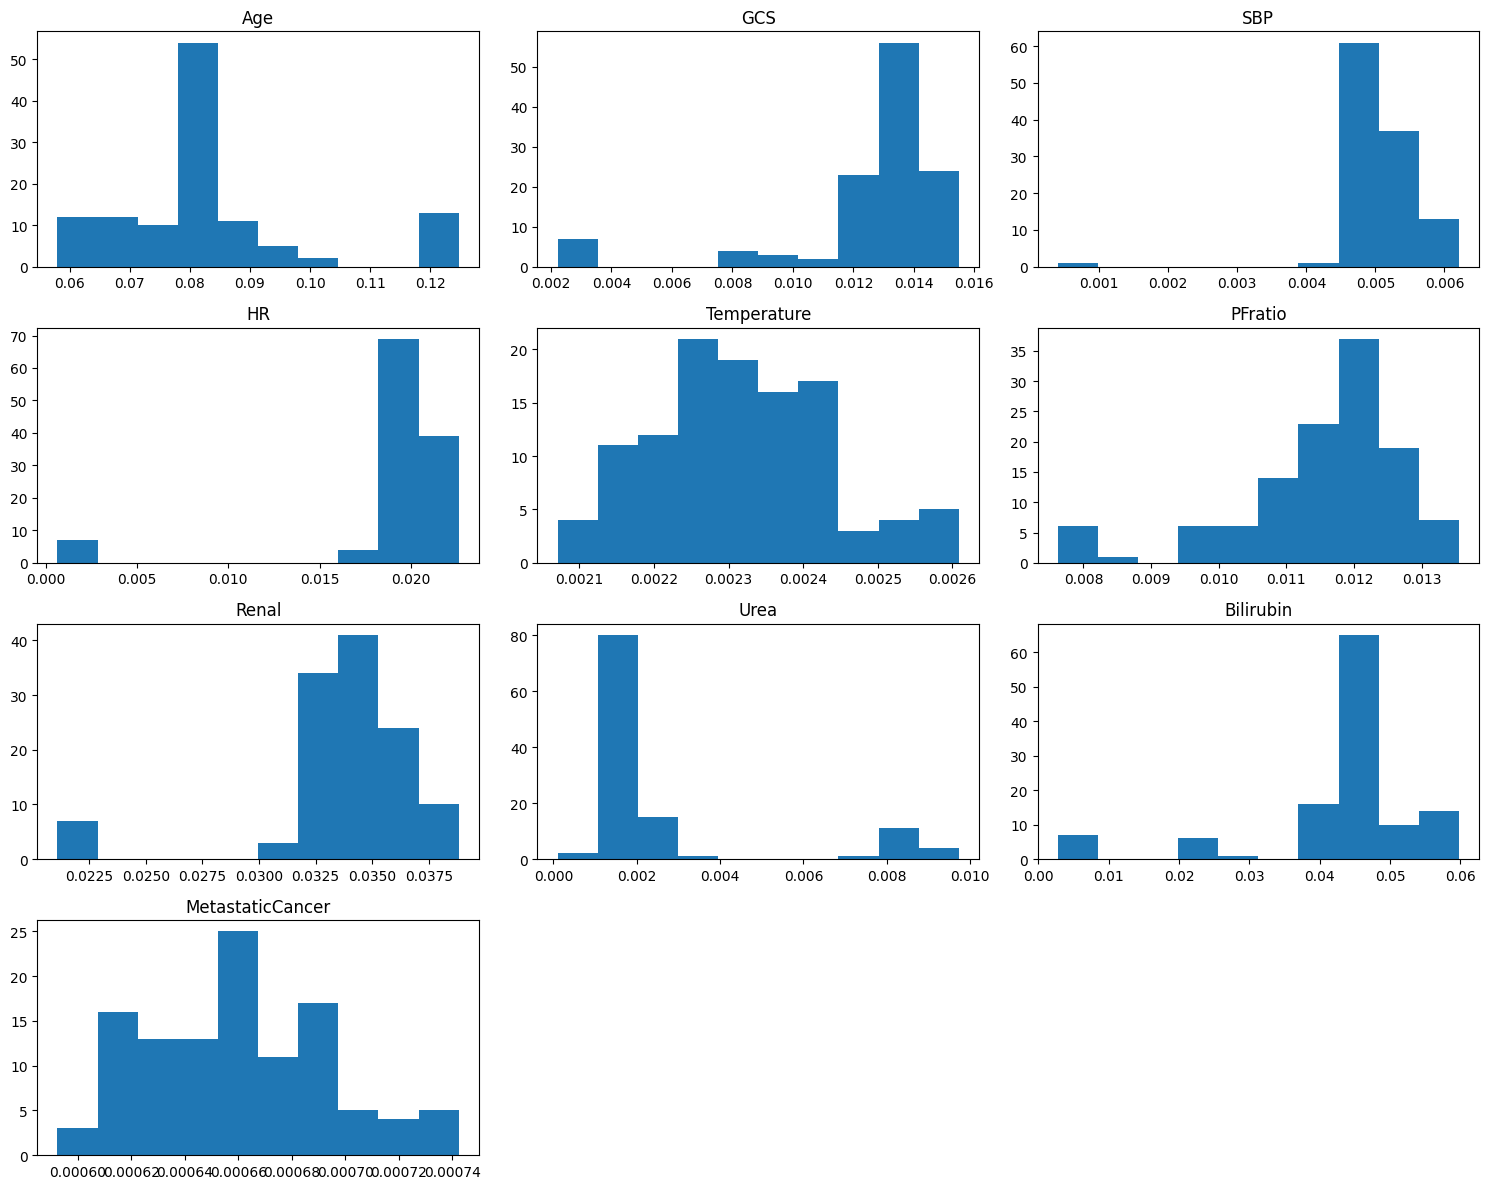

method: swapping_2, model_count: 2455


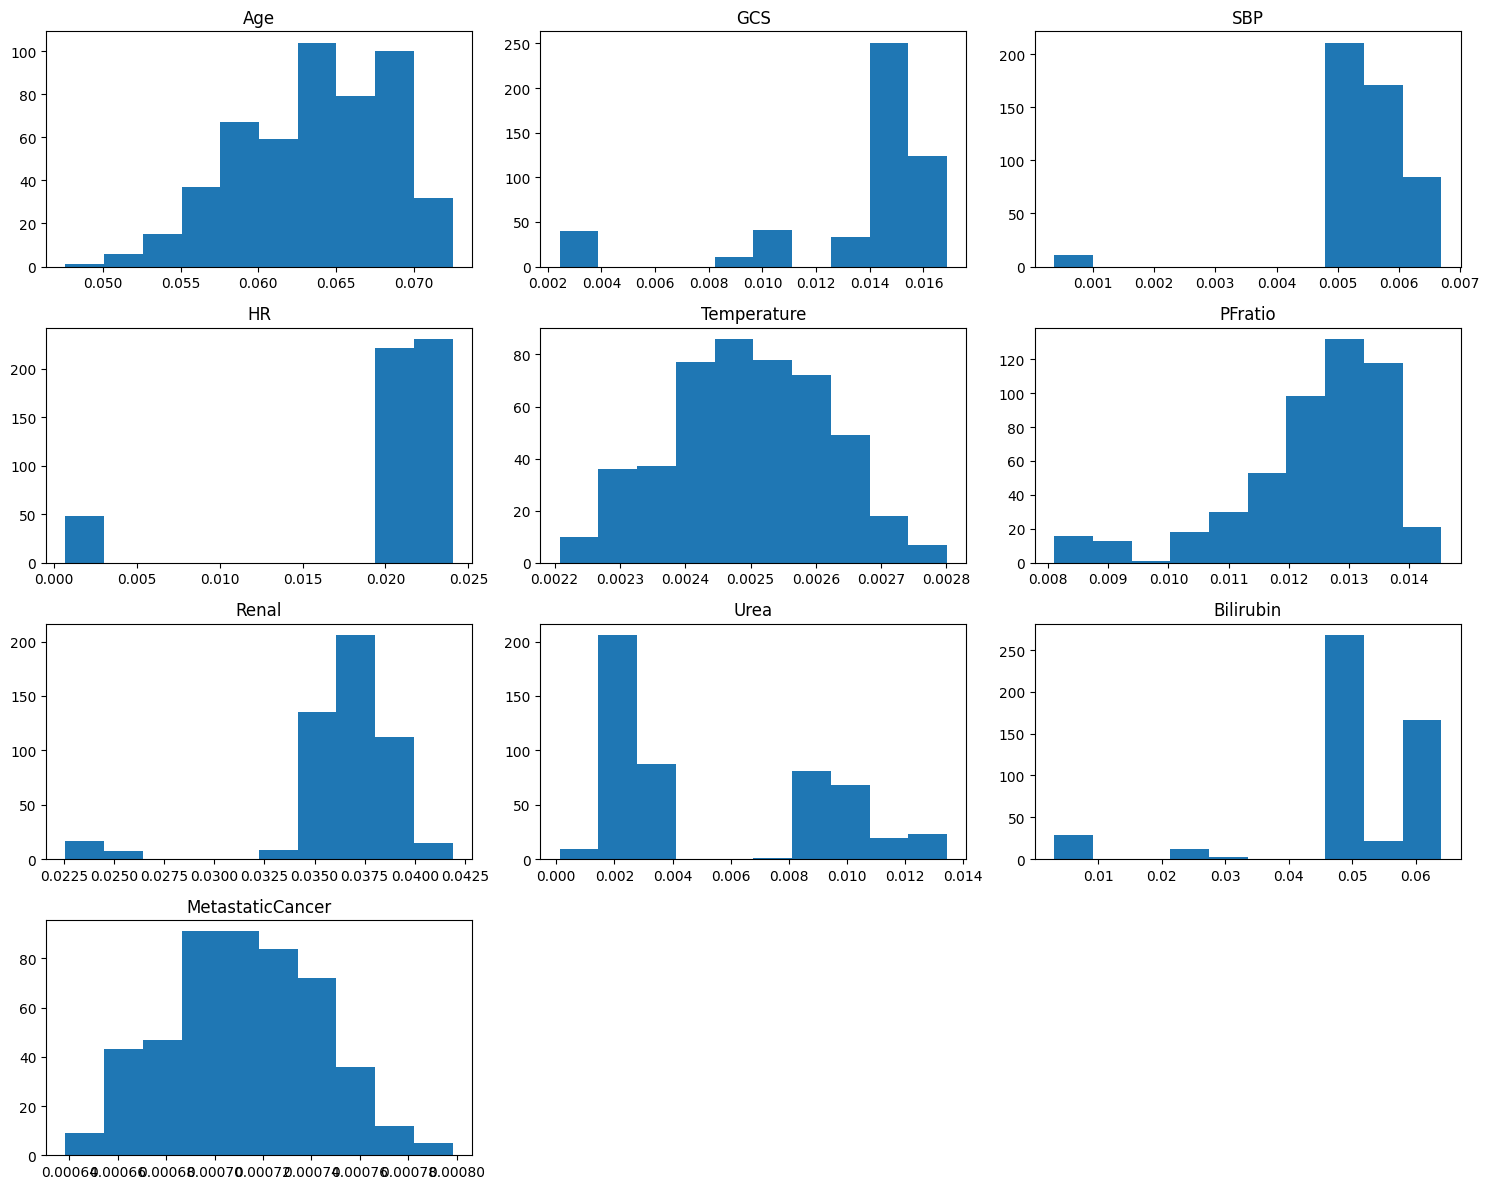

method: swapping_3, model_count: 2682


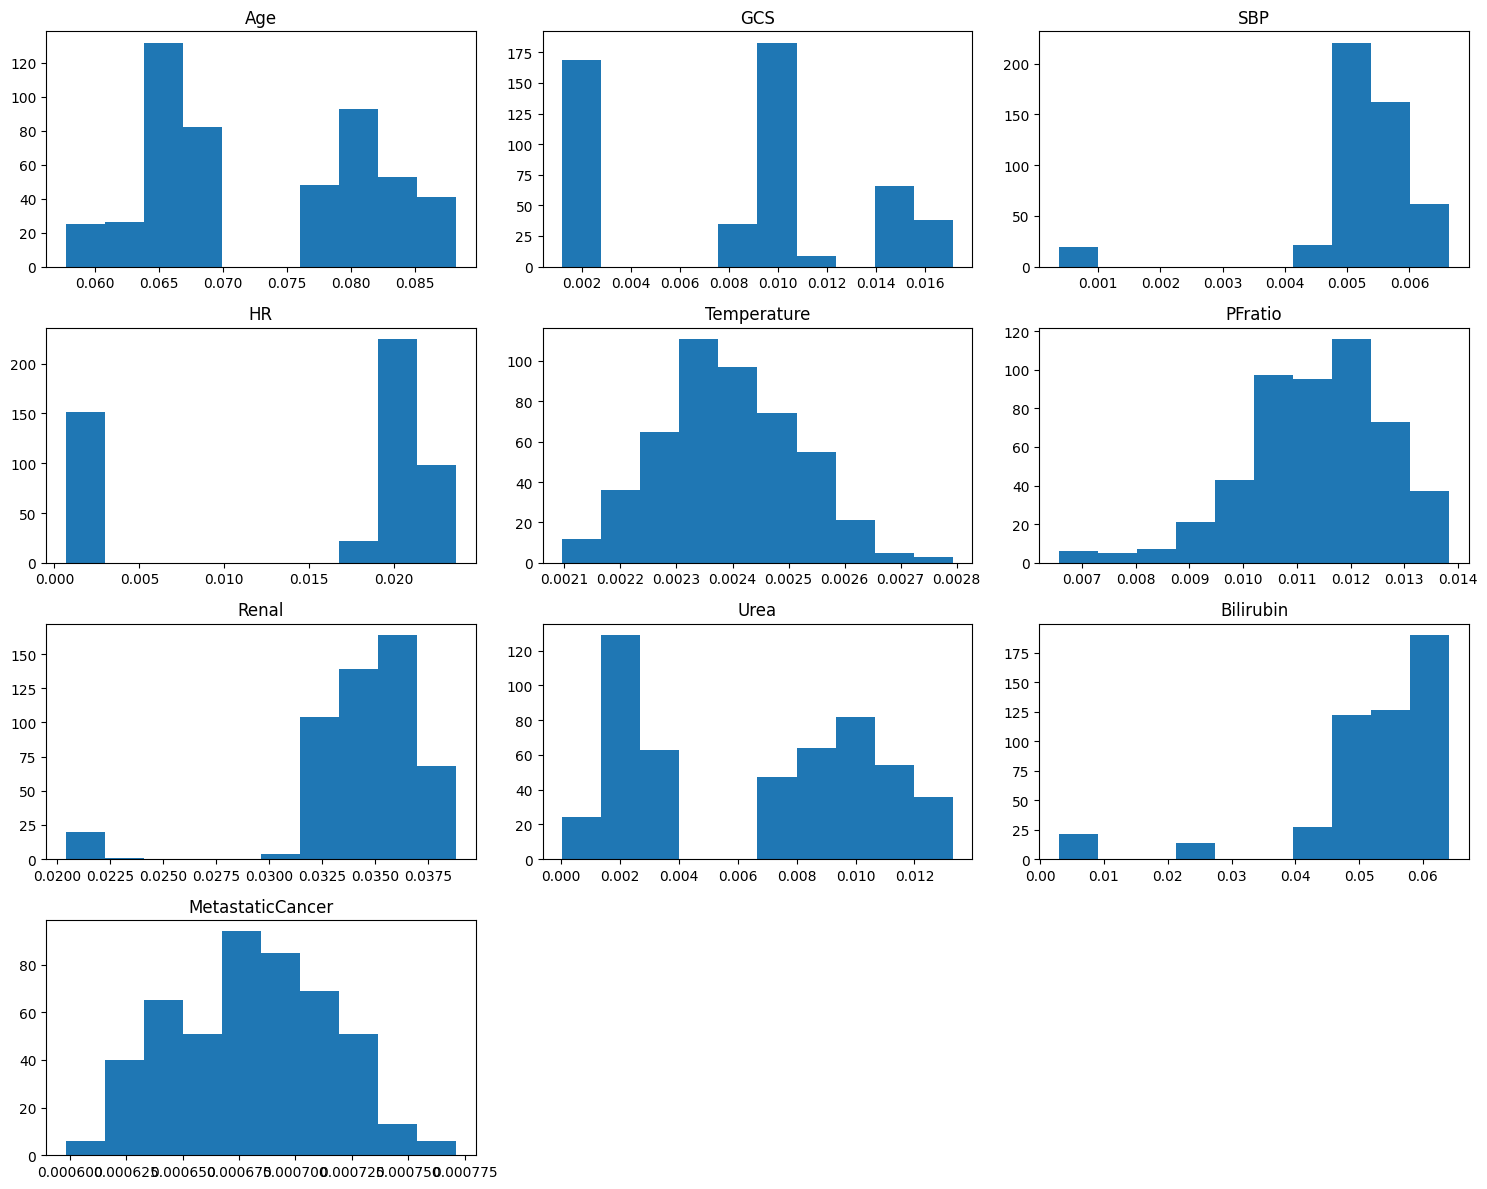

method: swapping_4, model_count: 1724


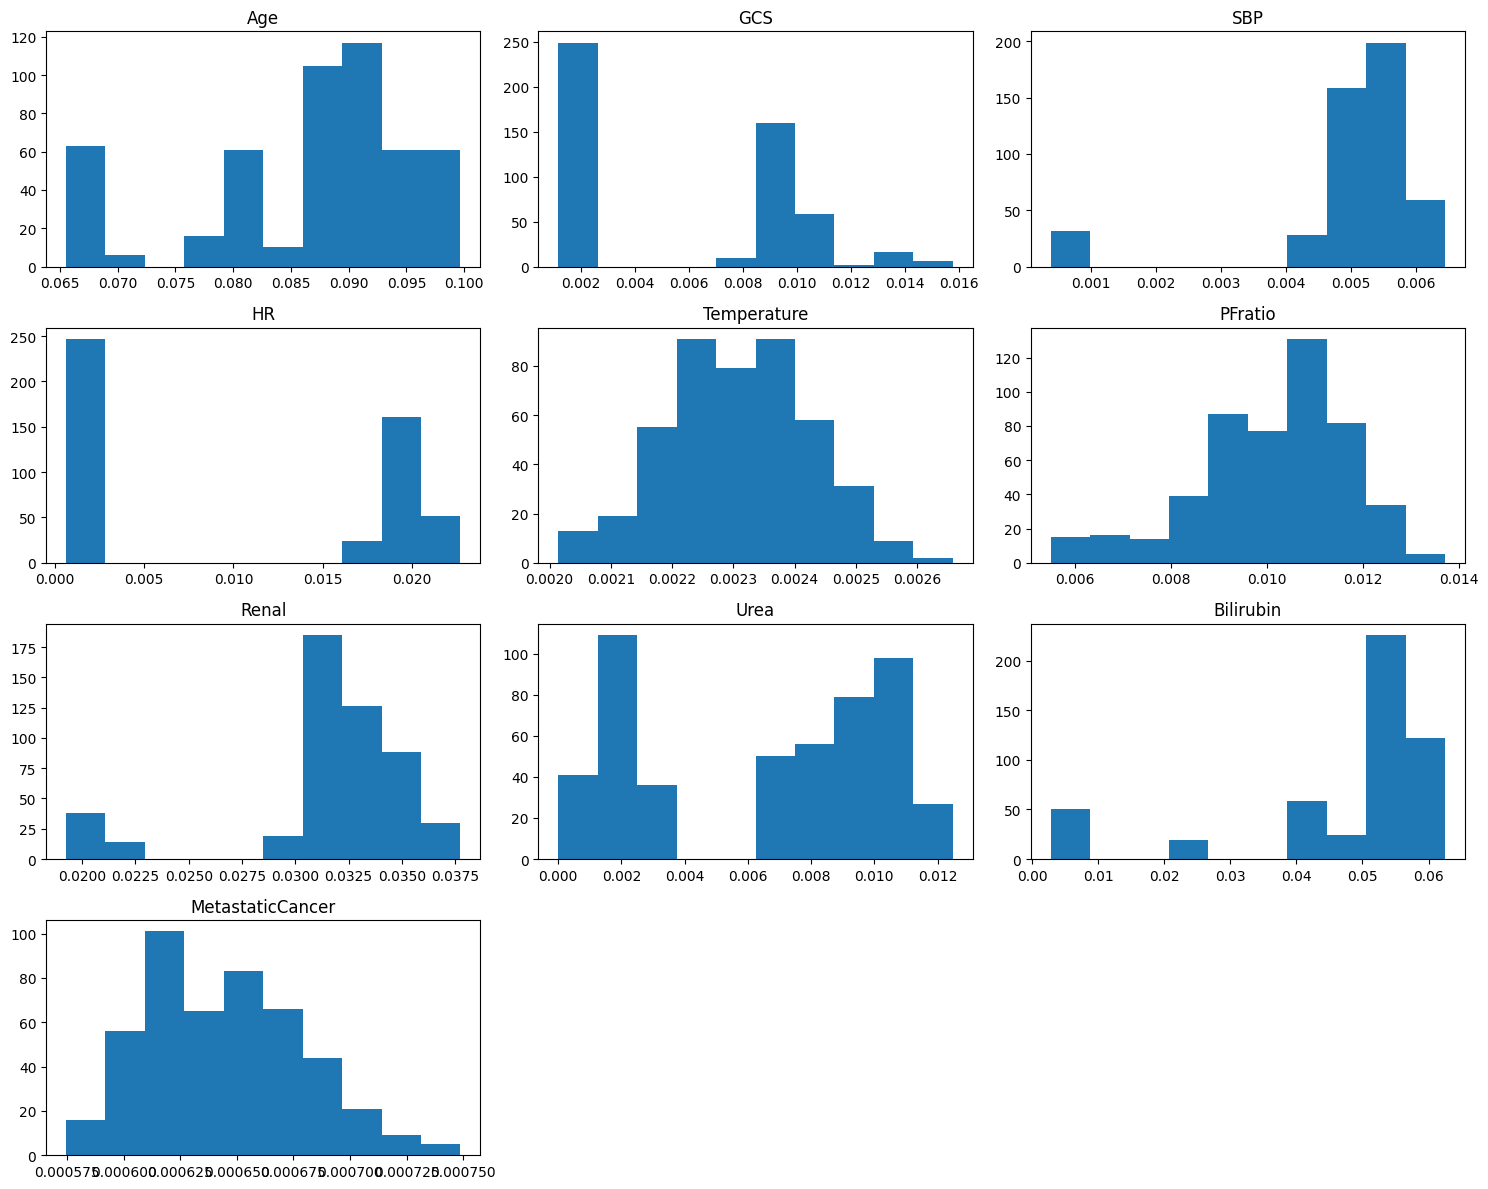

method: swapping_5, model_count: 834


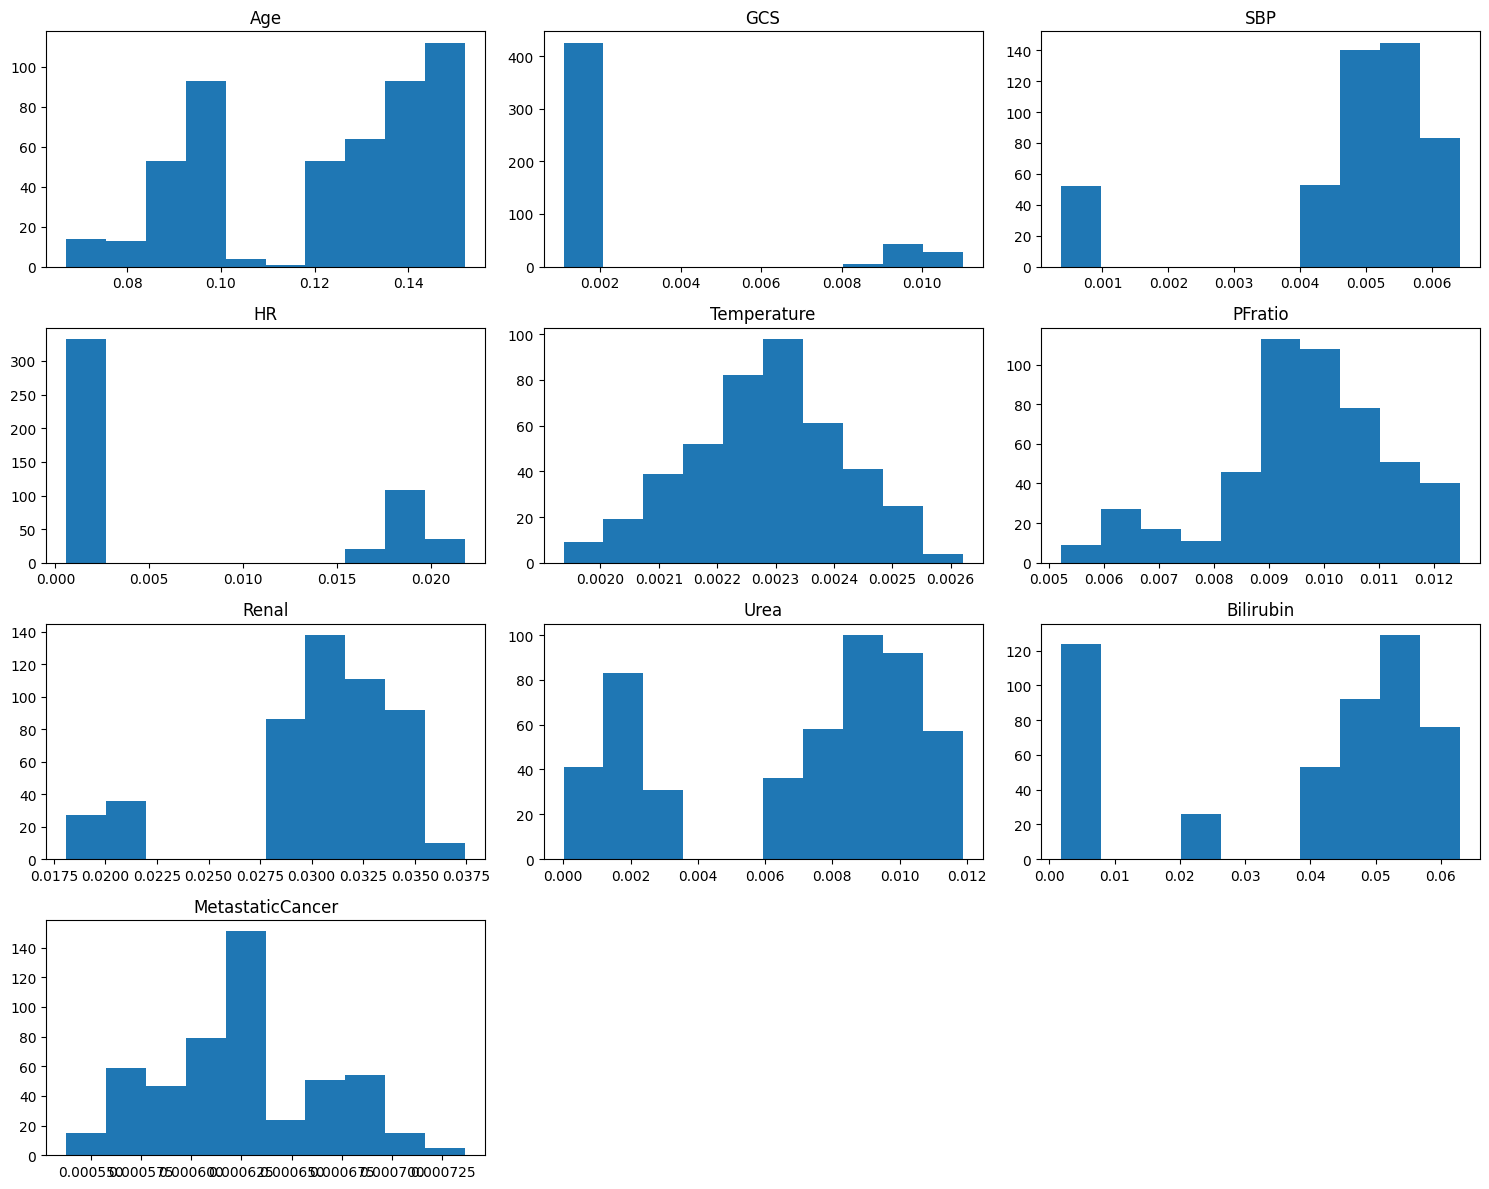

method: hybrid, model_count: 2620


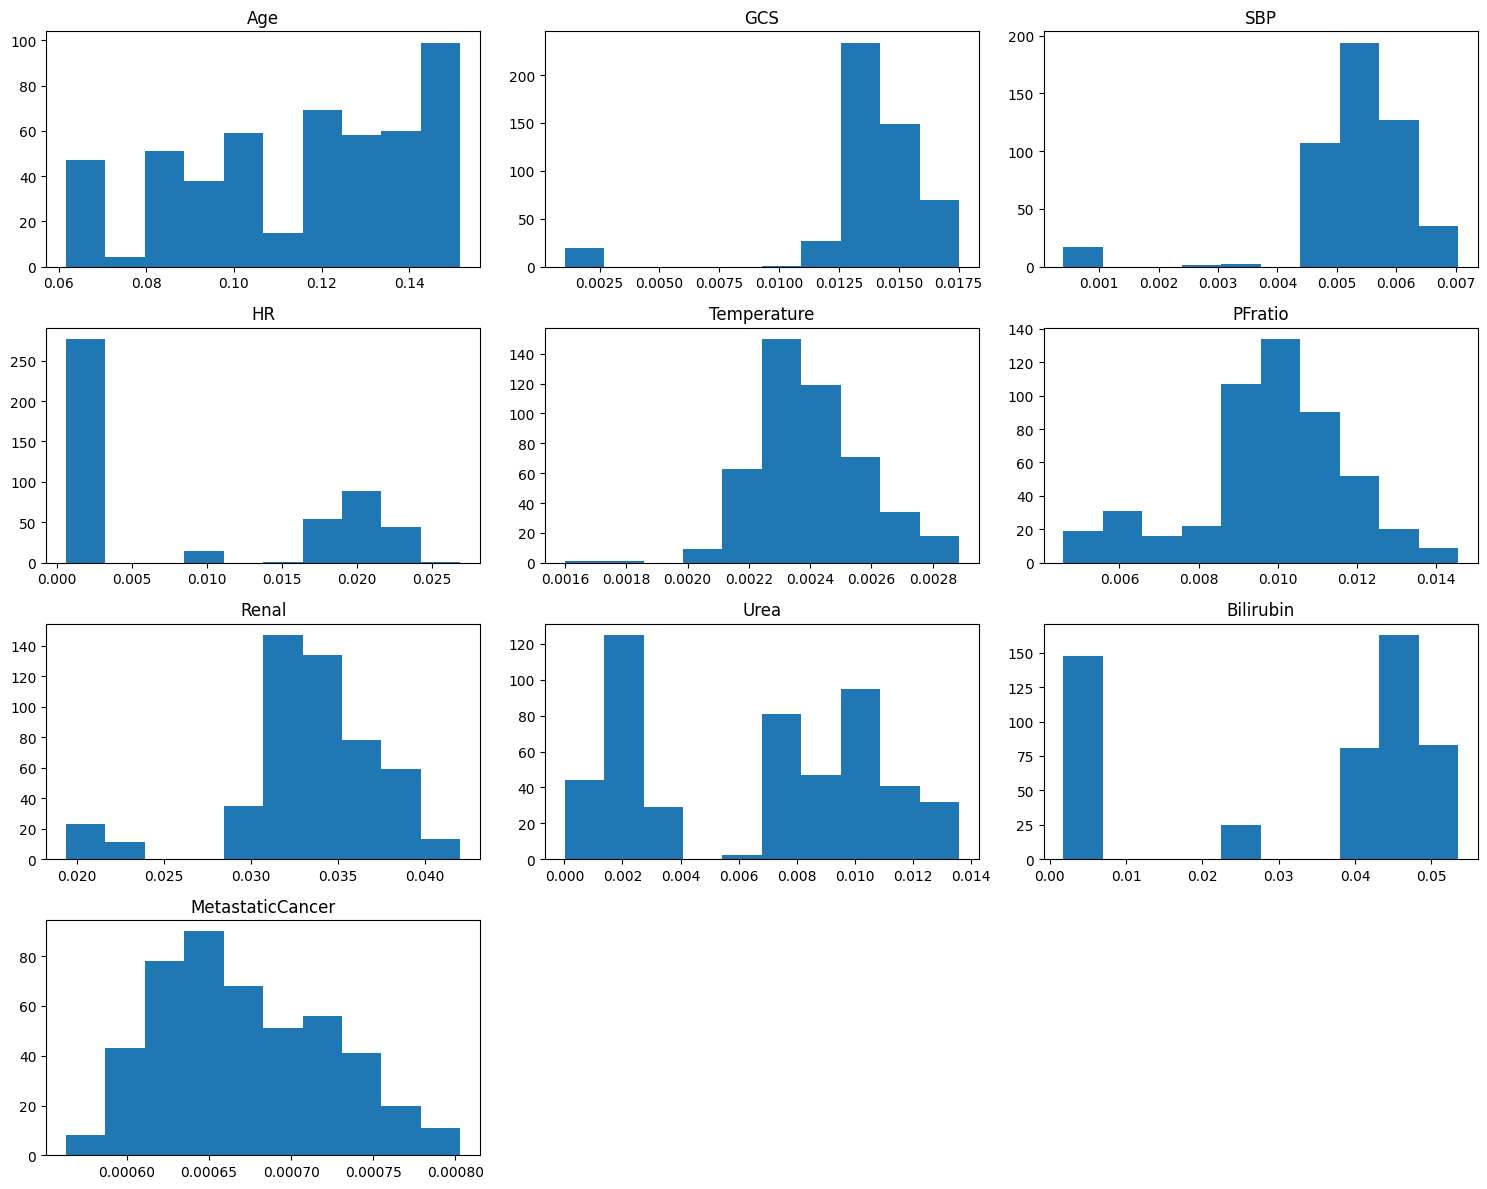

In [49]:
show_variable_importance(all_datasets_results, 'mimic2')

	uniform__ellipsoid_sampling: 0.07190453606941441 - 0.15604348347697164
	uniform_surface_ellipsoid_sampling: 0.07912740607454975 - 0.15525385127932714
	poisson__ellipsoid_sampling: 0.07655352338217991 - 0.16265080315861133
	poisson_euclidean_ellipsoid_sampling: 0.06789981600733536 - 0.14890257423931352
	permutation__ellipsoid_sampling: 0.0687746420117194 - 0.1716979425719532
	permutation_poisson_ellipsoid_sampling: 0.12352369030745287 - 0.14199834210966567
	blocking: 0.10240390375727518 - 0.12075491944769866
	quadratic: 0.10233124052916456 - 0.1463492713934444
	swapping_1: 0.05794459658334471 - 0.12474412074534615
	swapping_2: 0.04758865370630822 - 0.07250008430995931
	swapping_3: 0.05771281119979599 - 0.08820132526860484
	swapping_4: 0.0655259521391429 - 0.09966848309634788
	swapping_5: 0.06687357167677645 - 0.15219352882526896
	hybrid: 0.06163597909791925 - 0.15166327024321777


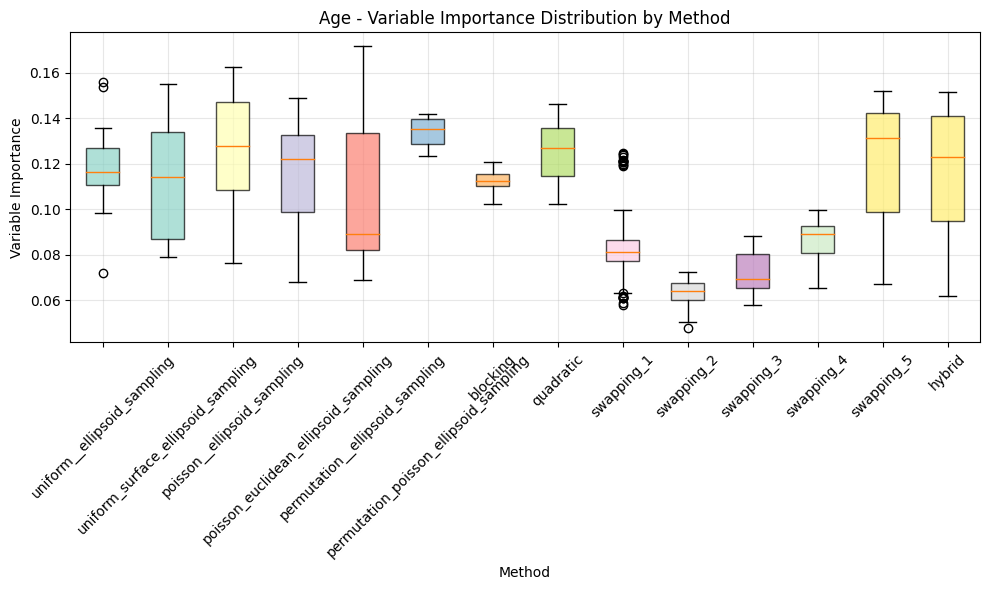

	uniform__ellipsoid_sampling: 0.02955607108525029 - 0.07471232215207473
	uniform_surface_ellipsoid_sampling: 0.031049621462965905 - 0.07209528698023564
	poisson__ellipsoid_sampling: 0.03169610230447813 - 0.07570754368841412
	poisson_euclidean_ellipsoid_sampling: 0.03465365496665828 - 0.06661846591417439
	permutation__ellipsoid_sampling: 0.025082937908142557 - 0.07091371023784414
	permutation_poisson_ellipsoid_sampling: 0.027159530116808325 - 0.05848386436071283
	blocking: 0.034769749903130254 - 0.05840977069157427
	quadratic: 0.03845019306634544 - 0.05649275383856676
	swapping_1: 0.002729888517138663 - 0.05979384317487609
	swapping_2: 0.003080257336680358 - 0.0639836662859528
	swapping_3: 0.002913526203216041 - 0.06414915356151348
	swapping_4: 0.0027873839739367906 - 0.06252013803951821
	swapping_5: 0.00178149285936342 - 0.06292223074023531
	hybrid: 0.001777684400138264 - 0.05350526403661608


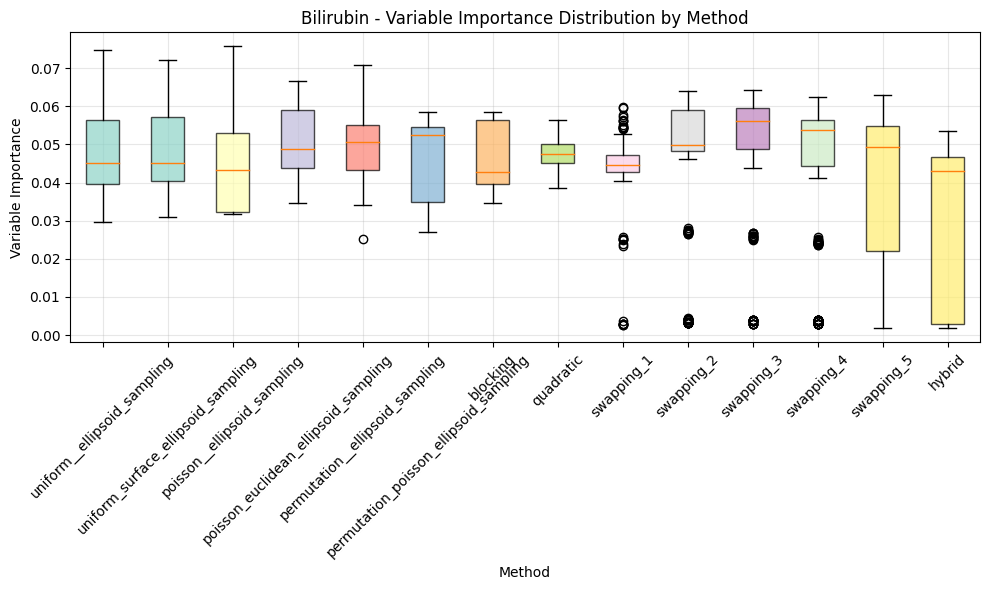

	uniform__ellipsoid_sampling: 0.0008198503567718613 - 0.011810849146867265
	uniform_surface_ellipsoid_sampling: 0.00110578687021508 - 0.015138814837702005
	poisson__ellipsoid_sampling: 0.001032410293931733 - 0.010333505604897545
	poisson_euclidean_ellipsoid_sampling: 0.0009714940546252397 - 0.014318808114436025
	permutation__ellipsoid_sampling: 0.001045556447956847 - 0.01883529860920615
	permutation_poisson_ellipsoid_sampling: 0.001178940399609347 - 0.011486937942743317
	blocking: 0.007661852057070629 - 0.016102978518375312
	quadratic: 0.0012480983576559947 - 0.010205892149224391
	swapping_1: 0.002216779984172277 - 0.01548518448202989
	swapping_2: 0.0024469828493977443 - 0.0168756248049614
	swapping_3: 0.0011991673084906333 - 0.017126137579870155
	swapping_4: 0.001145711720277804 - 0.015761283670496156
	swapping_5: 0.0010960706232325433 - 0.010999448582175135
	hybrid: 0.0010363587018302695 - 0.017524022063047484


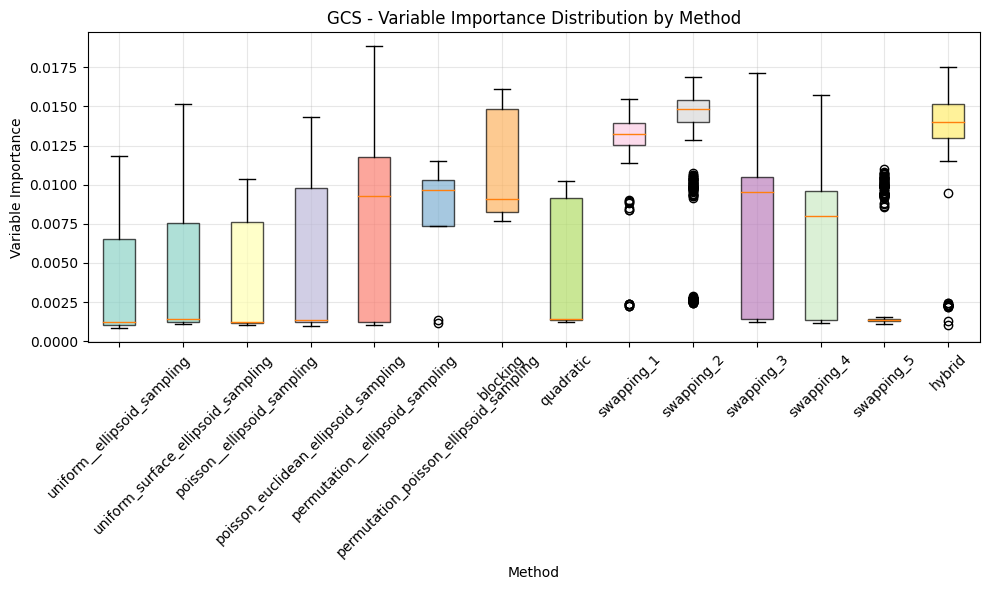

	uniform__ellipsoid_sampling: 0.0005451567024034867 - 0.02818229527754582
	uniform_surface_ellipsoid_sampling: 0.0006126699032216415 - 0.023972357865551443
	poisson__ellipsoid_sampling: 0.0005679504065600326 - 0.02701825244505957
	poisson_euclidean_ellipsoid_sampling: 0.0005514419792493296 - 0.026566271857157042
	permutation__ellipsoid_sampling: 0.0004800973405069804 - 0.03184462295487714
	permutation_poisson_ellipsoid_sampling: 0.00042707948682719484 - 0.02988592378389918
	blocking: 0.013821495762707019 - 0.02484880417108127
	quadratic: 0.0006931298791749336 - 0.0199192733872478
	swapping_1: 0.0006516122448983871 - 0.02260825006129894
	swapping_2: 0.000709839306125484 - 0.024048571490710893
	swapping_3: 0.0006565363351079517 - 0.023650841221203145
	swapping_4: 0.0006094583115260135 - 0.02272082739961989
	swapping_5: 0.0005711933045114287 - 0.021822084639800555
	hybrid: 0.0006066749504478948 - 0.026885777457524147


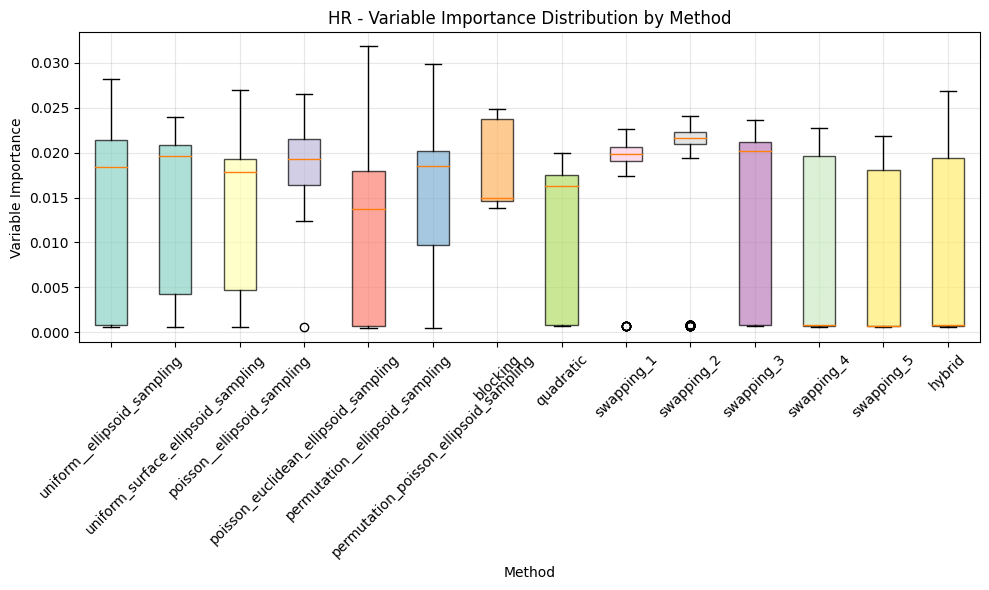

	uniform__ellipsoid_sampling: 0.00046585862092973193 - 0.0006985560620917245
	uniform_surface_ellipsoid_sampling: 0.0004304895427942501 - 0.0007338737014433692
	poisson__ellipsoid_sampling: 0.000517665054832935 - 0.0006342259407397509
	poisson_euclidean_ellipsoid_sampling: 0.0004043377358100575 - 0.0006763837526260272
	permutation__ellipsoid_sampling: 0.0004154293890627563 - 0.0007926502950065909
	permutation_poisson_ellipsoid_sampling: 0.0004667965641155345 - 0.000756571664242984
	blocking: 0.0004462481589874175 - 0.0005034937992985521
	quadratic: 0.00048295092336554603 - 0.0005939186777382536
	swapping_1: 0.0005923739664414042 - 0.0007423593387668301
	swapping_2: 0.0006383783674624781 - 0.0007982992713825295
	swapping_3: 0.000598148431235598 - 0.0007712615357760656
	swapping_4: 0.0005745307769200777 - 0.0007487586527170653
	swapping_5: 0.000537694857768275 - 0.0007362602697166596
	hybrid: 0.0005626911095292388 - 0.0008030935591997706


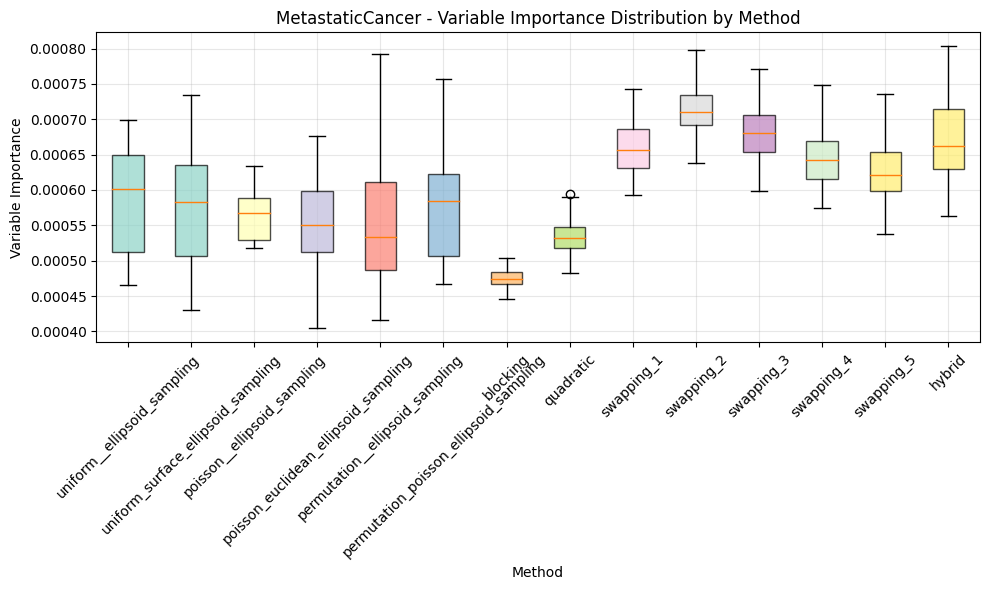

	uniform__ellipsoid_sampling: 0.007180096588039149 - 0.012541757771600718
	uniform_surface_ellipsoid_sampling: 0.006464154233957358 - 0.012870325505574575
	poisson__ellipsoid_sampling: 0.007811241755127332 - 0.012551573919985046
	poisson_euclidean_ellipsoid_sampling: 0.007604991409925178 - 0.011695025321205522
	permutation__ellipsoid_sampling: 0.006126179947222118 - 0.011118825963323377
	permutation_poisson_ellipsoid_sampling: 0.0075384509363695465 - 0.010098367318059473
	blocking: 0.008398683207853417 - 0.010356960215655138
	quadratic: 0.008275862651445238 - 0.010737798741954465
	swapping_1: 0.007619596819727644 - 0.013551537196328062
	swapping_2: 0.00809717476931959 - 0.014540064761732054
	swapping_3: 0.006567692915377823 - 0.013837403955952966
	swapping_4: 0.005489866758013027 - 0.013712711036056775
	swapping_5: 0.0052234426696985865 - 0.012467733231985923
	hybrid: 0.004583832012871899 - 0.01455380269442194


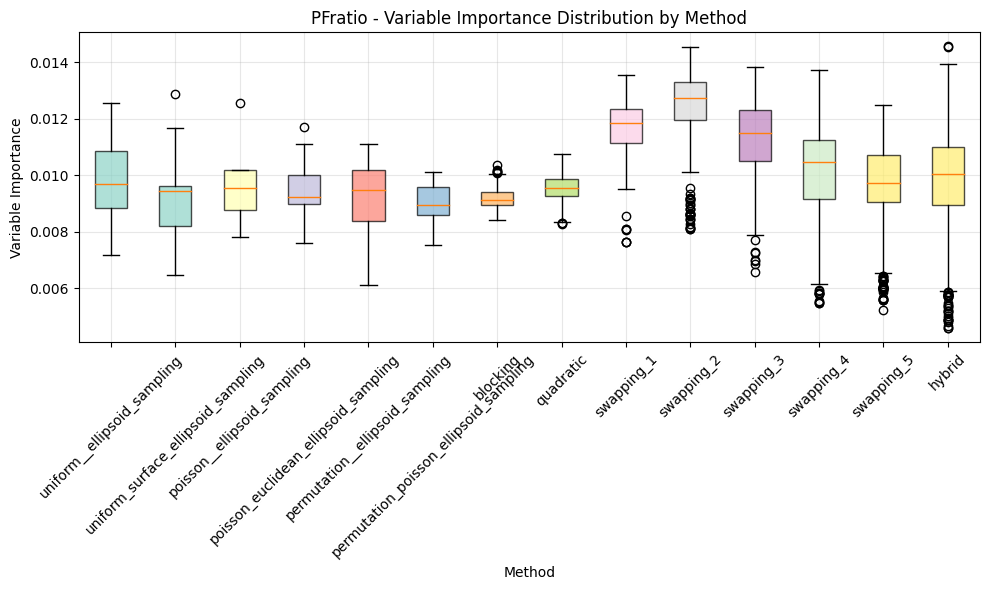

	uniform__ellipsoid_sampling: 0.019735441741044475 - 0.033220881926895256
	uniform_surface_ellipsoid_sampling: 0.023567682929890196 - 0.03645969615514794
	poisson__ellipsoid_sampling: 0.017178023505267263 - 0.03343408999994479
	poisson_euclidean_ellipsoid_sampling: 0.01811924014103345 - 0.038130438765810994
	permutation__ellipsoid_sampling: 0.021998937570575333 - 0.03829448223750183
	permutation_poisson_ellipsoid_sampling: 0.026078081247911698 - 0.03386255512639015
	blocking: 0.021466449603272052 - 0.02779467713232902
	quadratic: 0.02452943376454917 - 0.02941508888686082
	swapping_1: 0.021093433582195814 - 0.03882627220622679
	swapping_2: 0.022577052737342947 - 0.041886587628694495
	swapping_3: 0.020392142631332832 - 0.03882205375217117
	swapping_4: 0.01923591675798021 - 0.03774256755102619
	swapping_5: 0.018090290357319978 - 0.037437656734712776
	hybrid: 0.019380554723706887 - 0.042061132579009425


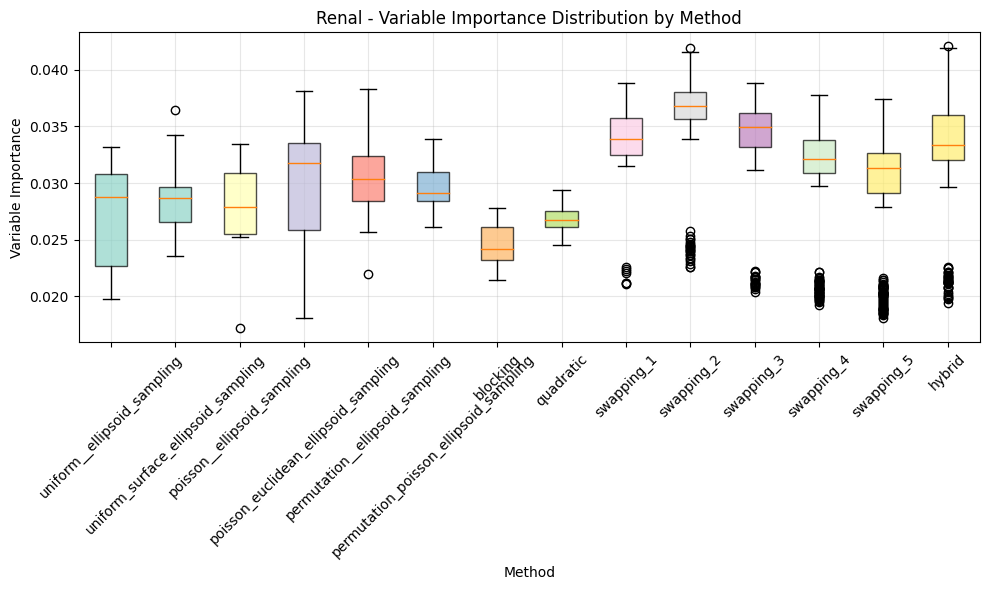

	uniform__ellipsoid_sampling: 0.0021900547645237285 - 0.0049498630434943285
	uniform_surface_ellipsoid_sampling: 0.002337841676352959 - 0.0074870995737459116
	poisson__ellipsoid_sampling: 0.0036464051451737625 - 0.005370321449934209
	poisson_euclidean_ellipsoid_sampling: 0.0028249672232565953 - 0.007163254991856601
	permutation__ellipsoid_sampling: 0.0024964676771735616 - 0.006785020832143055
	permutation_poisson_ellipsoid_sampling: 0.0021137675329699623 - 0.0046586142857931055
	blocking: 0.0037948411008195504 - 0.004567375619193486
	quadratic: 0.003661850108202396 - 0.00449584731039131
	swapping_1: 0.0003995255384152887 - 0.006209972747871367
	swapping_2: 0.0003674831514314214 - 0.006689914913301451
	swapping_3: 0.00036828705184453834 - 0.006639818230592097
	swapping_4: 0.000379235568293964 - 0.006456336232896367
	swapping_5: 0.0003714398088129424 - 0.0064258250190286454
	hybrid: 0.0003953961670716411 - 0.0070391834664294654


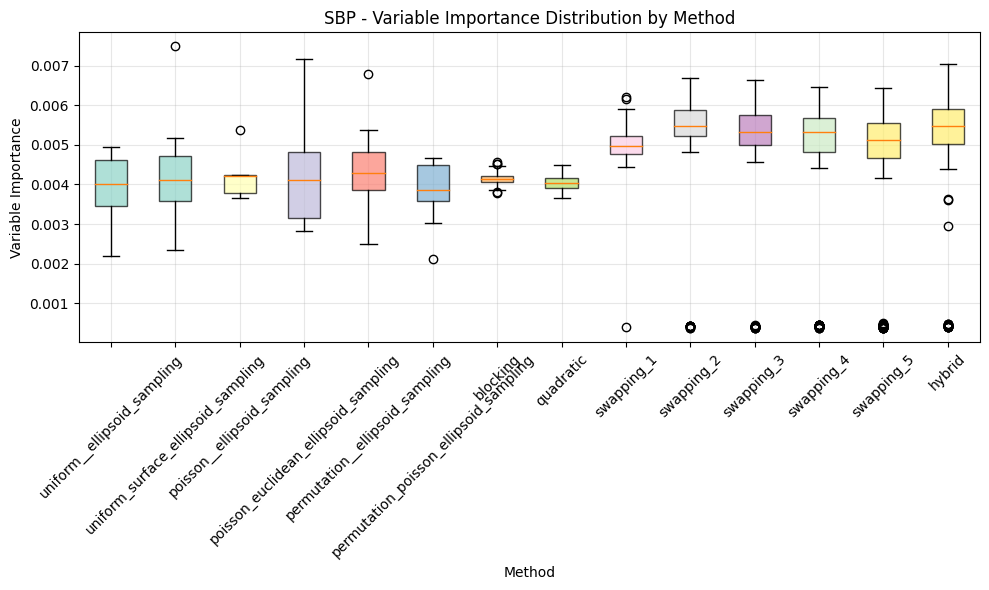

	uniform__ellipsoid_sampling: 0.0015239319767357093 - 0.003027029988029525
	uniform_surface_ellipsoid_sampling: 0.001485918950210996 - 0.0029135760310091794
	poisson__ellipsoid_sampling: 0.0016345280720643752 - 0.00255857302193905
	poisson_euclidean_ellipsoid_sampling: 0.0012463002757312227 - 0.0028447876108088355
	permutation__ellipsoid_sampling: 0.0013045348150992017 - 0.002788299554486721
	permutation_poisson_ellipsoid_sampling: 0.0012282230767944628 - 0.003202441734674124
	blocking: 0.0015321990319001923 - 0.0017211810167563344
	quadratic: 0.0016025180653306413 - 0.002035220638750397
	swapping_1: 0.002070660131188122 - 0.002608575381114589
	swapping_2: 0.002208000540476756 - 0.0028006709129875214
	swapping_3: 0.0020959442434518583 - 0.0027931772222910102
	swapping_4: 0.002014019834355047 - 0.0026581687123294626
	swapping_5: 0.0019367991158585045 - 0.002620359113966927
	hybrid: 0.001598927602026894 - 0.002886004430229339


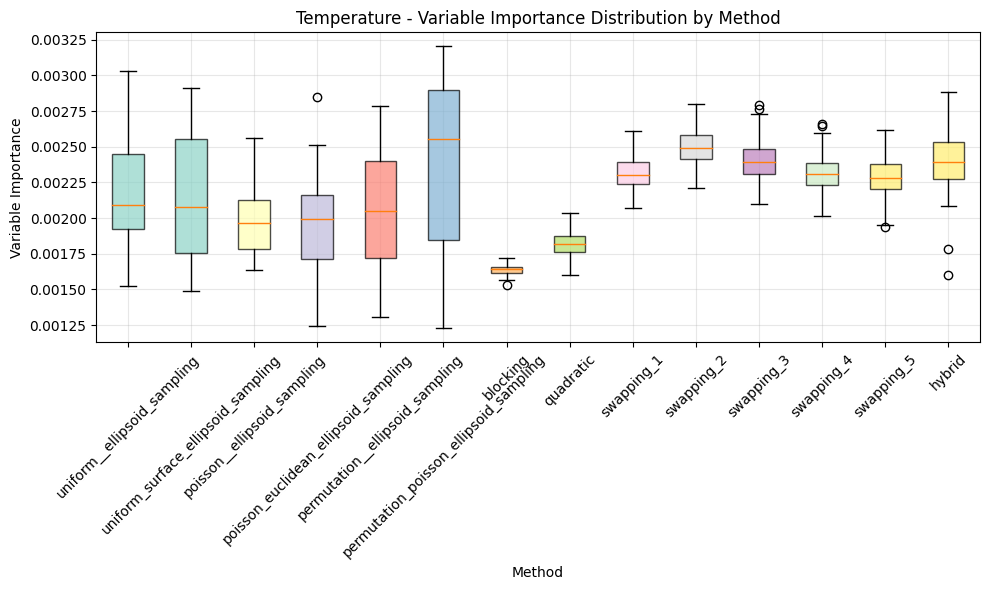

	uniform__ellipsoid_sampling: 0.0012393384539144832 - 0.02135043349034141
	uniform_surface_ellipsoid_sampling: 0.001160610598080302 - 0.013037571930171585
	poisson__ellipsoid_sampling: 0.001243890715826057 - 0.00312330874349449
	poisson_euclidean_ellipsoid_sampling: 0.0011841873567200363 - 0.01337535885534802
	permutation__ellipsoid_sampling: 0.000991013796845384 - 0.009928152372393058
	permutation_poisson_ellipsoid_sampling: 0.0011285624515521907 - 0.0032603289757105274
	blocking: 0.005740762226225494 - 0.015026869468045868
	quadratic: 0.0012951699701430925 - 0.0015908727550746655
	swapping_1: 0.00010110909189247655 - 0.009729541297893253
	swapping_2: 0.00012119366339903933 - 0.013437675030911499
	swapping_3: 3.04815866459249e-05 - 0.013301904992223581
	swapping_4: 8.664030746893058e-09 - 0.012483827715343015
	swapping_5: 6.817097826862085e-06 - 0.011875453280465964
	hybrid: 8.093317487019768e-06 - 0.013585825878527663


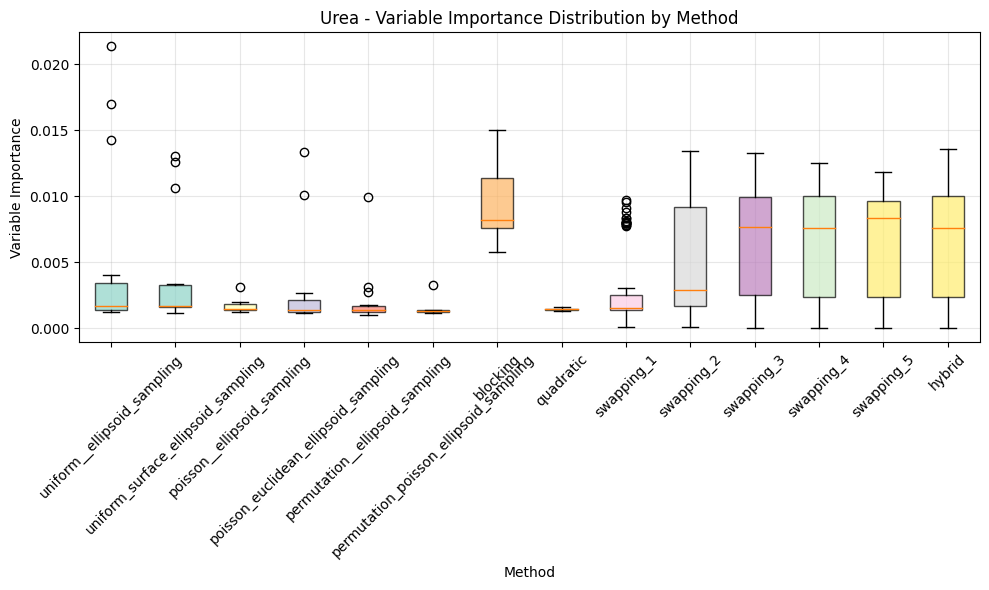

In [48]:
show_model_reliance(all_datasets_results, "mimic2")

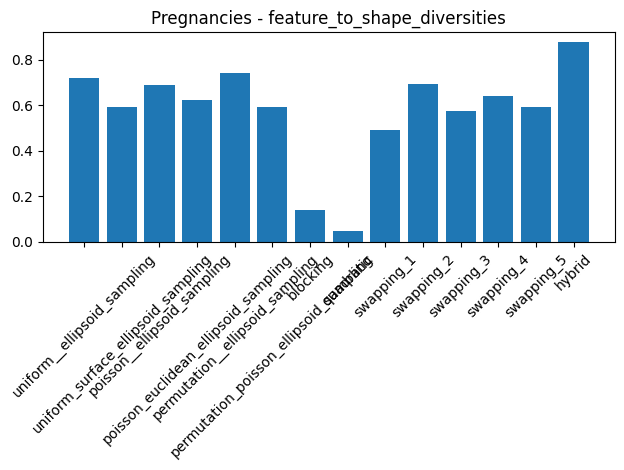

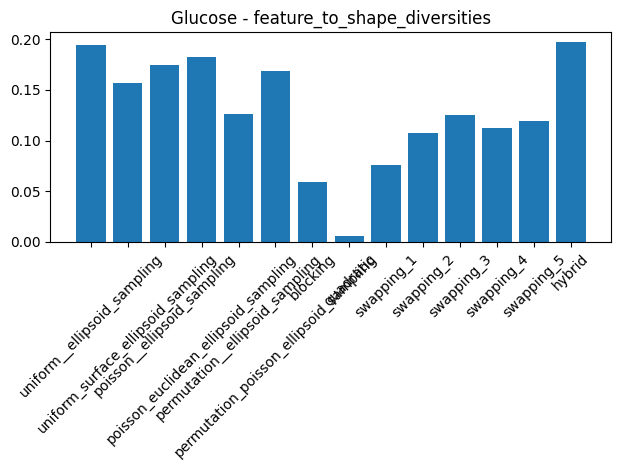

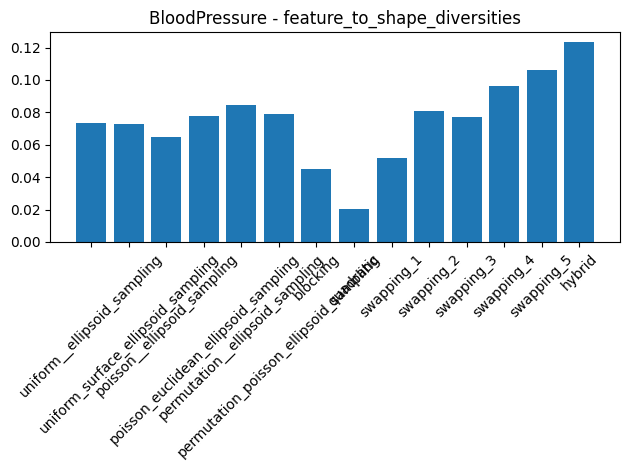

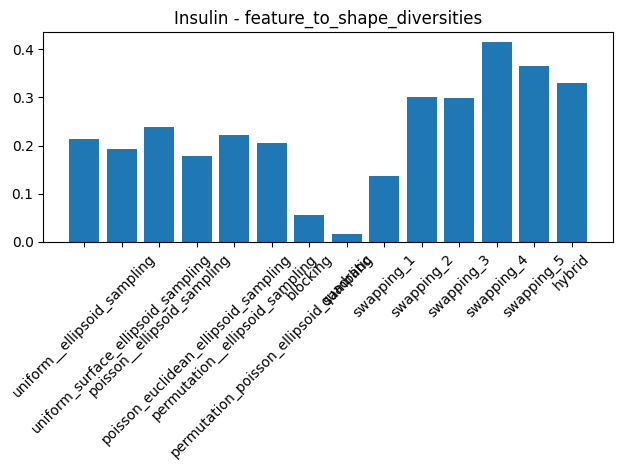

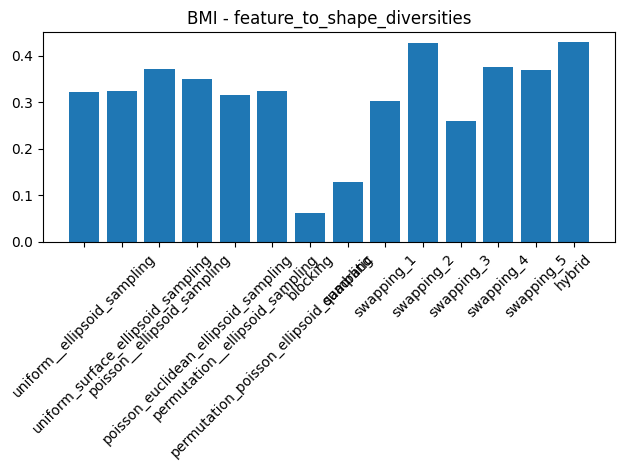

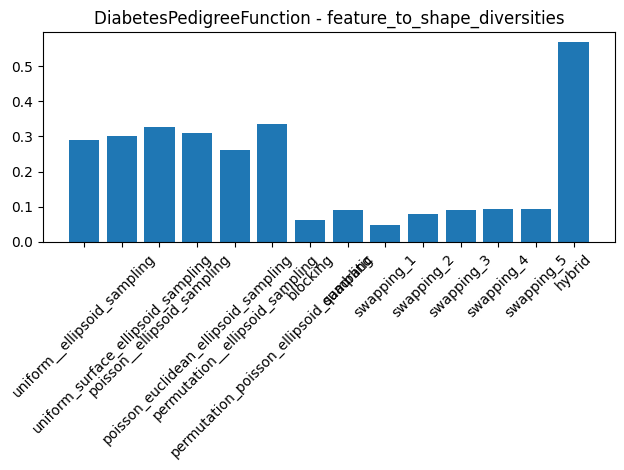

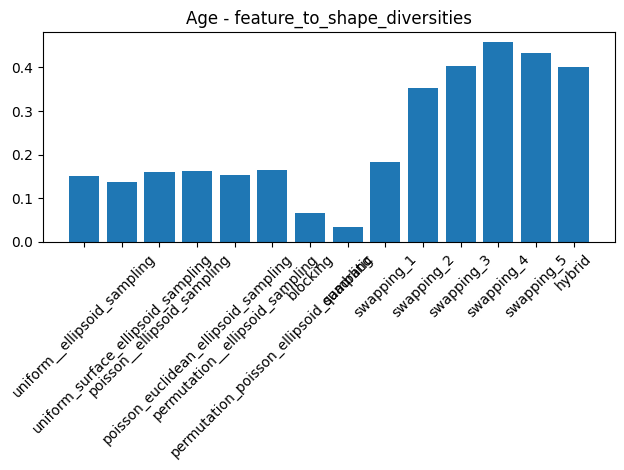

In [ ]:
x = ['feature_to_shape_differences', 'feature_to_shape_diversities']
show_feature_to_shape_diversity(all_datasets_results, "diabetes", x[1])

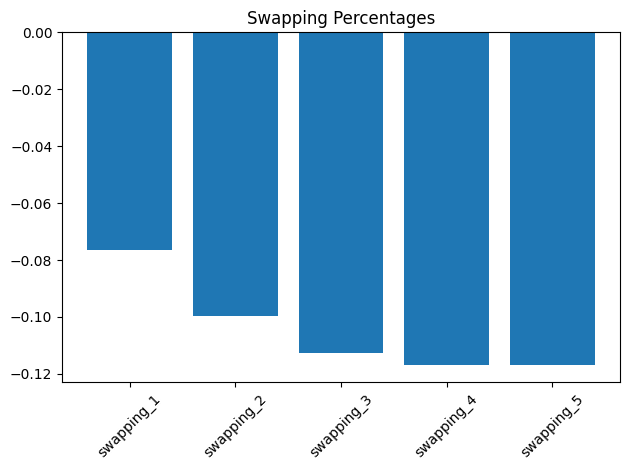

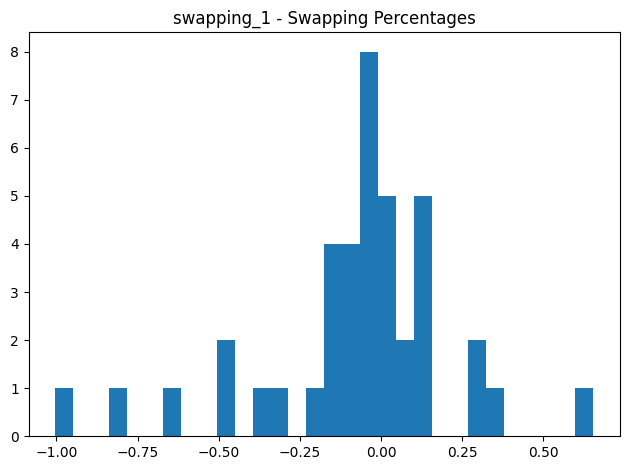

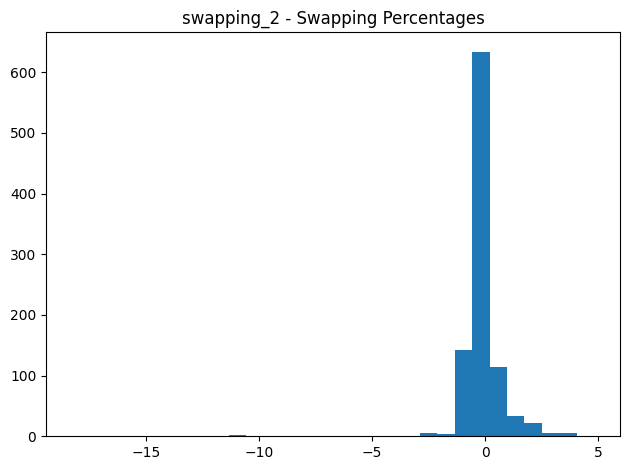

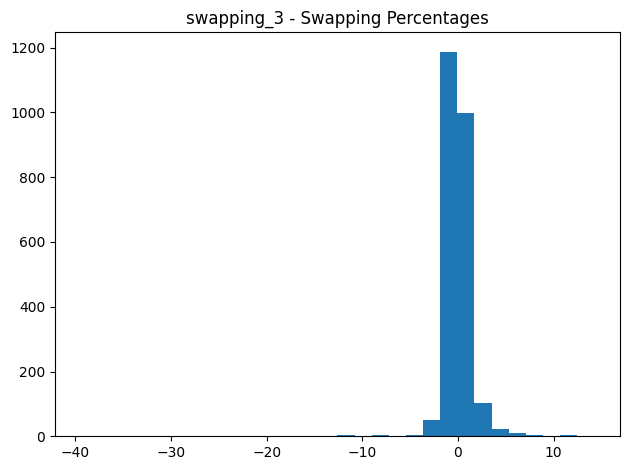

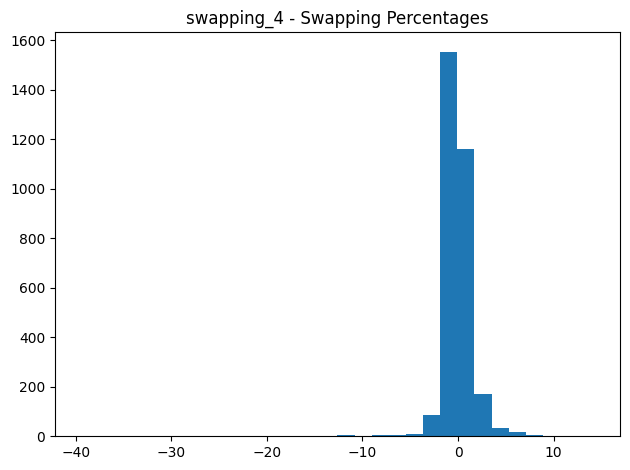

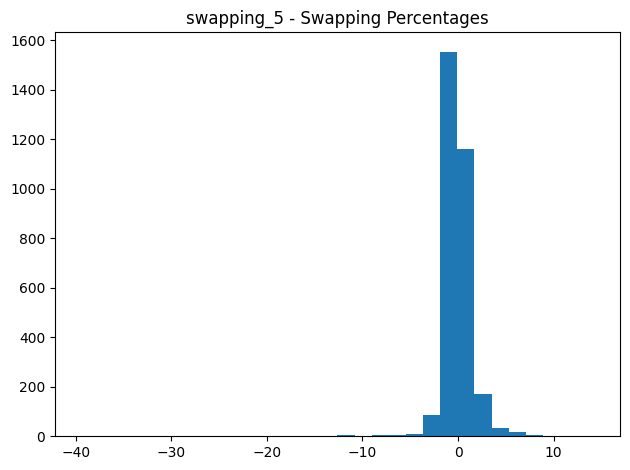

In [38]:
show_swapping_percentages(all_datasets_results, "diabetes")

### Collate and Save Models

In [10]:
def collate_models(all_datasets_results, dataset_name, methods, n_samples):
    df = all_datasets_results[dataset_name]
    n_estimators = df.iloc[0]['n_estimators']

    path = f"datasets/{dataset_name}.csv"
    X, y, _, new_header, sample_p = BaseGAMRSetMethod.get_binned_dataset(path, n_estimators)

    collated_w_rset = []
    data = {}
    for i, row in df.iterrows():
        if row['method'] not in methods:
            continue

        print(row['method'], row['w_rset'].shape)
        BaseGAMRSetMethod.get_loss(
            X, y, 
            row['w_rset'], 
            loss_type="logistic", 
            verbosity=1,
            w_opt=row['w_opt'], 
            l2=row['l2'], 
            sample_p=sample_p
        )
        if row['w_rset'].shape[0] > n_samples:
            selected_indices = np.random.choice(row['w_rset'].shape[0], n_samples, replace=False)
            collated_w_rset.append(row['w_rset'][selected_indices])
        else:
            collated_w_rset.append(row['w_rset'])
        collated_w_rset.append(row['w_opt'])
        data[row['method']] = {
            'w_rset': row['w_rset'],
            'w_opt': row['w_opt'],
        }
    collated_w_rset = np.vstack(collated_w_rset)

    data['X'] = X
    data['y'] = y
    data['header'] = np.array(new_header)
    data['w_rset'] = collated_w_rset
    data['sample_p'] = sample_p
    return data

def load_models(dataset_name):
    with open(f'{dataset_name}_models.pkl', 'rb') as f:
        return pickle.load(f)

def save_models(all_datasets_results, dataset_name, methods, n_samples):
    models = collate_models(all_datasets_results, dataset_name, methods, n_samples)

    with open(f'{dataset_name}_models.pkl', 'wb') as f:
        pickle.dump(models, f)

In [21]:
# collate best models for diabetes
diabetes_methods = ['hybrid', 'swapping_3']
save_models(all_datasets_results, 'diabetes', diabetes_methods, 100)

swapping_3 (336, 50)
Optimal model logistic loss: 0.3695960101244631
Average logistic loss: 0.3729383450158349
hybrid (482, 50)
Optimal model logistic loss: 0.36727192614085474
Average logistic loss: 0.3743084753707647


100%|██████████| 202/202 [00:00<00:00, 5447.53it/s]


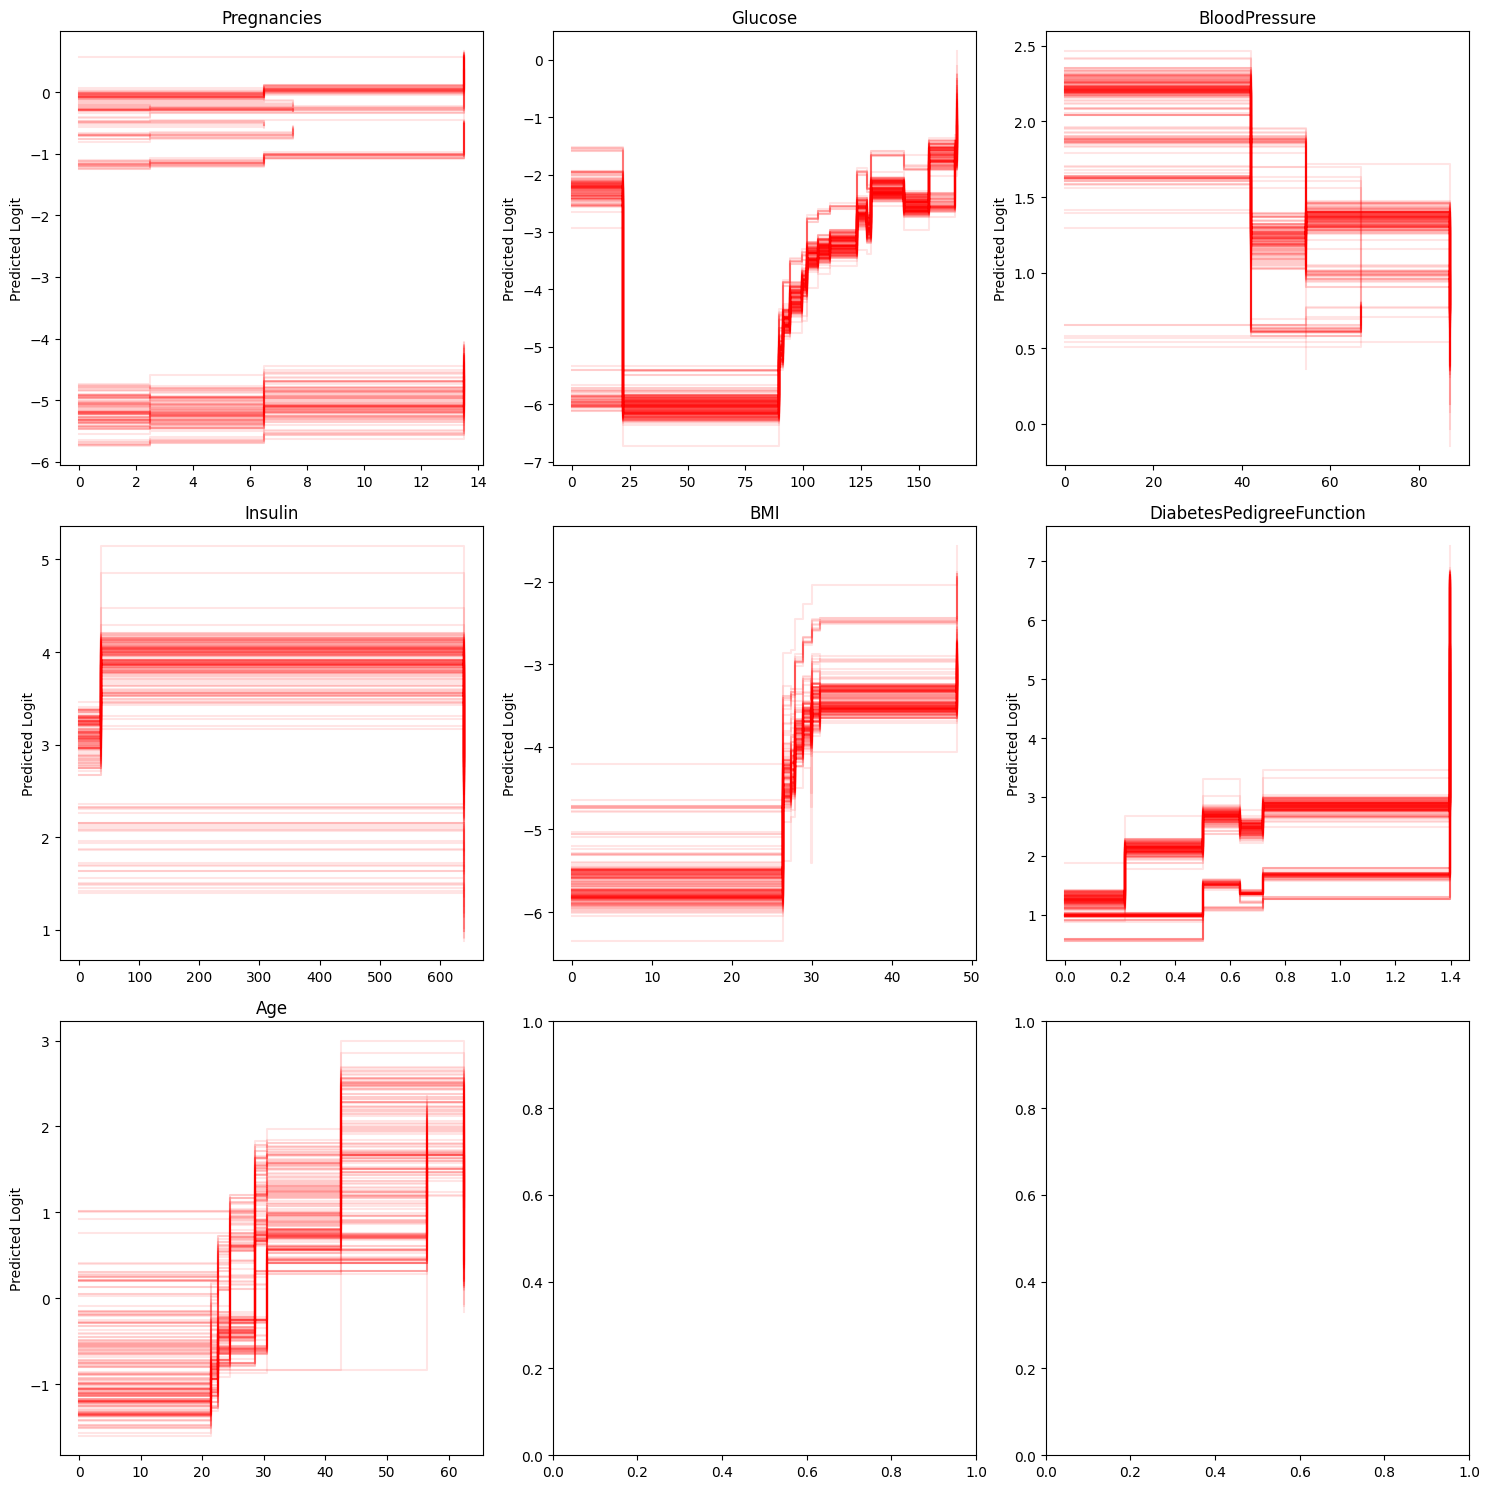

In [23]:
diabetes_models = load_models('diabetes')

# for dm in diabetes_methods:
#     print(f"GAM for {dm}")
#     model = diabetes_models[dm]
#     _ = plot_gam(diabetes_models['header'][1:], model['w_rset'][:300, 1:])

_ = plot_gam(diabetes_models['header'][1:], diabetes_models['w_rset'][:, 1:])

In [22]:
# collate best models for mimic2
mimic2_methods = ['hybrid', 'permutation__ellipsoid_sampling', 'swapping_3']
save_models(all_datasets_results, 'mimic2', mimic2_methods, 100)

permutation__ellipsoid_sampling (20, 33)
Optimal model logistic loss: 0.3017668176389954
Average logistic loss: 0.3053485000266317
swapping_3 (2682, 33)
Optimal model logistic loss: 0.2948214231169126
Average logistic loss: 0.29650560323492137
hybrid (2620, 33)
Optimal model logistic loss: 0.29353623949115243
Average logistic loss: 0.29692095244676286


100%|██████████| 223/223 [00:00<00:00, 8803.85it/s]


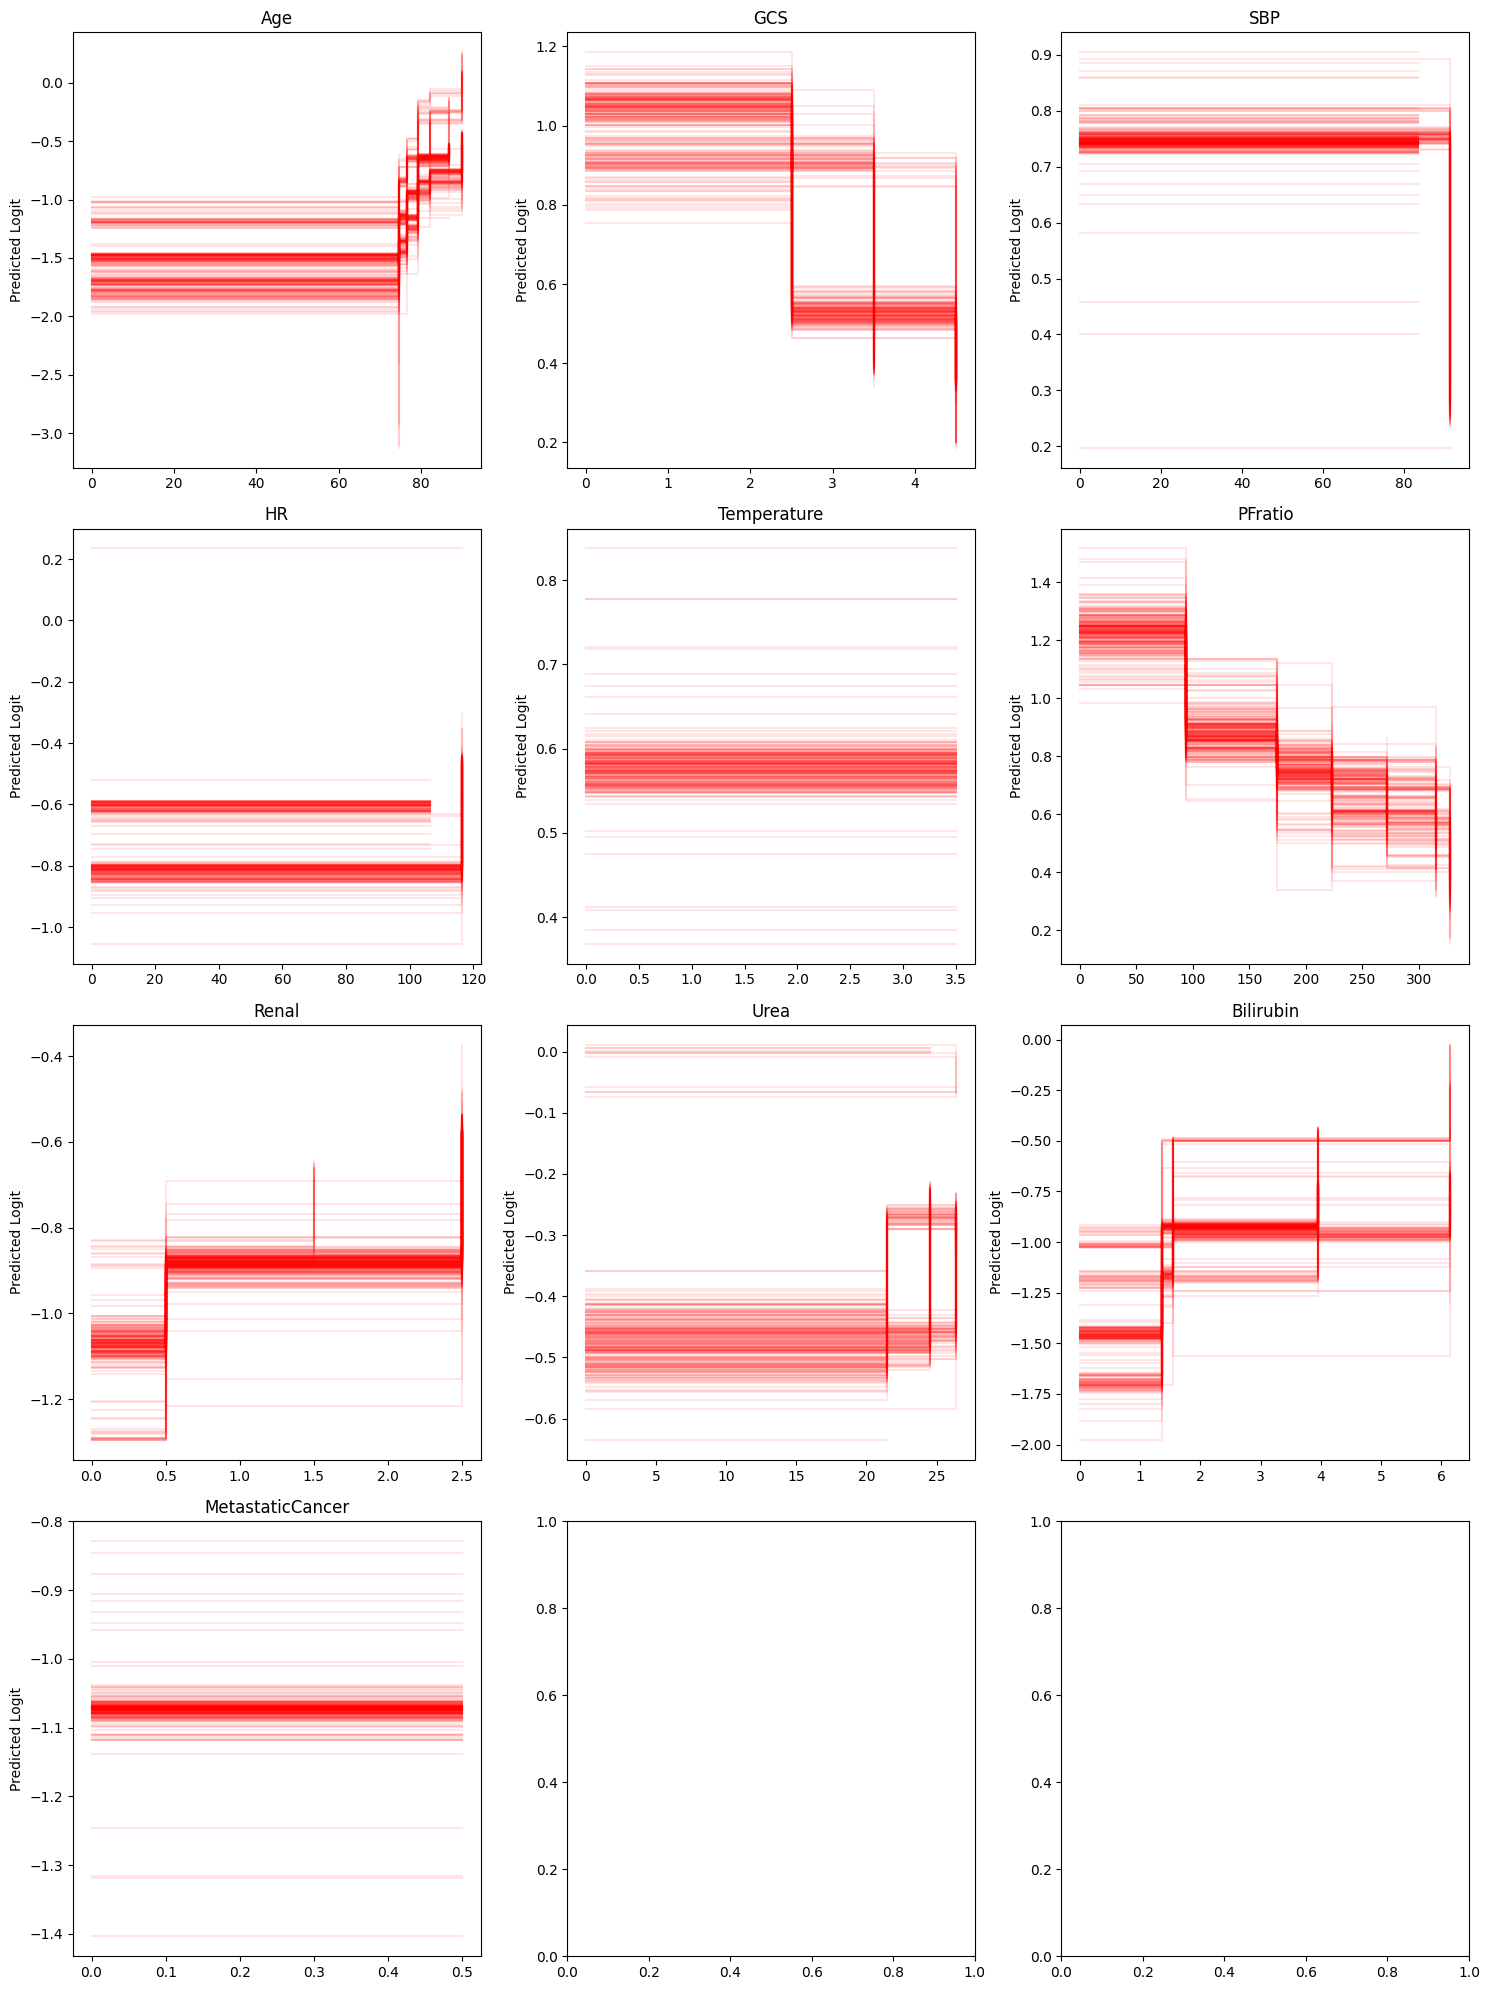

In [24]:
mimic2_models = load_models('mimic2')

# for mm in mimic2_methods:
#     print(f"GAM for {mm}")
#     model = mimic2_models[mm]
#     _ = plot_gam(mimic2_models['header'][1:], model['w_rset'][:300, 1:])

_ = plot_gam(mimic2_models['header'][1:], mimic2_models['w_rset'][:, 1:])